In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# League of Legends Season 9 EU Server Analysis

## Overview
League of Legends (LoL) is a free-to-play multiplayer online battle arena (MOBA) game developed and published by Riot Games in 2009. It is one of the most popular competitive games worldwide, known for its fast-paced strategy and large esports scene.

In the game, two teams of five players face off on a map called Summoner’s Rift. Each player controls a unique Champion, chosen from a roster of over 160 characters, each with different abilities, roles, and playstyles (such as Assassin, Tank, Mage, Marksman, or Support).

The primary objective is to destroy the enemy team’s Nexus, a structure located deep within their base. To achieve this, players must work together to secure resources like gold and experience, defeat enemy champions, take control of the map, and destroy defensive turrets and inhibitors.

League of Legends requires a mix of teamwork, strategy, and mechanical skill. Matches usually last between 20 to 40 minutes. Beyond casual play, LoL has one of the largest professional esports ecosystems, highlighted by the annual League of Legends World Championship, which attracts millions of viewers globally.

## Problem statement
1. Descriptive & Exploratory Analysis:
    - Game Duration Analysis:
        - Game duration distribution (how many minutes a match lasts on average)
    - Win Conditions & Objectives:
        - How much influence does first blood, first tower, first dragon, first Baron, and first Rift Herald have on victory?
        - The correlation between the number of objectives (towers, inhibitors, Barons, and dragons) a team gains and their chance of winning
    - Team Strategy:
        - Does the team that takes more Barons/Dragons tend to win faster?
    - Ban Analysis:
        - Which champions are banned most frequently?
        - What is the relationship between banned champions and win rate?
2. Predictive Modeling:
    - Win Prediction Model:
        - Create a classification model to predict the winner based on:
            - First blood / first tower / first dragon / first Baron
            - Number of objectives secured
            - Champion picks & bans (features can be processed with encoding)
3. Champion & Meta Analysis:
    - Champion Popularity & Win Rate:
        - Analyze how often a champion is picked (pick rate)
        - The win rate of a particular champion when combined with a specific spell
    - Synergy & Counter Analysis:
        - Are there certain champion combinations within a team that increase the chances of winning?
        - Do certain bans significantly impact the opponent's victory?
4. Conclusion & Recommendation:
    - Based on EDA & ML model


## Goals
Develop a comprehensive, data-driven summary of League of Legends Ranked Season 9 on the EU server, uncovering gameplay dynamics, champion and objective trends, and key factors influencing victory. Insights are derived through a combination of exploratory data analysis (EDA) and machine learning, bridging game strategy understanding with advanced analytical methodologies.

## 1. Data Understanding

### 1.1 Data Dictionary
| Field Name | Description | Data Type |
| --- | --- | :---: |
| gameId | user game id | int |
| creationTime | match making time | int |
| gameDuration | duration per game | int |
| seasonId | season of the game | int |
| winner | team 1 or team 2 | int |
| firstBlood | which team has the first blood ( team 1 or team 2) | int |
| firstTower | which team has destroy the tower first (team 1 or team 2) | int |
| firstInhibitor | which team has destroy the inhibitor (inner tower) first (team 1 or team 2) | int |
| firstBaron | which team has slain the baron (team 1 or team 2) | int |
| firstDragon | which team has slain the dragon (team 1 or team 2) | int |
| firstRiftHerald | which team has slain the herald (team 1 or team 2) | int |
| t1_champ1id | team 1 player 1 champion's id based on df_champ | |
| t1_champ1_sum1 | team 1 player 1 summpner's id based on df_champ | |
| t1_champ1_sum2 | team 1 player 1 summpner's id based on df_summon | |
| t1_champ2id | team 1 player 2 champion's id based on df_champ | |
| t1_champ2_sum1 | team 1 player 2 summpner's id based on df_summon | |
| t1_champ2_sum2 | team 1 player 2 summpner's id based on df_summon | |
| t1_champ3id | team 1 player 3 champion's id based on df_champ | |
| t1_champ3_sum1 | team 1 player 3 summpner's id based on df_summon | |
| t1_champ3_sum2 | team 1 player 3 summpner's id based on df_summon | |
| t1_champ4id | team 1 player 4 champion's id based on df_champ | |
| t1_champ4_sum1 | team 1 player 4 summpner's id based on df_summon | |
| t1_champ4_sum2 |  team 1 player 4 summpner's id based on df_summon | |
| t1_champ5id | team 1 player 5 champion's id based on df_champ | |
| t1_champ5_sum1 | team 1 player 5 summpner's id based on df_summon | |
| t1_champ5_sum2 | team 1 player 5 summpner's id based on df_summon | |
| t1_towerKills | number of towers that have been destroyed in the game by team 1| int |
| t1_inhibitorKills | number of inhibitor that have been destroyed in the game by team 1| int |
| t1_baronKills | number of baron that have been destroyed in the game by team 1| int |
| t1_dragonKills | number of dragon that have been destroyed in the game by team 1| int |
| t1_riftHeraldKills | number of herald that have been destroyed in the game by team 1| int |
| t1_ban1 | champion's id that has been banned in the game by team 1 | int |
| t1_ban2 | champion's id that has been banned in the game by team 1 | int |
| t1_ban3 | champion's id that has been banned in the game by team 1 | int |
| t1_ban4 | champion's id that has been banned in the game by team 1 | int |
| t1_ban5 | champion's id that has been banned in the game by team 1 | int |
| t2_champ1id | team 2 player 1 champion's id based on df_champ |
| t2_champ1_sum1 | team 2 player 1 summoner's spell id based on df_summon |
| t2_champ1_sum2 | team 2 player 1 summoner's spell id based on df_summon |
| t2_champ2id | team 2 player 2 champion's id based on df_champ |
| t2_champ2_sum1 | team 2 player 2 summoner's spell id based on df_summon |
| t2_champ2_sum2 | team 2 player 2 summoner's spell id based on df_summon |
| t2_champ3id | team 2 player 3 champion's id based on df_champ |
| t2_champ3_sum1 | team 2 player 3 summoner's spell id based on df_summon |
| t2_champ3_sum2 | team 2 player 3 summoner's spell id based on df_summon |
| t2_champ4id | team 2 player 4 champion's id based on df_champ |
| t2_champ4_sum1 | team 2 player 4 summoner's spell id based on df_summon |
| t2_champ4_sum2 |team 2 player 4 summoner's spell id based on df_summon |
| t2_champ5id | team 2 player 5 champion's id based on df_champ |
| t2_champ5_sum1 | team 2 player 5 summoner's spell id based on df_summon |
| t2_champ5_sum2 | team 2 player 5 summoner's spell id based on df_summon |
| t2_towerKills | number of towers that have been destroyed in the game by team 2| int |
| t2_inhibitorKills | number of inhibitor that have been destroyed in the game by team 2| int |
| t2_baronKills | number of baron that have been destroyed in the game by team 2| int |
| t2_dragonKills | number of dragon that have been destroyed in the game by team 2| int |
| t2_riftHeraldKills | number of herald that have been destroyed in the game by team 2| int |
| t2_ban1 | champion's id that has been banned in the game by team 2 | int |
| t2_ban2 | champion's id that has been banned in the game by team 2 | int |
| t2_ban3 | champion's id that has been banned in the game by team 2 | int |
| t2_ban4 | champion's id that has been banned in the game by team 2 | int |
| t2_ban5 | champion's id that has been banned in the game by team 2 | int |\n"

### 1.2 Dataset Preparation

This is a collection of over 50,000 ranked EUW games from the game League of Legends, as well as json files containing a way to convert between champion and summoner spell IDs and their names. For each game, there are fields for:

- Game ID
- Creation Time (in Epoch format)
- Game Duration (in seconds)
- Season ID
- Winner (1 = team1, 2 = team2)
- First Baron, dragon, tower, blood, inhibitor and Rift Herald (1 = team1, 2 = team2, 0 = none)
- Champions and summoner spells for each team (Stored as Riot's champion and summoner spell IDs)
- The number of tower, inhibitor, Baron, dragon and Rift Herald kills each team has
- The 5 bans of each team (Again, champion IDs are used)

This dataset was collected using the Riot Games API, which makes it easy to lookup and collect information on a users ranked history and collect their games. However finding a list of usernames is the hard part, in this case I am using a list of usernames scraped from 3rd party LoL sites.

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv(r"C:\Users\ADIT\Documents\Projects\LOL dataset\games_detail.csv")
df

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,1504279457970,1949,9,1,2,1,1,1,1,2,8,12,4,432,3,4,96,4,7,11,11,6,112,4,14,11,1,2,3,0,92,40,69,119,141,104,11,4,498,4,7,122,6,4,238,14,4,412,4,3,5,0,0,1,1,114,67,43,16,51
1,3229566029,1497848803862,1851,9,1,1,1,1,0,1,1,119,7,4,39,12,4,76,4,3,10,4,14,35,4,11,10,4,0,2,1,51,122,17,498,19,54,4,12,25,4,14,120,11,4,157,4,14,92,4,7,2,0,0,0,0,11,67,238,51,420
2,3327363504,1504360103310,1493,9,1,2,1,1,1,2,0,18,4,7,141,11,4,267,3,4,68,4,12,38,12,4,8,1,1,1,0,117,40,29,16,53,69,4,7,412,14,4,126,4,12,24,4,11,22,7,4,2,0,0,1,0,157,238,121,57,28
3,3326856598,1504348503996,1758,9,1,1,1,1,1,1,0,57,4,12,63,4,14,29,4,7,61,4,1,36,11,4,9,2,1,2,0,238,67,516,114,31,90,14,4,19,11,4,412,4,3,92,4,14,22,4,7,0,0,0,0,0,164,18,141,40,51
4,3330080762,1504554410899,2094,9,1,2,1,1,1,1,0,19,4,12,29,11,4,40,4,3,119,4,7,134,7,4,9,2,1,3,0,90,64,412,25,31,37,3,4,59,4,12,141,11,4,38,4,12,51,4,7,3,0,0,1,0,86,11,201,122,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51485,3308904636,1503076540231,1944,9,2,1,2,2,0,2,0,19,12,4,429,4,7,91,4,14,432,4,14,64,4,11,2,0,0,0,0,114,18,11,157,497,45,12,4,83,12,4,67,4,7,40,3,4,79,11,4,10,2,0,4,0,55,-1,90,238,157
51486,3215685759,1496957179355,3304,9,2,1,1,2,2,2,2,90,4,14,32,4,11,31,12,4,412,14,4,18,4,7,5,4,0,2,0,157,164,122,99,420,102,11,4,429,7,4,89,3,4,75,4,12,45,14,4,11,7,4,4,1,157,55,119,154,105
51487,3322765040,1504029863961,2156,9,2,2,2,2,0,1,0,141,11,4,18,7,4,432,3,4,81,12,4,68,4,12,0,0,0,1,0,238,31,24,53,11,1,4,12,119,7,4,33,11,4,43,12,4,99,14,4,10,2,0,2,0,113,122,53,11,157
51488,3256675373,1499562036246,1475,9,2,2,2,2,0,2,0,121,11,4,236,4,7,420,4,12,201,4,3,99,4,14,0,0,0,0,0,119,64,51,157,29,21,7,4,56,4,12,25,4,14,30,12,4,11,11,4,11,3,0,1,0,154,39,51,90,114


- creationTime (match making time) If it is assumed to be in seconds, it is still irrelevant if it is changed to hours in the context of match making in the LoL game. So creationTime column will dropped.
- gameDuration still in seconds, will transformed to minutes since MOBA games standard gameDuration its in minutes.
- seasonId will be dropped since this dataset only presents data in season 9 ranked games.

In [4]:
df.drop(columns=['creationTime','seasonId'], inplace=True)
df['gameDuration'] = (df['gameDuration'] / 60).round()
df['gameDuration'] = df['gameDuration'].astype(int)
df

,gameId,gameDuration,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,32,1,2,1,1,1,1,2,8,12,4,432,3,4,96,4,7,11,11,6,112,4,14,11,1,2,3,0,92,40,69,119,141,104,11,4,498,4,7,122,6,4,238,14,4,412,4,3,5,0,0,1,1,114,67,43,16,51
1,3229566029,31,1,1,1,1,0,1,1,119,7,4,39,12,4,76,4,3,10,4,14,35,4,11,10,4,0,2,1,51,122,17,498,19,54,4,12,25,4,14,120,11,4,157,4,14,92,4,7,2,0,0,0,0,11,67,238,51,420
2,3327363504,25,1,2,1,1,1,2,0,18,4,7,141,11,4,267,3,4,68,4,12,38,12,4,8,1,1,1,0,117,40,29,16,53,69,4,7,412,14,4,126,4,12,24,4,11,22,7,4,2,0,0,1,0,157,238,121,57,28
3,3326856598,29,1,1,1,1,1,1,0,57,4,12,63,4,14,29,4,7,61,4,1,36,11,4,9,2,1,2,0,238,67,516,114,31,90,14,4,19,11,4,412,4,3,92,4,14,22,4,7,0,0,0,0,0,164,18,141,40,51
4,3330080762,35,1,2,1,1,1,1,0,19,4,12,29,11,4,40,4,3,119,4,7,134,7,4,9,2,1,3,0,90,64,412,25,31,37,3,4,59,4,12,141,11,4,38,4,12,51,4,7,3,0,0,1,0,86,11,201,122,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51485,3308904636,32,2,1,2,2,0,2,0,19,12,4,429,4,7,91,4,14,432,4,14,64,4,11,2,0,0,0,0,114,18,11,157,497,45,12,4,83,12,4,67,4,7,40,3,4,79,11,4,10,2,0,4,0,55,-1,90,238,157
51486,3215685759,55,2,1,1,2,2,2,2,90,4,14,32,4,11,31,12,4,412,14,4,18,4,7,5,4,0,2,0,157,164,122,99,420,102,11,4,429,7,4,89,3,4,75,4,12,45,14,4,11,7,4,4,1,157,55,119,154,105
51487,3322765040,36,2,2,2,2,0,1,0,141,11,4,18,7,4,432,3,4,81,12,4,68,4,12,0,0,0,1,0,238,31,24,53,11,1,4,12,119,7,4,33,11,4,43,12,4,99,14,4,10,2,0,2,0,113,122,53,11,157
51488,3256675373,25,2,2,2,2,0,2,0,121,11,4,236,4,7,420,4,12,201,4,3,99,4,14,0,0,0,0,0,119,64,51,157,29,21,7,4,56,4,12,25,4,14,30,12,4,11,11,4,11,3,0,1,0,154,39,51,90,114


In [5]:
from pandas import json_normalize

df_champs_info = pd.read_json(r"C:\Users\ADIT\Documents\Projects\LOL dataset\champion_info.json")
df_champs_info = pd.concat([df_champs_info.drop(columns=['data']),
                            json_normalize(df_champs_info['data'])], axis = 1)
df_champs_info

,type,version,title,id,key,name
1,champion,7.17.2,the Berserker,2.0,Olaf,Olaf
2,champion,7.17.2,the Colossus,3.0,Galio,Galio
3,champion,7.17.2,the Card Master,4.0,TwistedFate,Twisted Fate
4,champion,7.17.2,the Seneschal of Demacia,5.0,XinZhao,Xin Zhao
5,champion,7.17.2,the Dreadnought,6.0,Urgot,Urgot
...,...,...,...,...,...,...
129,NaN,NaN,the Chain Warden,412.0,Thresh,Thresh
130,NaN,NaN,the Kraken Priestess,420.0,Illaoi,Illaoi
132,NaN,NaN,the Green Father,427.0,Ivern,Ivern
135,NaN,NaN,The Charmer,497.0,Rakan,Rakan


In [6]:
df_champs_info[['type', 'version']] = df_champs_info[['type', 'version']].ffill()

In [7]:
df_champs_info[df_champs_info.isna().any(axis=1)]

,type,version,title,id,key,name
141,champion,7.17.2,NaN,NaN,NaN,NaN
143,champion,7.17.2,NaN,NaN,NaN,NaN
150,champion,7.17.2,NaN,NaN,NaN,NaN
154,champion,7.17.2,NaN,NaN,NaN,NaN
157,champion,7.17.2,NaN,NaN,NaN,NaN
161,champion,7.17.2,NaN,NaN,NaN,NaN
163,champion,7.17.2,NaN,NaN,NaN,NaN
164,champion,7.17.2,NaN,NaN,NaN,NaN
201,champion,7.17.2,NaN,NaN,NaN,NaN
202,champion,7.17.2,NaN,NaN,NaN,NaN


In [8]:
df_champs_info.dropna(subset=['title', 'id', 'key', 'name'], inplace=True)

In [9]:
df_champs_info['id'] = df_champs_info['id'].astype(int)
df_champs_info

,type,version,title,id,key,name
1,champion,7.17.2,the Berserker,2,Olaf,Olaf
2,champion,7.17.2,the Colossus,3,Galio,Galio
3,champion,7.17.2,the Card Master,4,TwistedFate,Twisted Fate
4,champion,7.17.2,the Seneschal of Demacia,5,XinZhao,Xin Zhao
5,champion,7.17.2,the Dreadnought,6,Urgot,Urgot
...,...,...,...,...,...,...
129,champion,7.17.2,the Chain Warden,412,Thresh,Thresh
130,champion,7.17.2,the Kraken Priestess,420,Illaoi,Illaoi
132,champion,7.17.2,the Green Father,427,Ivern,Ivern
135,champion,7.17.2,The Charmer,497,Rakan,Rakan


In [10]:
df_champs_info2 = pd.read_json(r"C:\Users\ADIT\Documents\Projects\LOL dataset\champion_info_2.json")
df_champs_info2 = pd.concat([df_champs_info2.drop(columns='data'),
                             json_normalize(df_champs_info2['data'])], axis=1)
df_champs_info2


,type,version,tags,title,id,key,name
None,champion,7.18.1,NaN,NaN,NaN,NaN,NaN
MonkeyKing,champion,7.18.1,NaN,NaN,NaN,NaN,NaN
Jax,champion,7.18.1,NaN,NaN,NaN,NaN,NaN
Fiddlesticks,champion,7.18.1,NaN,NaN,NaN,NaN,NaN
Shaco,champion,7.18.1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
134,NaN,NaN,"[Marksman, Mage]",the Mouth of the Abyss,96.0,KogMaw,Kog'Maw
135,NaN,NaN,"[Mage, Assassin]",the Nine-Tailed Fox,103.0,Ahri,Ahri
136,NaN,NaN,"[Marksman, Fighter]",Demacia's Wings,133.0,Quinn,Quinn
137,NaN,NaN,"[Assassin, Mage]",the Deceiver,7.0,Leblanc,LeBlanc


In [11]:
# Reset index -> champion's name to new column
df_champs_info2 = df_champs_info2.reset_index().rename(columns={"index": "champion_name"})

# Fill column name and key with champion_name (if NaN)
df_champs_info2['name'] = df_champs_info2['name'].fillna(df_champs_info2['champion_name'])
df_champs_info2['key'] = df_champs_info2['key'].fillna(df_champs_info2['champion_name'])

# Forward-fill column type and version
df_champs_info2[['type', 'version']] = df_champs_info2[['type', 'version']].ffill()

# Drop additional column if not necesary
df_champs_info2 = df_champs_info2.drop(columns=['champion_name'])

df_champs_info2

,type,version,tags,title,id,key,name
0,champion,7.18.1,NaN,NaN,NaN,None,None
1,champion,7.18.1,NaN,NaN,NaN,MonkeyKing,MonkeyKing
2,champion,7.18.1,NaN,NaN,NaN,Jax,Jax
3,champion,7.18.1,NaN,NaN,NaN,Fiddlesticks,Fiddlesticks
4,champion,7.18.1,NaN,NaN,NaN,Shaco,Shaco
...,...,...,...,...,...,...,...
273,champion,7.18.1,"[Marksman, Mage]",the Mouth of the Abyss,96.0,KogMaw,Kog'Maw
274,champion,7.18.1,"[Mage, Assassin]",the Nine-Tailed Fox,103.0,Ahri,Ahri
275,champion,7.18.1,"[Marksman, Fighter]",Demacia's Wings,133.0,Quinn,Quinn
276,champion,7.18.1,"[Assassin, Mage]",the Deceiver,7.0,Leblanc,LeBlanc


In [12]:
df_champs_info2 = df_champs_info2.dropna(subset=['tags', 'title', 'id']).reset_index()
df_champs_info2

,index,type,version,tags,title,id,key,name
0,139,champion,7.18.1,[],None,-1.0,None,None
1,140,champion,7.18.1,"[Fighter, Tank]",the Monkey King,62.0,MonkeyKing,Wukong
2,141,champion,7.18.1,"[Fighter, Assassin]",Grandmaster at Arms,24.0,Jax,Jax
3,142,champion,7.18.1,"[Mage, Support]",the Harbinger of Doom,9.0,Fiddlesticks,Fiddlesticks
4,143,champion,7.18.1,[Assassin],the Demon Jester,35.0,Shaco,Shaco
...,...,...,...,...,...,...,...,...
134,273,champion,7.18.1,"[Marksman, Mage]",the Mouth of the Abyss,96.0,KogMaw,Kog'Maw
135,274,champion,7.18.1,"[Mage, Assassin]",the Nine-Tailed Fox,103.0,Ahri,Ahri
136,275,champion,7.18.1,"[Marksman, Fighter]",Demacia's Wings,133.0,Quinn,Quinn
137,276,champion,7.18.1,"[Assassin, Mage]",the Deceiver,7.0,Leblanc,LeBlanc


In [13]:
df_champs_info2.drop(columns='index', inplace=True)
df_champs_info2.drop(index=0, inplace=True)
df_champs_info2.rename(columns={'tags':'role'}, inplace=True)

In [14]:
df_champs_info2['id'] = df_champs_info2['id'].astype(int)
df_champs_info2

,type,version,role,title,id,key,name
1,champion,7.18.1,"[Fighter, Tank]",the Monkey King,62,MonkeyKing,Wukong
2,champion,7.18.1,"[Fighter, Assassin]",Grandmaster at Arms,24,Jax,Jax
3,champion,7.18.1,"[Mage, Support]",the Harbinger of Doom,9,Fiddlesticks,Fiddlesticks
4,champion,7.18.1,[Assassin],the Demon Jester,35,Shaco,Shaco
5,champion,7.18.1,"[Fighter, Tank]",the Uncaged Wrath of Zaun,19,Warwick,Warwick
...,...,...,...,...,...,...,...
134,champion,7.18.1,"[Marksman, Mage]",the Mouth of the Abyss,96,KogMaw,Kog'Maw
135,champion,7.18.1,"[Mage, Assassin]",the Nine-Tailed Fox,103,Ahri,Ahri
136,champion,7.18.1,"[Marksman, Fighter]",Demacia's Wings,133,Quinn,Quinn
137,champion,7.18.1,"[Assassin, Mage]",the Deceiver,7,Leblanc,LeBlanc


In [15]:
df_summon = pd.read_json(r"C:\Users\ADIT\Documents\Projects\LOL dataset\summoner_spell_info.json")
df_summon = pd.concat([df_summon.drop(columns='data'),
                       json_normalize(df_summon['data'])], axis=1)
df_summon

,type,version,id,summonerLevel,name,key,description
1,summoner,7.17.2,3.0,4.0,Exhaust,SummonerExhaust,"Exhausts target enemy champion, reducing their..."
3,summoner,7.17.2,6.0,1.0,Ghost,SummonerHaste,Your champion gains increased Movement Speed a...
4,summoner,7.17.2,7.0,1.0,Heal,SummonerHeal,Restores 90-345 Health (depending on champion ...
6,summoner,7.17.2,12.0,6.0,Teleport,SummonerTeleport,"After channeling for 4.5 seconds, teleports yo..."
7,summoner,7.17.2,13.0,1.0,Clarity,SummonerMana,Restores 50% of your champion's maximum Mana. ...
11,summoner,7.17.2,31.0,1.0,Poro Toss,SummonerPoroThrow,"Toss a Poro at your enemies. If it hits, you c..."
12,summoner,7.17.2,32.0,1.0,Mark,SummonerSnowball,Throw a snowball in a straight line at your en...
13,summoner,7.17.2,33.0,1.0,Nexus Siege: Siege Weapon Slot,SummonerSiegeChampSelect1,"In Nexus Siege, Summoner Spells are replaced w..."
14,summoner,7.17.2,34.0,1.0,Nexus Siege: Siege Weapon Slot,SummonerSiegeChampSelect2,"In Nexus Siege, Summoner Spells are replaced w..."
21,summoner,7.17.2,NaN,NaN,NaN,NaN,NaN


In [16]:
df_summon[['type', 'version']] = df_summon[['type', 'version']].ffill()
df_summon = df_summon.dropna()

In [17]:
df_summon = df_summon.astype({'summonerLevel': 'int', 'id': 'int'})
df_summon = df_summon.rename(columns={'name':'spell', 'key':'spell_type'})
df_summon

,type,version,id,summonerLevel,spell,spell_type,description
1,summoner,7.17.2,3,4,Exhaust,SummonerExhaust,"Exhausts target enemy champion, reducing their..."
3,summoner,7.17.2,6,1,Ghost,SummonerHaste,Your champion gains increased Movement Speed a...
4,summoner,7.17.2,7,1,Heal,SummonerHeal,Restores 90-345 Health (depending on champion ...
6,summoner,7.17.2,12,6,Teleport,SummonerTeleport,"After channeling for 4.5 seconds, teleports yo..."
7,summoner,7.17.2,13,1,Clarity,SummonerMana,Restores 50% of your champion's maximum Mana. ...
11,summoner,7.17.2,31,1,Poro Toss,SummonerPoroThrow,"Toss a Poro at your enemies. If it hits, you c..."
12,summoner,7.17.2,32,1,Mark,SummonerSnowball,Throw a snowball in a straight line at your en...
13,summoner,7.17.2,33,1,Nexus Siege: Siege Weapon Slot,SummonerSiegeChampSelect1,"In Nexus Siege, Summoner Spells are replaced w..."
14,summoner,7.17.2,34,1,Nexus Siege: Siege Weapon Slot,SummonerSiegeChampSelect2,"In Nexus Siege, Summoner Spells are replaced w..."
0,summoner,7.17.2,1,6,Cleanse,SummonerBoost,Removes all disables (excluding suppression an...


In [18]:
df_champions = pd.merge(
    df_champs_info.drop(columns=['version', 'key']),
    df_champs_info2.drop(columns=['version', 'key']),
    on=['type', 'title', 'id', 'name'],
    how="inner"
)
df_champions.sort_values(by='id')

,type,title,id,name,role
108,champion,the Dark Child,1,Annie,[Mage]
0,champion,the Berserker,2,Olaf,"[Fighter, Tank]"
1,champion,the Colossus,3,Galio,"[Tank, Mage]"
2,champion,the Card Master,4,Twisted Fate,[Mage]
3,champion,the Seneschal of Demacia,5,Xin Zhao,"[Fighter, Assassin]"
...,...,...,...,...,...
105,champion,the Spear of Vengeance,429,Kalista,[Marksman]
106,champion,the Wandering Caretaker,432,Bard,"[Support, Mage]"
136,champion,The Charmer,497,Rakan,[Support]
107,champion,the Rebel,498,Xayah,[Marksman]


In [19]:
# Create dictionary mapping from df_champions
champ_dict = df_champions.set_index('id')['name'].to_dict()

# Change all champion's columns id with champion's name
champ_cols = [
    't1_champ1id', 't1_champ2id', 't1_champ3id', 't1_champ4id', 't1_champ5id',
    't1_ban1', 't1_ban2', 't1_ban3', 't1_ban4', 't1_ban5',
    't2_champ1id', 't2_champ2id', 't2_champ3id', 't2_champ4id', 't2_champ5id',
    't2_ban1', 't2_ban2', 't2_ban3', 't2_ban4', 't2_ban5'
]

for col in champ_cols:
    df[col] = df[col].map(champ_dict)


# Create dictionary mapping from df_summon
summon_dict = df_summon.set_index('id')['spell'].to_dict()

# Change all summoner column id with spell name
summon_cols = [
    't1_champ1_sum1', 't1_champ1_sum2', 't1_champ2_sum1', 't1_champ2_sum2',
    't1_champ3_sum1', 't1_champ3_sum2', 't1_champ4_sum1', 't1_champ4_sum2',
    't1_champ5_sum1', 't1_champ5_sum2',
    't2_champ1_sum1', 't2_champ1_sum2', 't2_champ2_sum1', 't2_champ2_sum2',
    't2_champ3_sum1', 't2_champ3_sum2', 't2_champ4_sum1', 't2_champ4_sum2',
    't2_champ5_sum1', 't2_champ5_sum2'
]

for col in summon_cols:
    df[col] = df[col].map(summon_dict)

df

,gameId,gameDuration,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,32,1,2,1,1,1,1,2,Vladimir,Teleport,Flash,Bard,Exhaust,Flash,Kog'Maw,Flash,Heal,Master Yi,Smite,Ghost,Viktor,Flash,Ignite,11,1,2,3,0,Riven,Janna,Cassiopeia,Draven,Kayn,Graves,Smite,Flash,Xayah,Flash,Heal,Darius,Ghost,Flash,Zed,Ignite,Flash,Thresh,Flash,Exhaust,5,0,0,1,1,Fiora,Vayne,Karma,Soraka,Caitlyn
1,3229566029,31,1,1,1,1,0,1,1,Draven,Heal,Flash,Irelia,Teleport,Flash,Nidalee,Flash,Exhaust,Kayle,Flash,Ignite,Shaco,Flash,Smite,10,4,0,2,1,Caitlyn,Darius,Teemo,Xayah,Warwick,Malphite,Flash,Teleport,Morgana,Flash,Ignite,Hecarim,Smite,Flash,Yasuo,Flash,Ignite,Riven,Flash,Heal,2,0,0,0,0,Master Yi,Vayne,Zed,Caitlyn,Illaoi
2,3327363504,25,1,2,1,1,1,2,0,Tristana,Flash,Heal,Kayn,Smite,Flash,Nami,Exhaust,Flash,Rumble,Flash,Teleport,Kassadin,Teleport,Flash,8,1,1,1,0,Lulu,Janna,Twitch,Soraka,Blitzcrank,Cassiopeia,Flash,Heal,Thresh,Ignite,Flash,Jayce,Flash,Teleport,Jax,Flash,Smite,Ashe,Heal,Flash,2,0,0,1,0,Yasuo,Zed,Kha'Zix,Maokai,Evelynn
3,3326856598,29,1,1,1,1,1,1,0,Maokai,Flash,Teleport,Brand,Flash,Ignite,Twitch,Flash,Heal,Orianna,Flash,Cleanse,Dr. Mundo,Smite,Flash,9,2,1,2,0,Zed,Vayne,Ornn,Fiora,Cho'Gath,Malzahar,Ignite,Flash,Warwick,Smite,Flash,Thresh,Flash,Exhaust,Riven,Flash,Ignite,Ashe,Flash,Heal,0,0,0,0,0,Camille,Tristana,Kayn,Janna,Caitlyn
4,3330080762,35,1,2,1,1,1,1,0,Warwick,Flash,Teleport,Twitch,Smite,Flash,Janna,Flash,Exhaust,Draven,Flash,Heal,Syndra,Heal,Flash,9,2,1,3,0,Malzahar,Lee Sin,Thresh,Morgana,Cho'Gath,Sona,Exhaust,Flash,Jarvan IV,Flash,Teleport,Kayn,Smite,Flash,Kassadin,Flash,Teleport,Caitlyn,Flash,Heal,3,0,0,1,0,Garen,Master Yi,Braum,Darius,Tristana
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51485,3308904636,32,2,1,2,2,0,2,0,Warwick,Teleport,Flash,Kalista,Flash,Heal,Talon,Flash,Ignite,Bard,Flash,Ignite,Lee Sin,Flash,Smite,2,0,0,0,0,Fiora,Tristana,Master Yi,Yasuo,Rakan,Veigar,Teleport,Flash,Yorick,Teleport,Flash,Vayne,Flash,Heal,Janna,Exhaust,Flash,Gragas,Smite,Flash,10,2,0,4,0,Katarina,NaN,Malzahar,Zed,Yasuo
51486,3215685759,55,2,1,1,2,2,2,2,Malzahar,Flash,Ignite,Amumu,Flash,Smite,Cho'Gath,Teleport,Flash,Thresh,Ignite,Flash,Tristana,Flash,Heal,5,4,0,2,0,Yasuo,Camille,Darius,Lux,Illaoi,Shyvana,Smite,Flash,Kalista,Heal,Flash,Leona,Exhaust,Flash,Nasus,Flash,Teleport,Veigar,Ignite,Flash,11,7,4,4,1,Yasuo,Katarina,Draven,Zac,Fizz
51487,3322765040,36,2,2,2,2,0,1,0,Kayn,Smite,Flash,Tristana,Heal,Flash,Bard,Exhaust,Flash,Ezreal,Teleport,Flash,Rumble,Flash,Teleport,0,0,0,1,0,Zed,Cho'Gath,Jax,Blitzcrank,Master Yi,Annie,Flash,Teleport,Draven,Heal,Flash,Rammus,Smite,Flash,Karma,Teleport,Flash,Lux,Ignite,Flash,10,2,0,2,0,Sejuani,Darius,Blitzcrank,Master Yi,Yasuo
51488,3256675373,25,2,2,2,2,0,2,0,Kha'Zix,Smite,Flash,Lucian,Flash,Heal,Illaoi,Flash,Teleport,Braum,Flash,Exhaust,Lux,Flash,Ignite,0,0,0,0,0,Draven,Lee Sin,Caitlyn,Yasuo,Twitch,Miss Fortune,Heal,Flash,Nocturne,Flash,Teleport,Morgana,Flash,Ignite,Karthus,Teleport,Flash,Master Yi,Smite,Flash,11,3,0,1,0,Zac,Irelia,Caitlyn,Malzahar,Fiora


In [20]:
def data_check(df):
    pd.set_option('display.max_columns', None)
    results = []
    for col in df.columns:
        data_types = df[col].dtypes
        n_uniques = df[col].nunique()
        missings = df[col].isnull().sum()
        missings_prcntg = (missings / df.shape[0])*100
        unique_val = df[col].unique()
        results.append([col, data_types, n_uniques, missings, missings_prcntg, unique_val])
    return pd.DataFrame(results, columns=['column', 'data type', 'nunique', 'missing values', 'missing %', 'unique values'])

meta_data = data_check(df).sort_values(by='nunique')
meta_data

,column,data type,nunique,missing values,missing %,unique values
2,winner,int64,2,0,0.000000,"[1, 2]"
53,t2_riftHeraldKills,int64,2,0,0.000000,"[1, 0]"
28,t1_riftHeraldKills,int64,2,0,0.000000,"[0, 1]"
3,firstBlood,int64,3,0,0.000000,"[2, 1, 0]"
4,firstTower,int64,3,0,0.000000,"[1, 2, 0]"
5,firstInhibitor,int64,3,0,0.000000,"[1, 0, 2]"
6,firstBaron,int64,3,0,0.000000,"[1, 0, 2]"
7,firstDragon,int64,3,0,0.000000,"[1, 2, 0]"
8,firstRiftHerald,int64,3,0,0.000000,"[2, 1, 0]"
51,t2_baronKills,int64,5,0,0.000000,"[0, 1, 2, 3, 4]"


As we can see all missing values on ban columns, so missing values will be replace by 'No Ban'

In [21]:
df = df.fillna('No Ban')

### 1.3 Data Distribution

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gameId,51490.0,3.306223e+09,2.946096e+07,3.214824e+09,3.292218e+09,3.320021e+09,3.327099e+09,3.331833e+09
gameDuration,51490.0,3.053620e+01,8.558036e+00,3.000000e+00,2.600000e+01,3.100000e+01,3.600000e+01,7.900000e+01
winner,51490.0,1.493552e+00,4.999633e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
firstBlood,51490.0,1.471295e+00,5.203258e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
firstTower,51490.0,1.450631e+00,5.428484e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
firstInhibitor,51490.0,1.308487e+00,6.760970e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
firstBaron,51490.0,9.265100e-01,8.414239e-01,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
firstDragon,51490.0,1.442804e+00,5.695788e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
firstRiftHerald,51490.0,7.316761e-01,8.225260e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00
t1_towerKills,51490.0,5.699359e+00,3.799808e+00,0.000000e+00,2.000000e+00,6.000000e+00,9.000000e+00,1.100000e+01


- the average gameDuration in season 9 EU server ranked games is 30 minutes
- the average winner, firstBlood, firstTower, firstInhibitor, and firstDragon in season 9 EU server ranked games is more dominated by team 2 which has second pick
- the average firstBaron and firstRiftHerald in season 9 EU server ranked games is more dominated by team 1 which has first pick
- team 1 (t1_towerKills) has average 5.9 tower kills in season 9 EU server ranked games
- team 1 (t1_inhibitorKills) has average 1.01 inhibitor tower kills in season 9 EU server ranked games
- team 1 (t1_baronKills) has average 3.72 baron slained in season 9 EU server ranked games
- team 1 (t1_dragonKills) has average 1.38 dragon slained in season 9 EU server ranked games
- team 1 (t1_riftHeraldKills) has average 2.5 heralds kills in season 9 EU server ranked games
- team 2 (t2_towerKills) has average 5.5 tower kills in season 9 EU server ranked games
- team 2 (t2_inhibitorKills) has average 9.85 inhibitor tower kills in season 9 EU server ranked games
- team 2 (t2_baronKills) has average 4.1 baron slained in season 9 EU server ranked games
- team 2 (t2_dragonKills) has average 1.4 dragon slained in season 9 EU server ranked games
- team 2 (t2_riftHeraldKills) has average 2.4 heralds kills in season 9 EU server ranked games

In [23]:
df.describe(include='object').T

,count,unique,top,freq
t1_champ1id,51490,138,Tristana,1299
t1_champ1_sum1,51490,9,Flash,28164
t1_champ1_sum2,51490,9,Flash,22216
t1_champ2id,51490,138,Thresh,1342
t1_champ2_sum1,51490,9,Flash,27998
t1_champ2_sum2,51490,9,Flash,22490
t1_champ3id,51490,138,Thresh,1322
t1_champ3_sum1,51490,9,Flash,28019
t1_champ3_sum2,51490,9,Flash,22397
t1_champ4id,51490,138,Tristana,1335


- Tristana and Thresh are the most popular picked champions in season 9 EU server ranked games
- Flash is the most popular picked spell in season 9 EU server ranked games
- Yasuo is the most popular banned champion in season 9 EU server ranked games

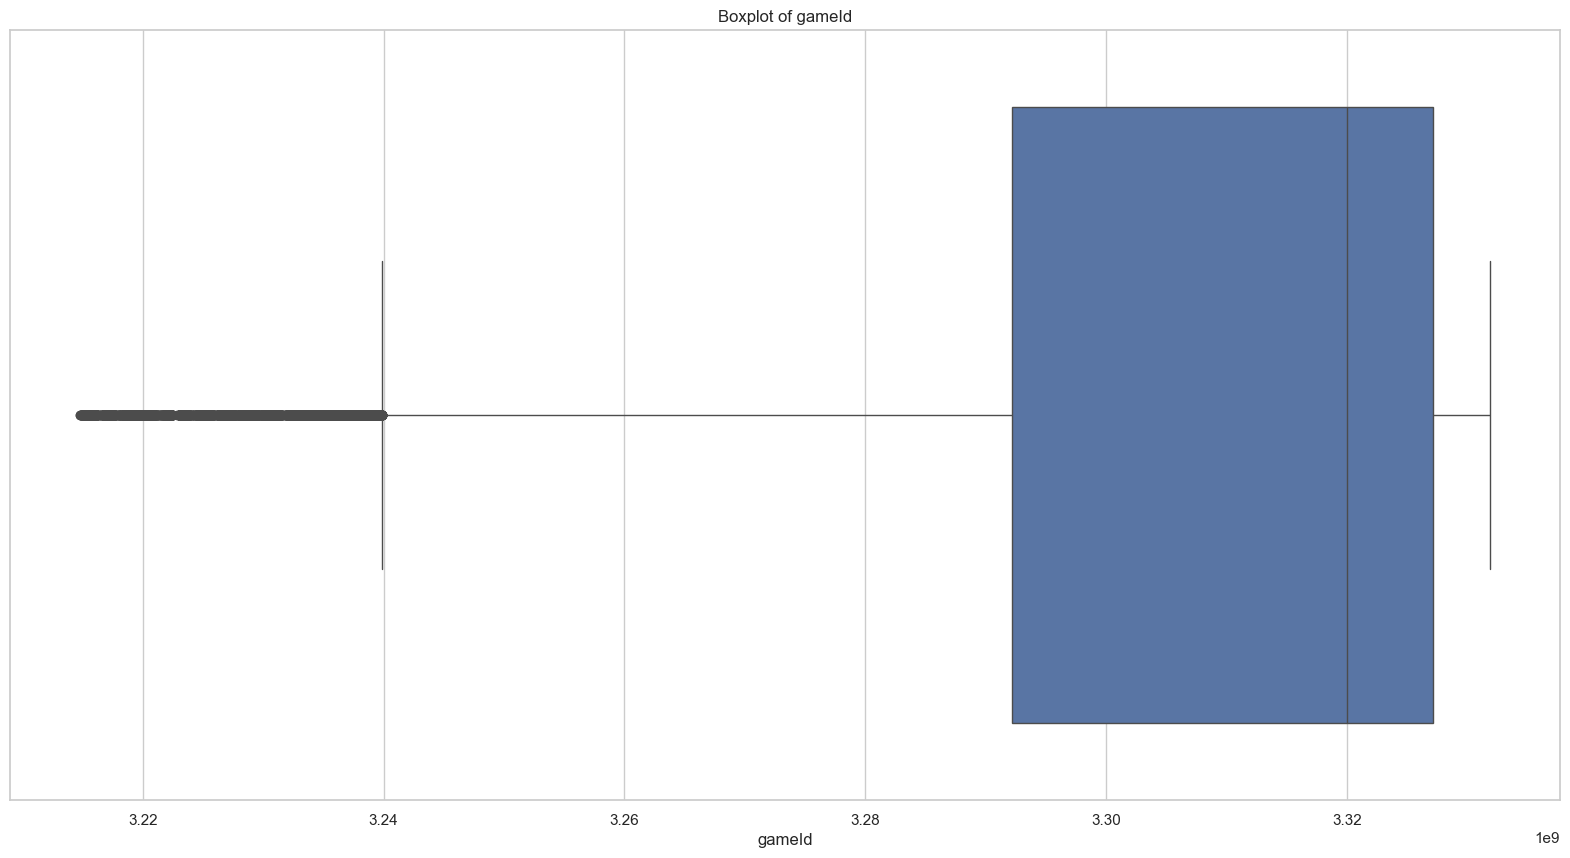

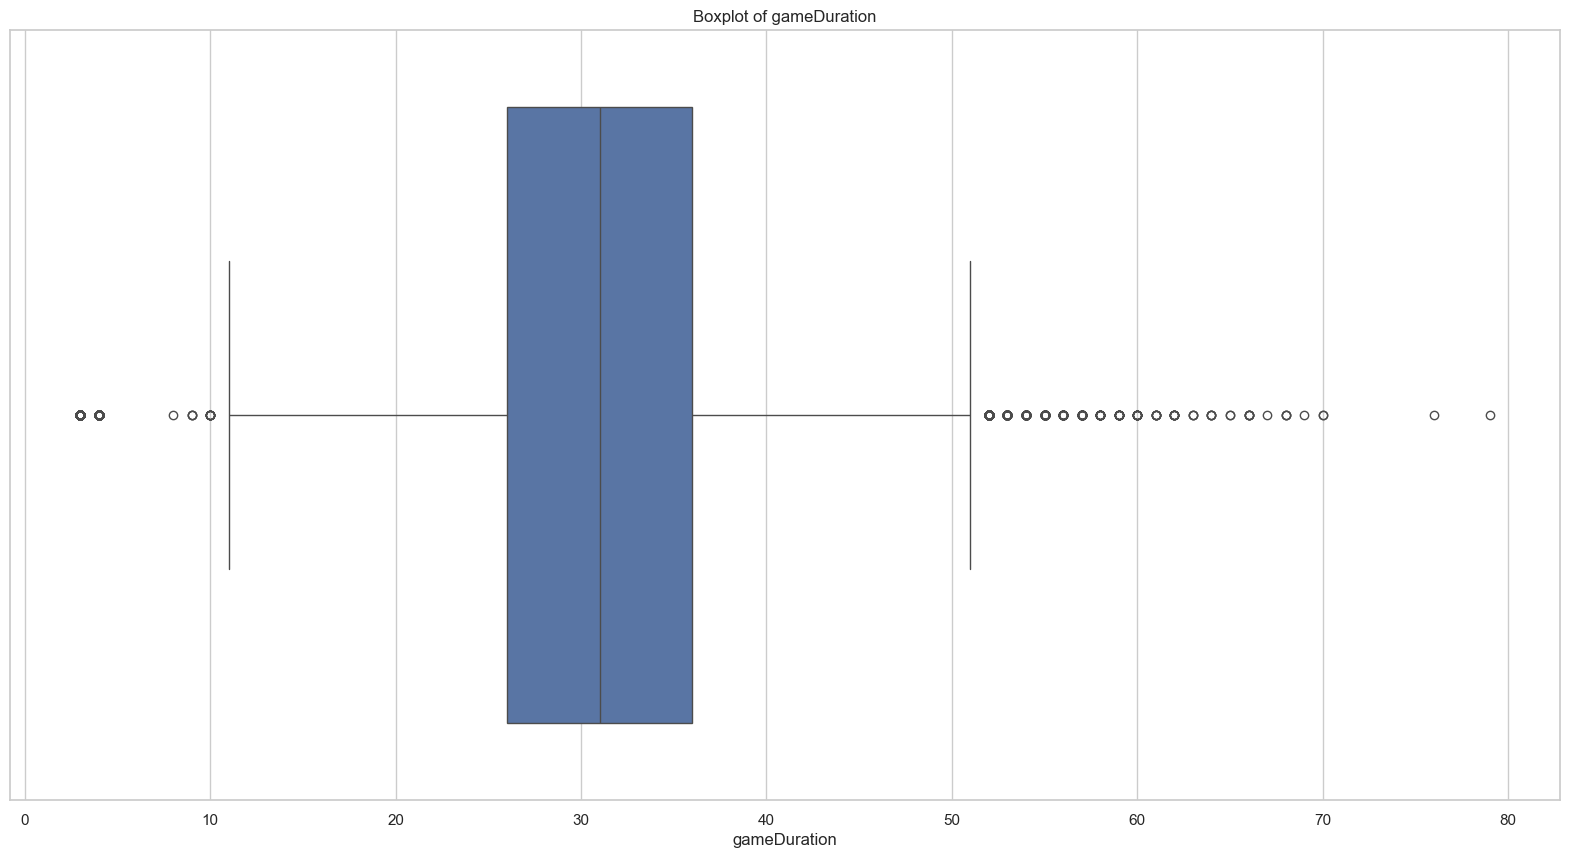

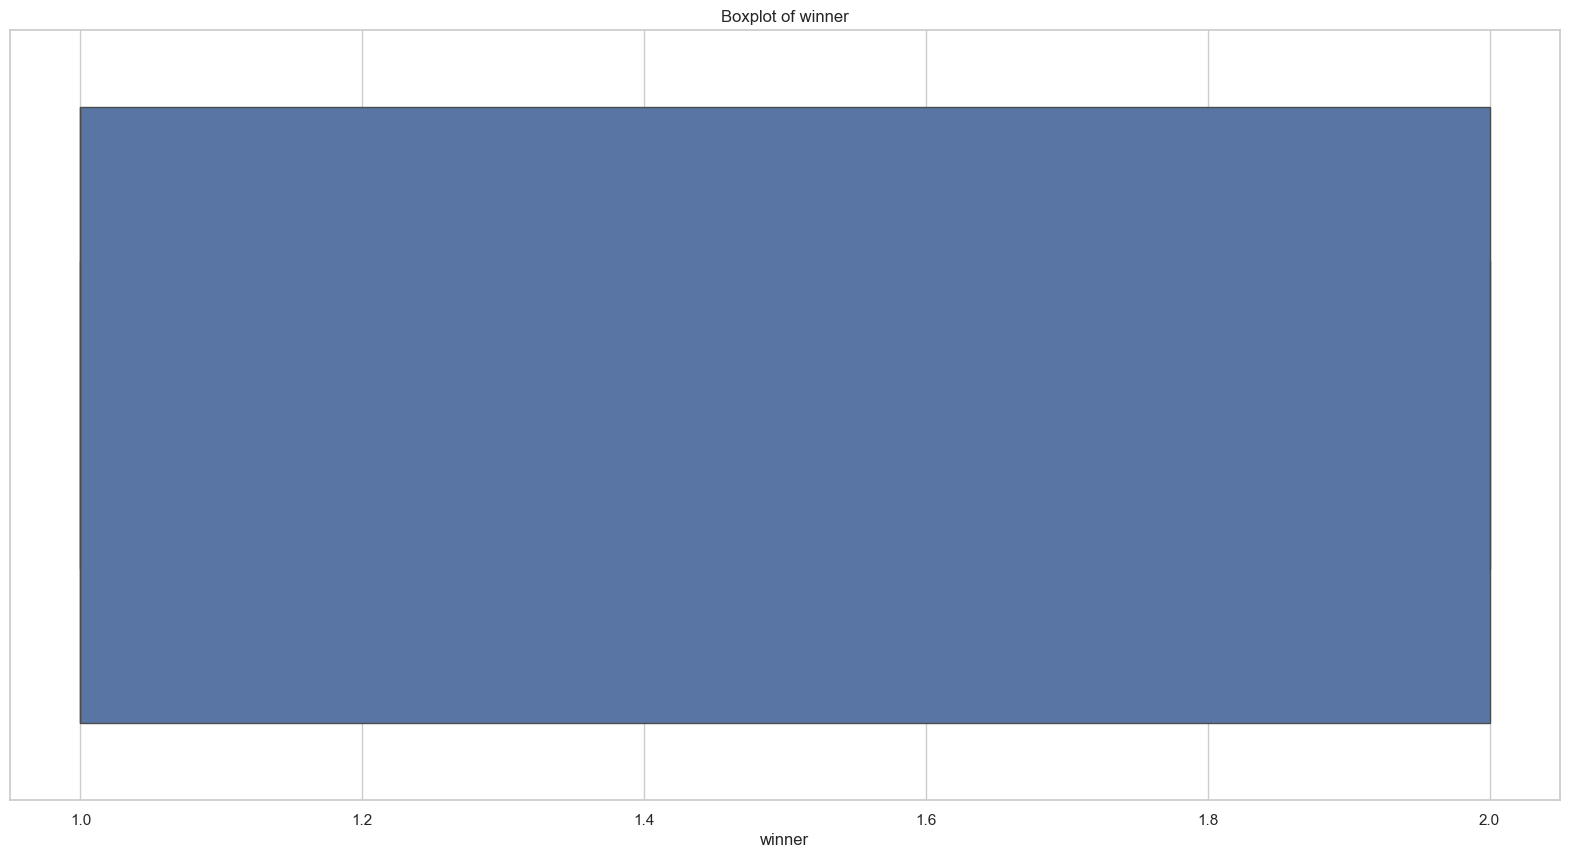

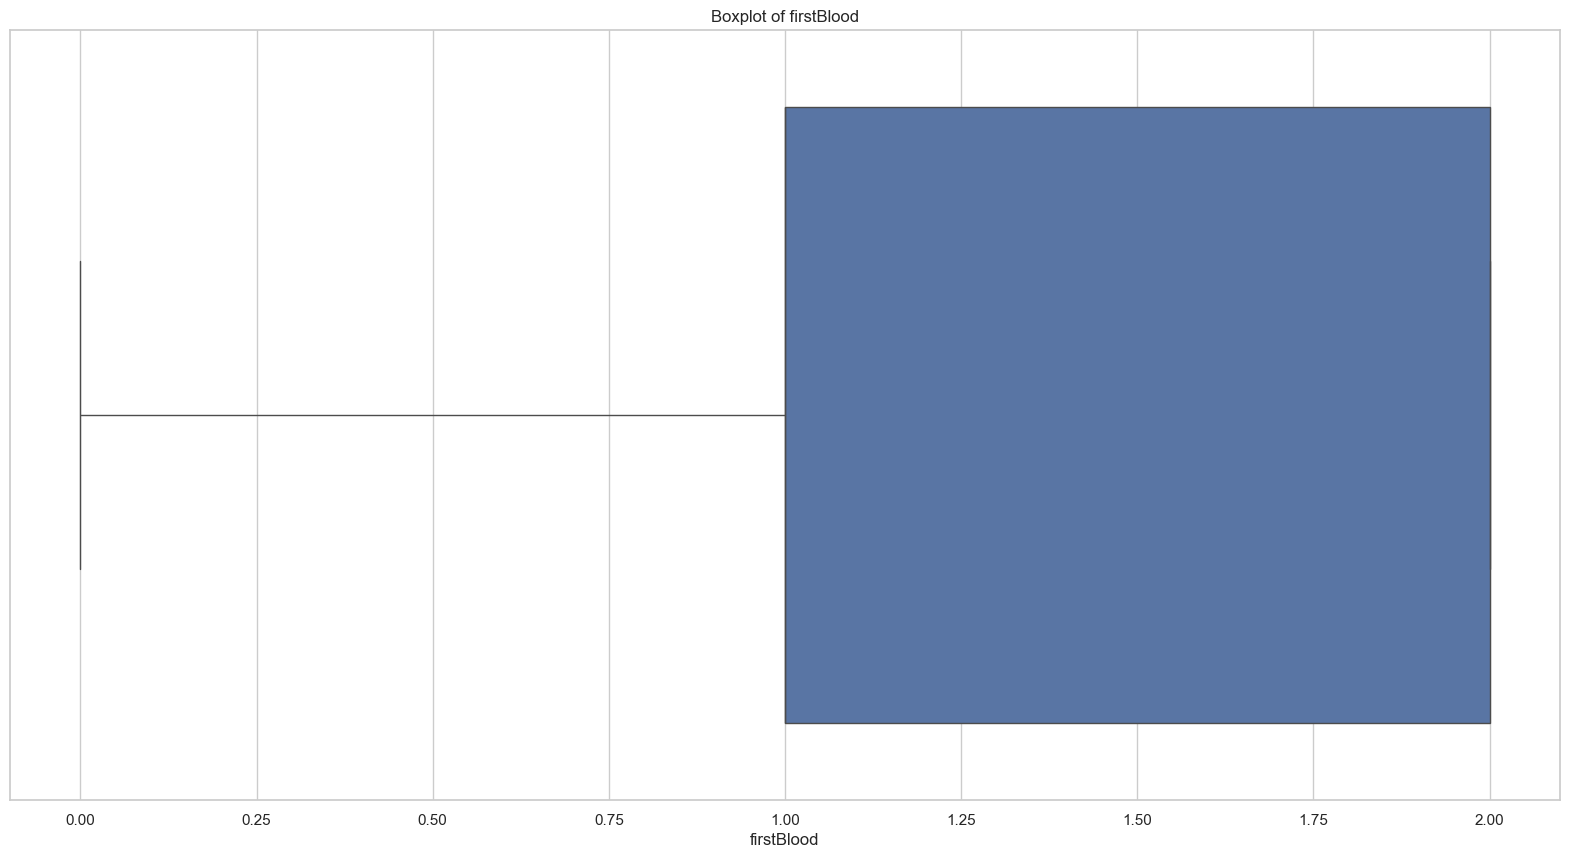

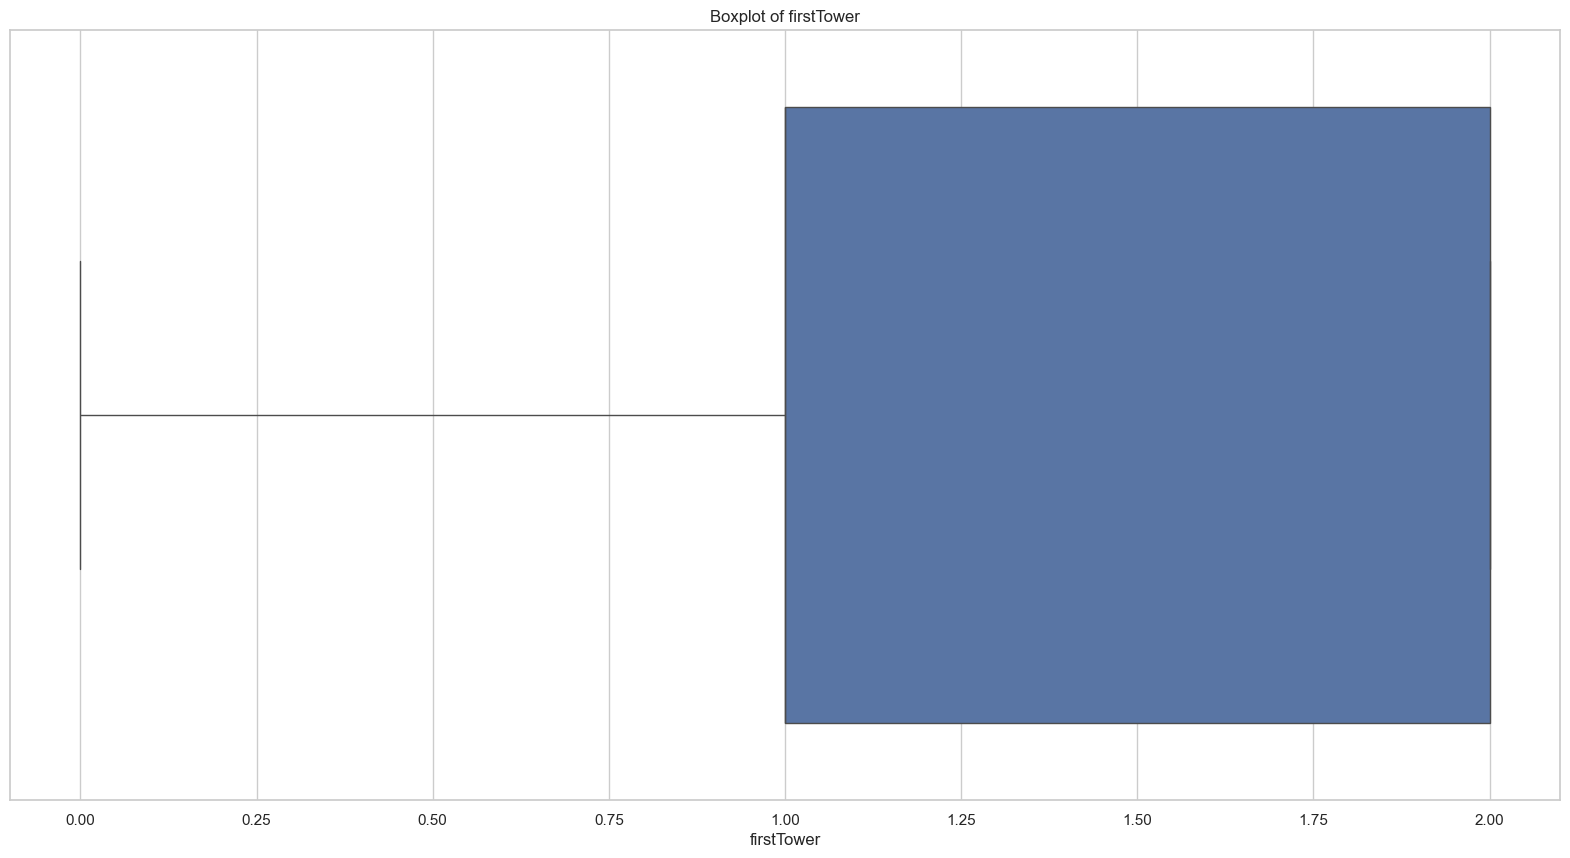

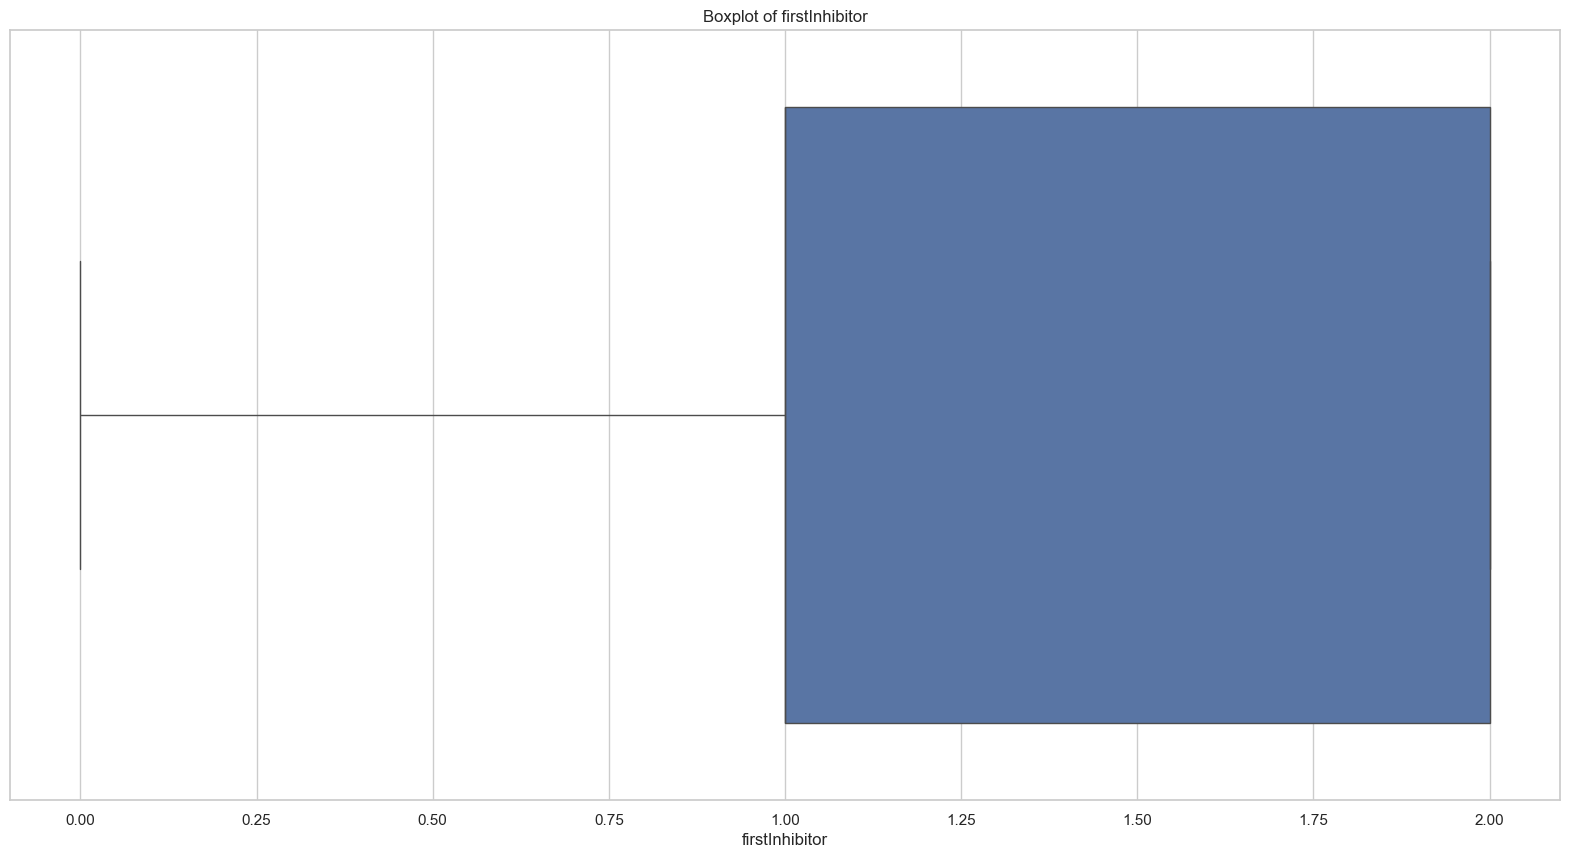

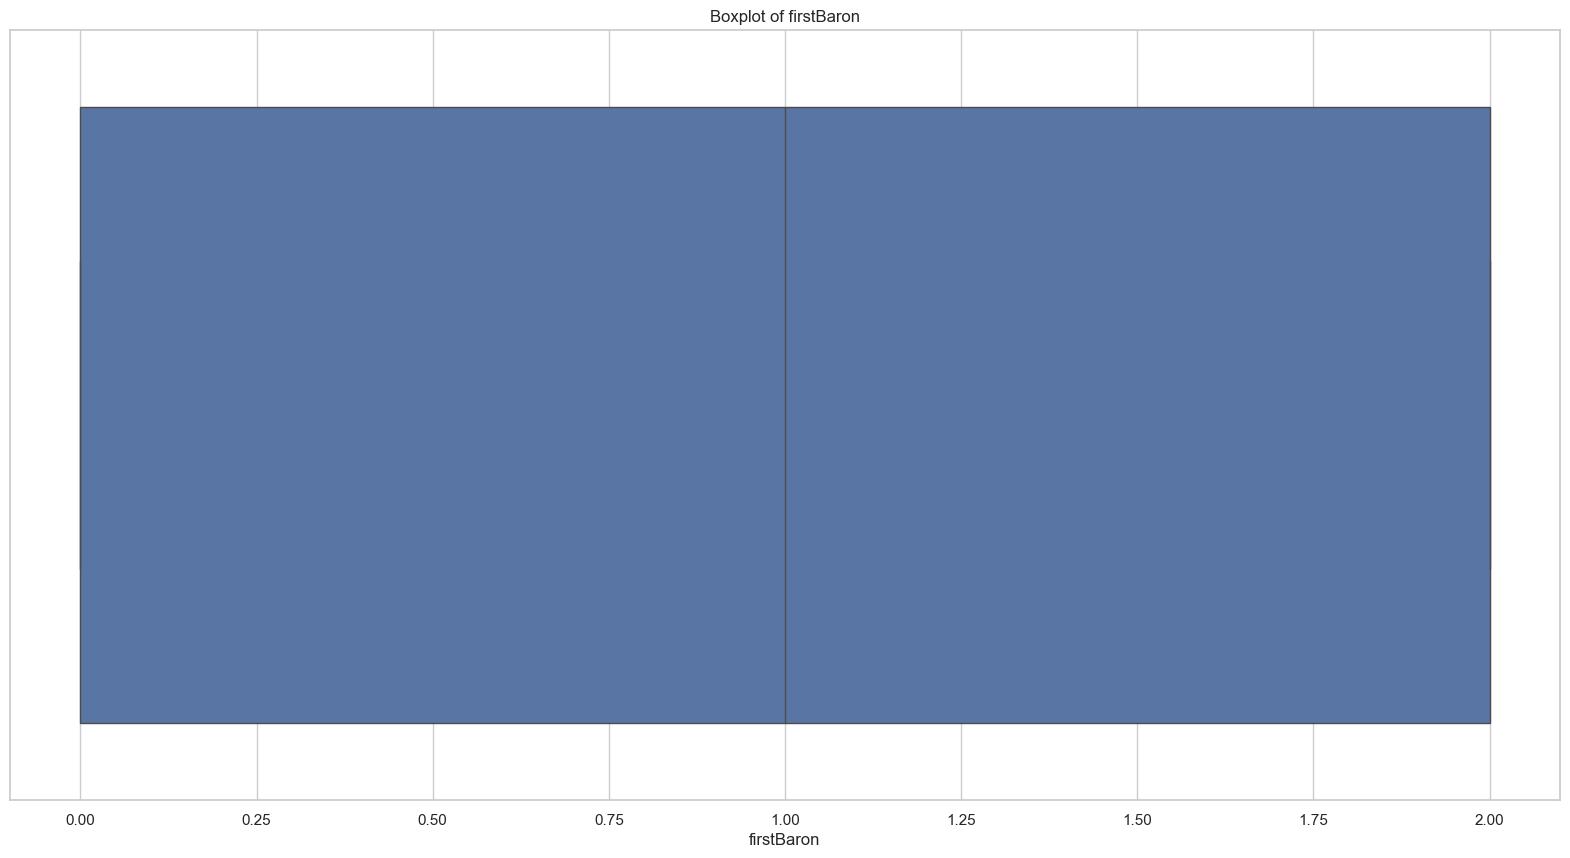

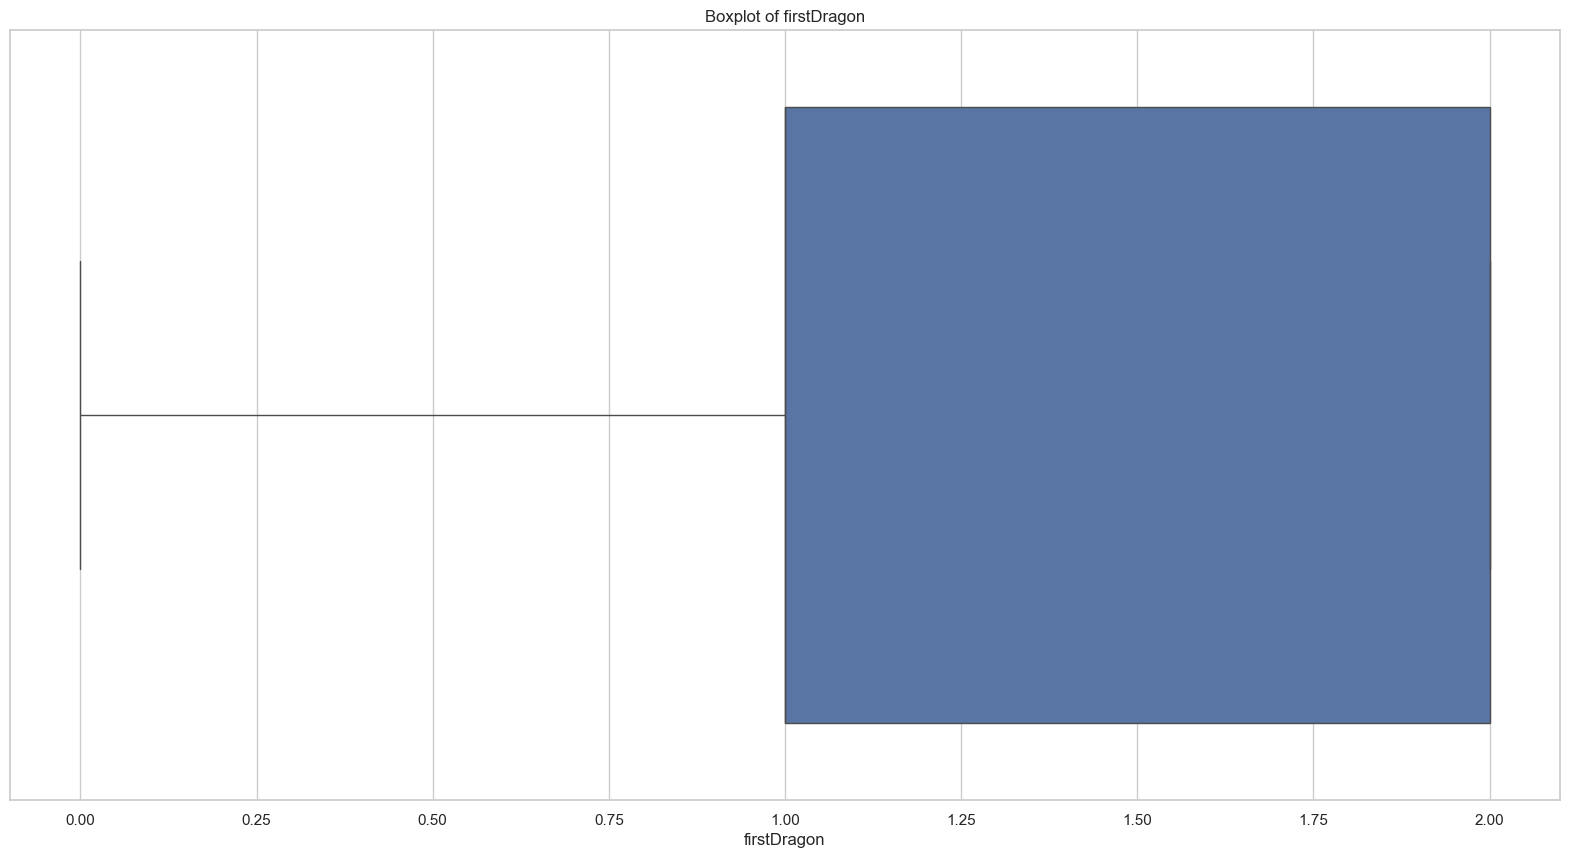

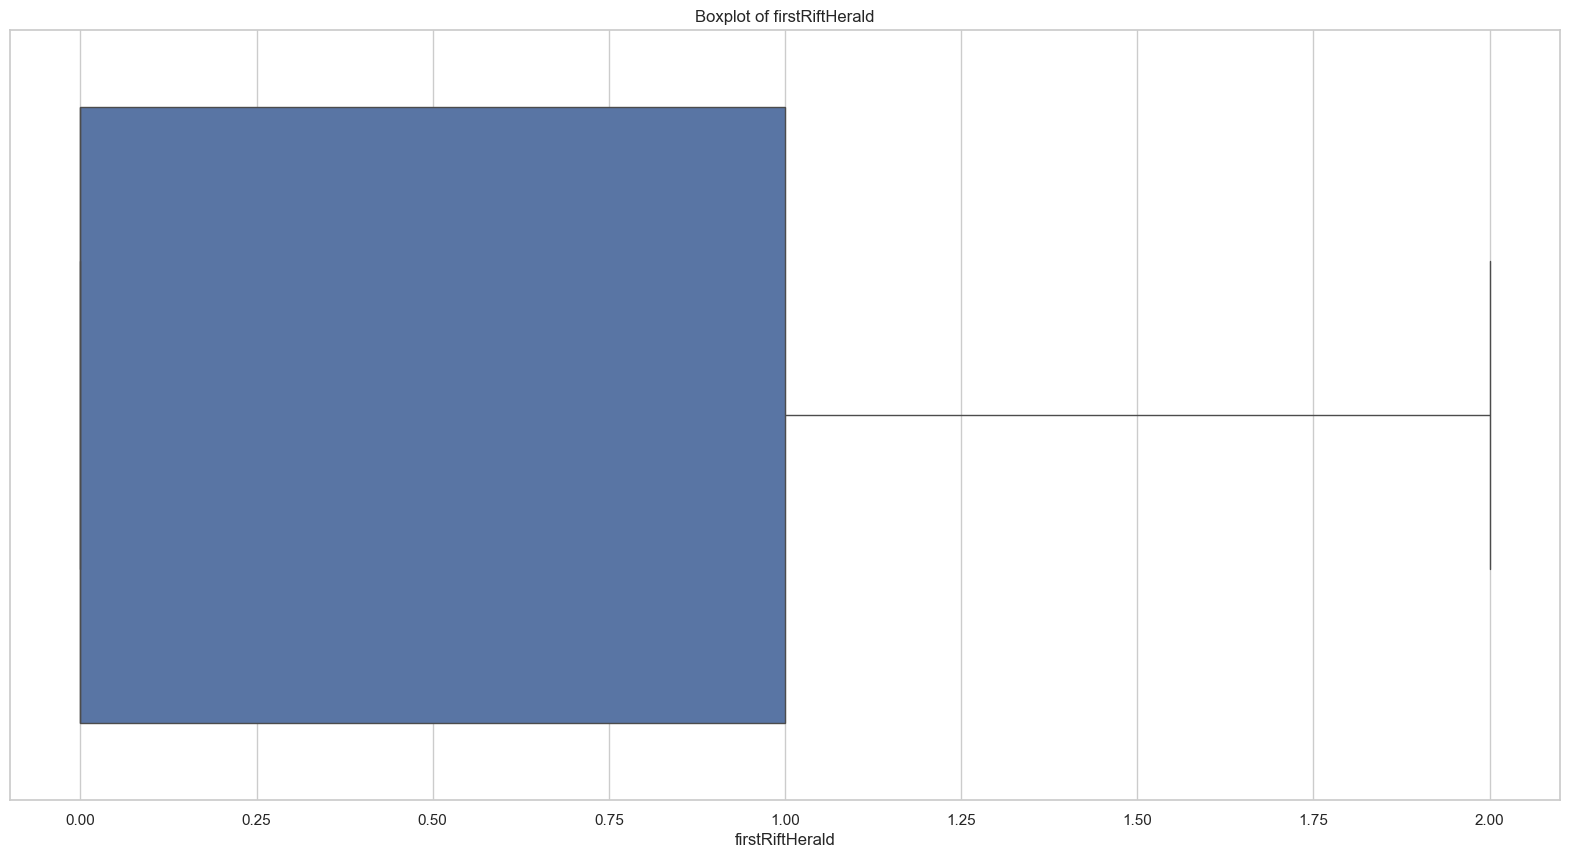

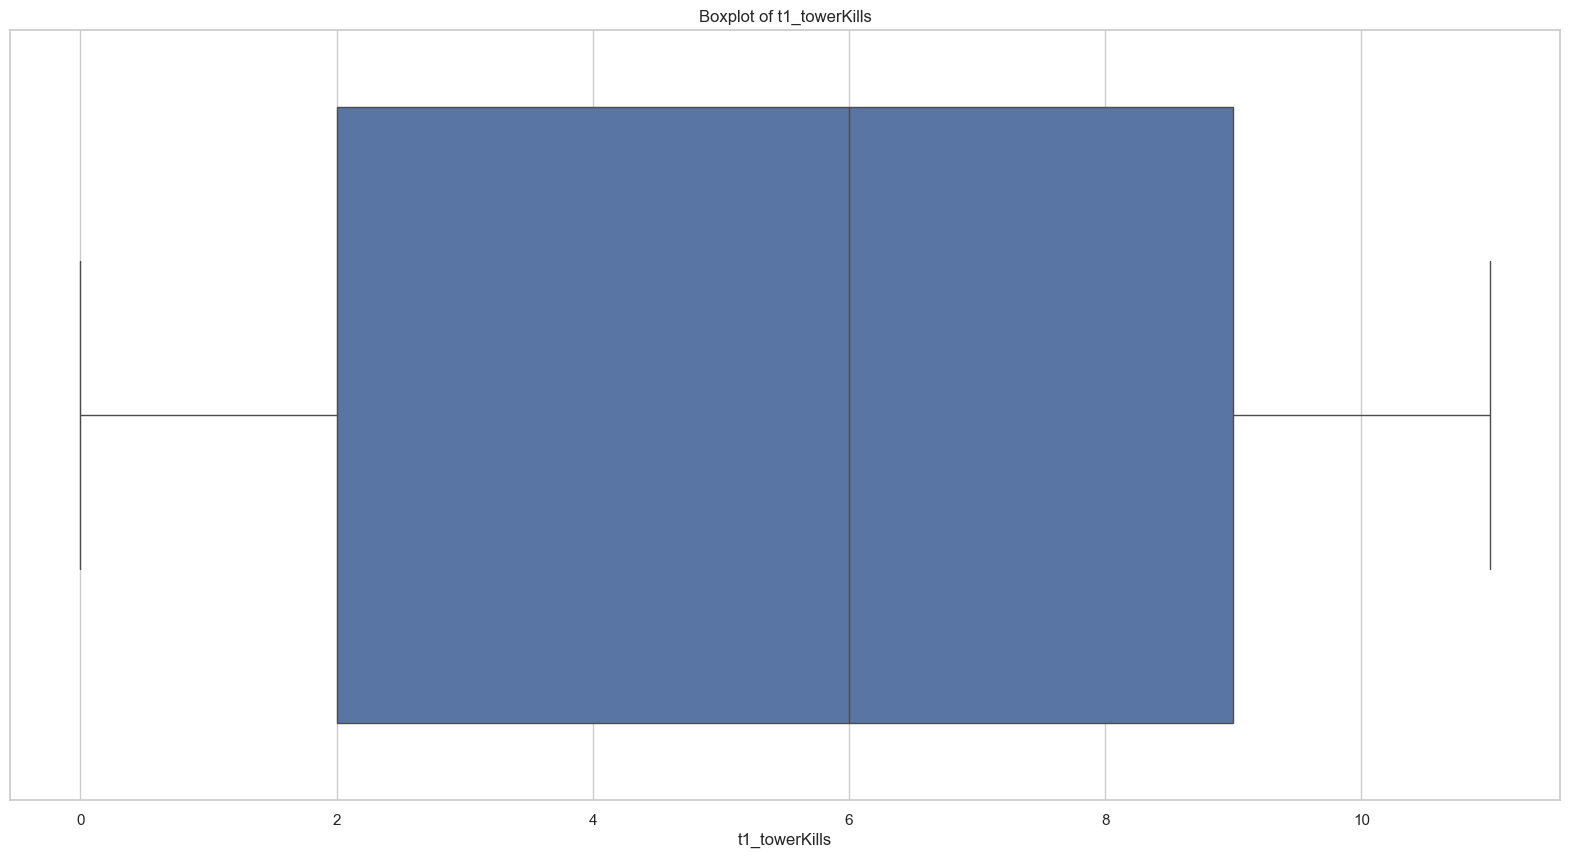

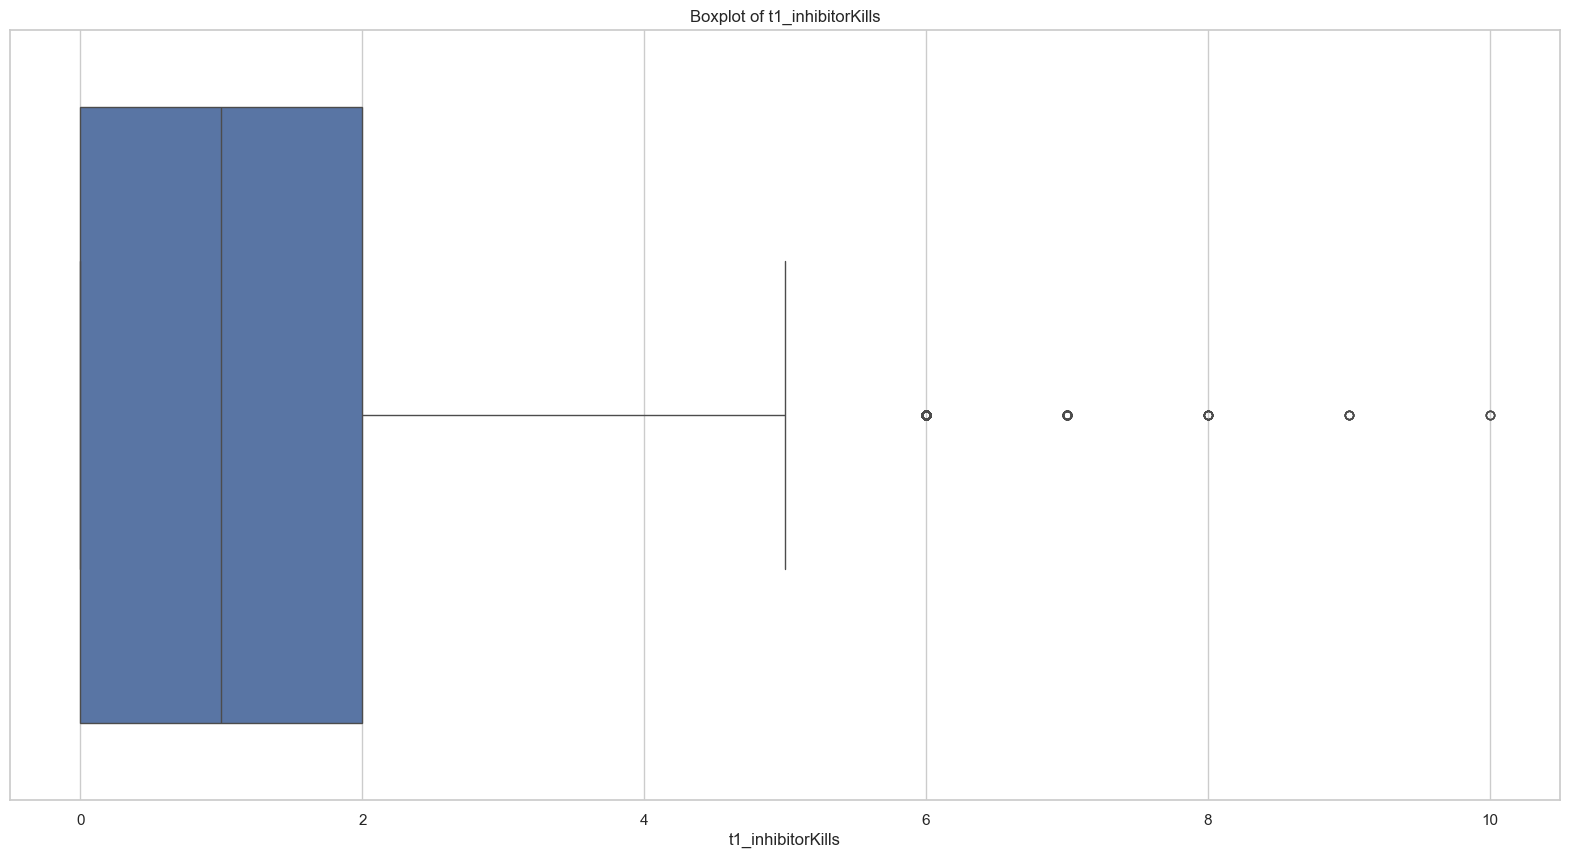

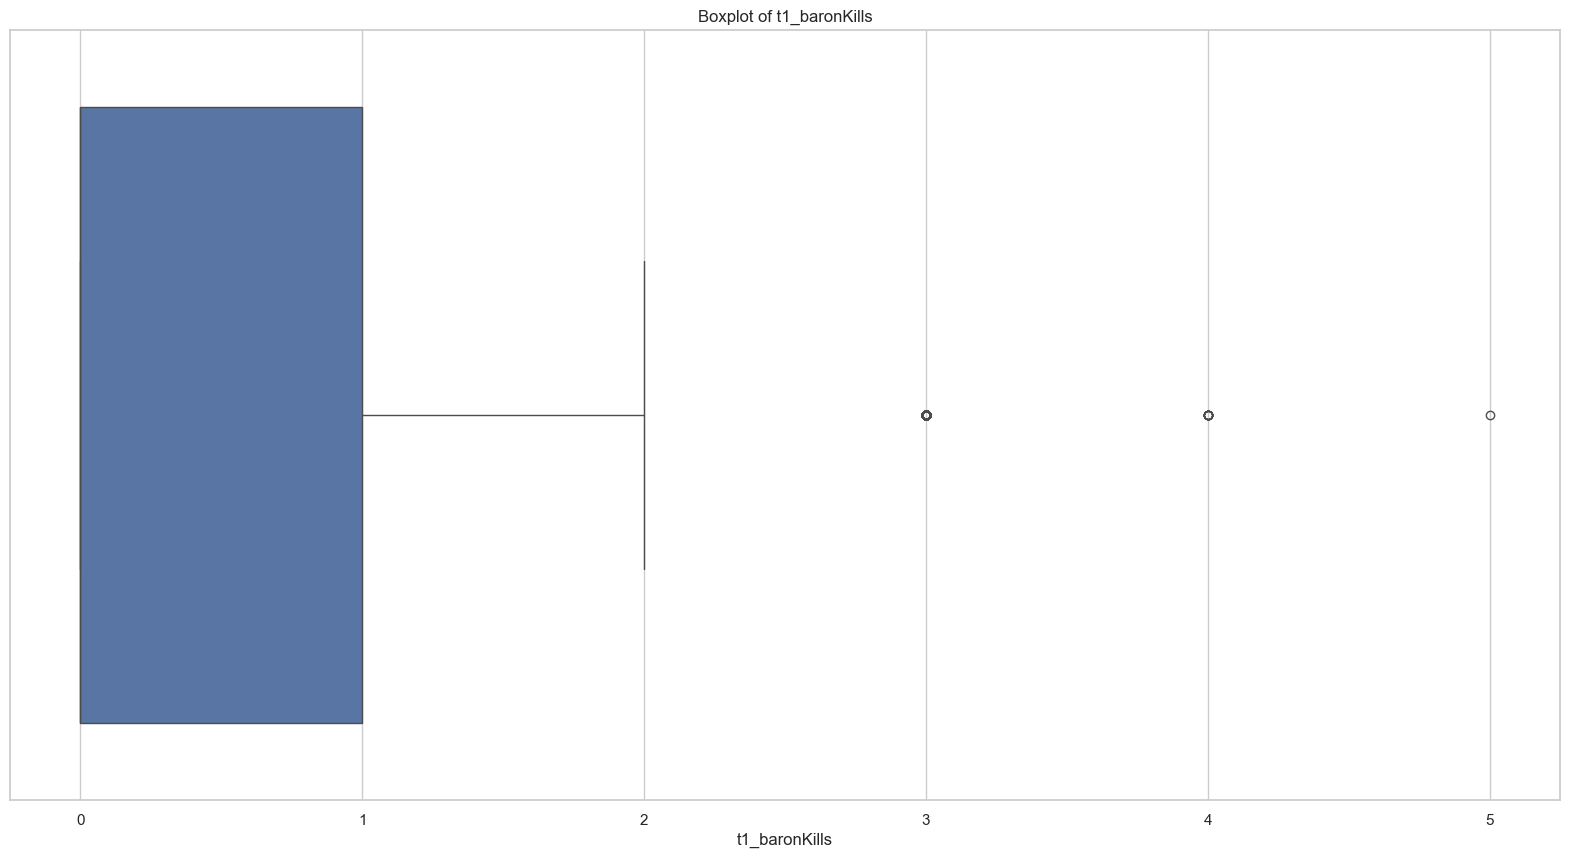

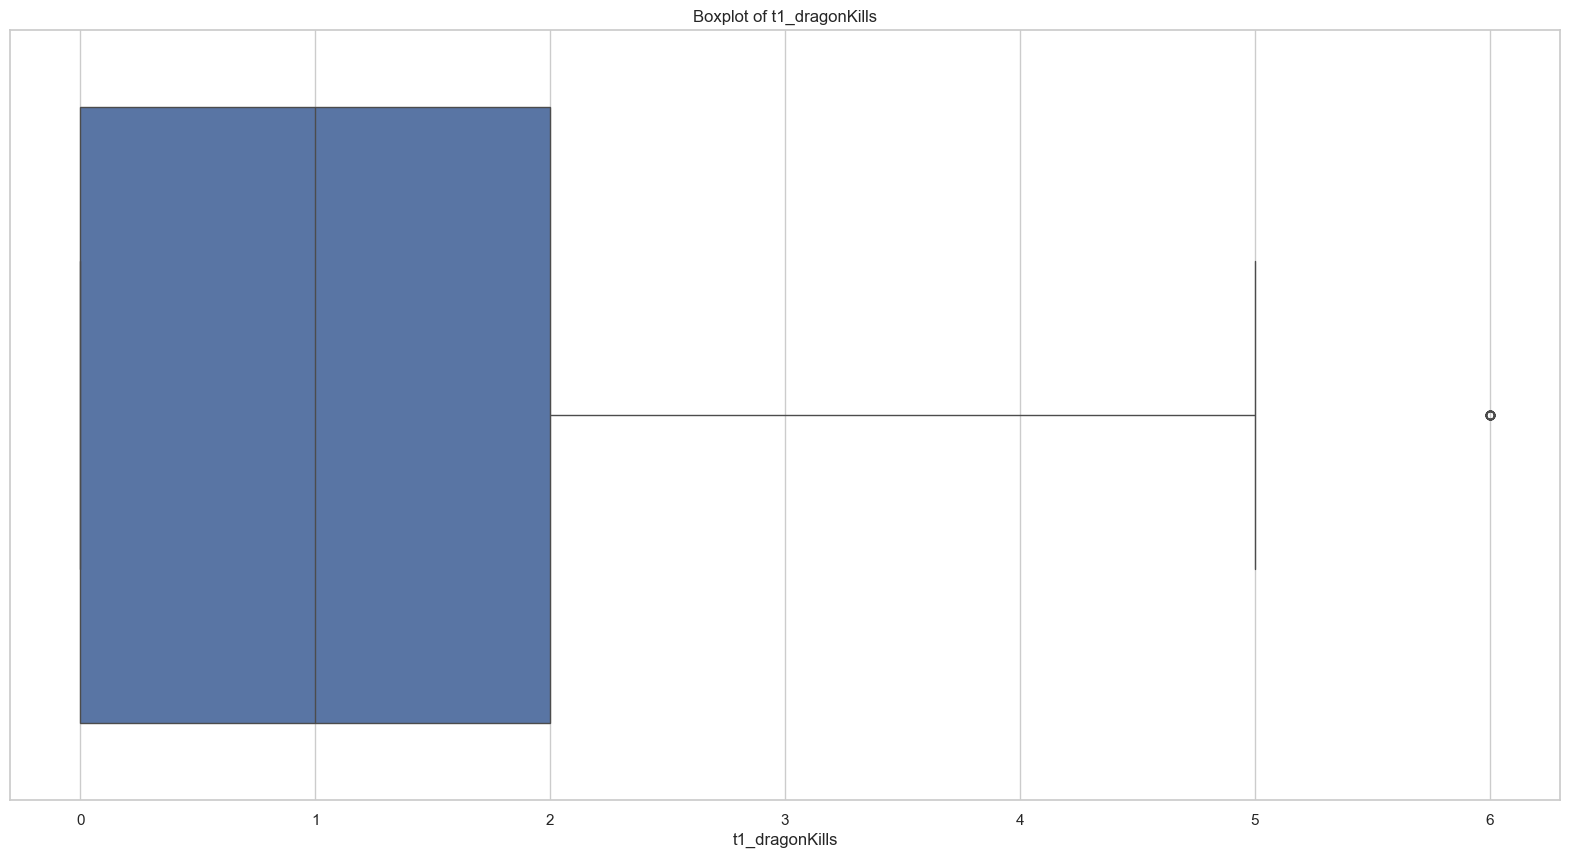

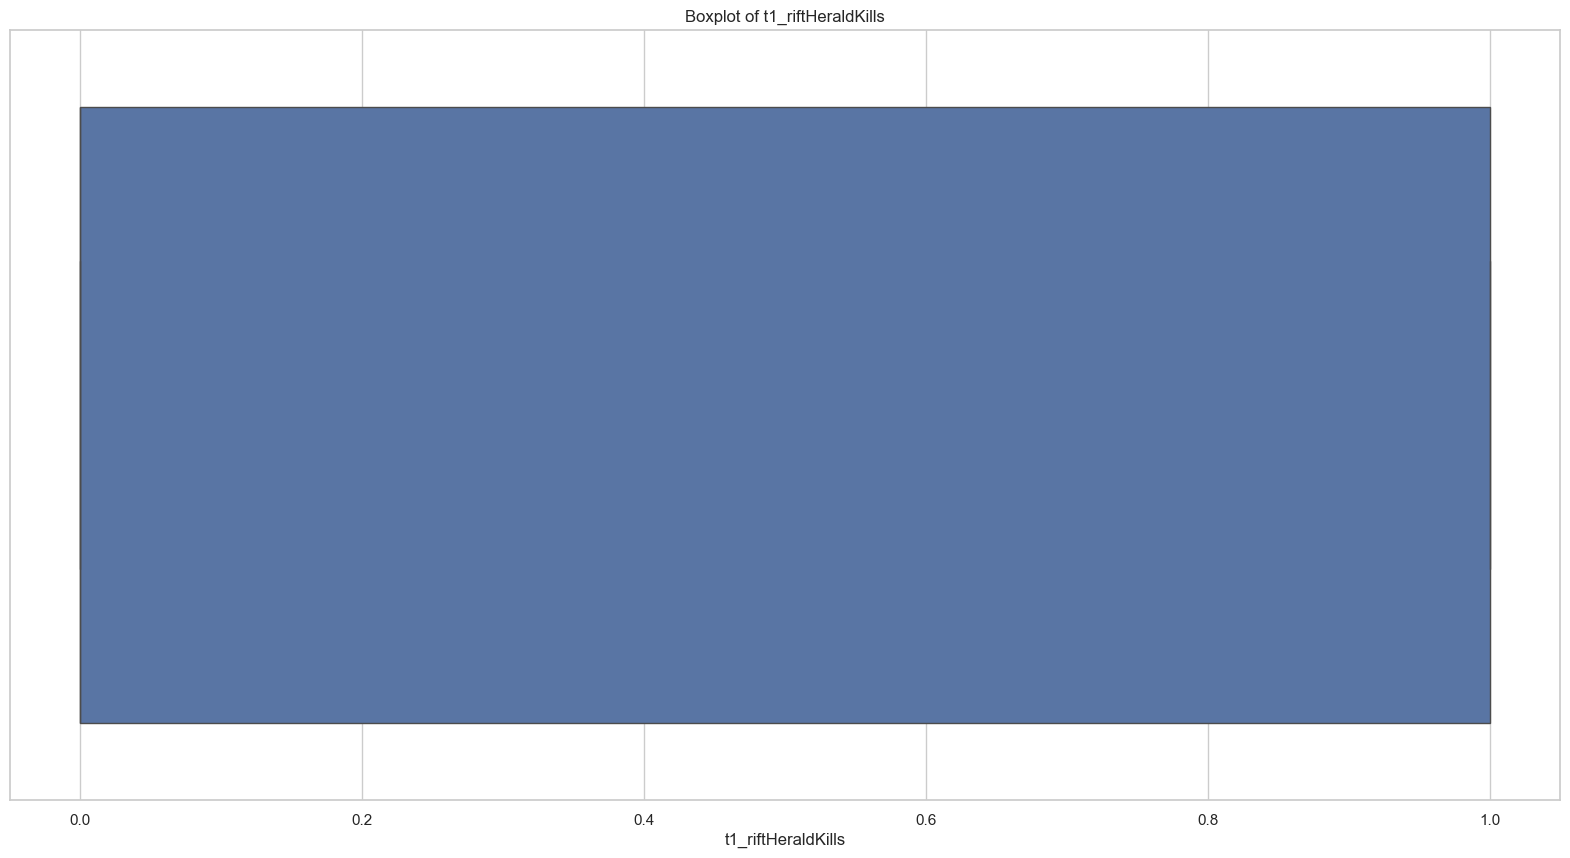

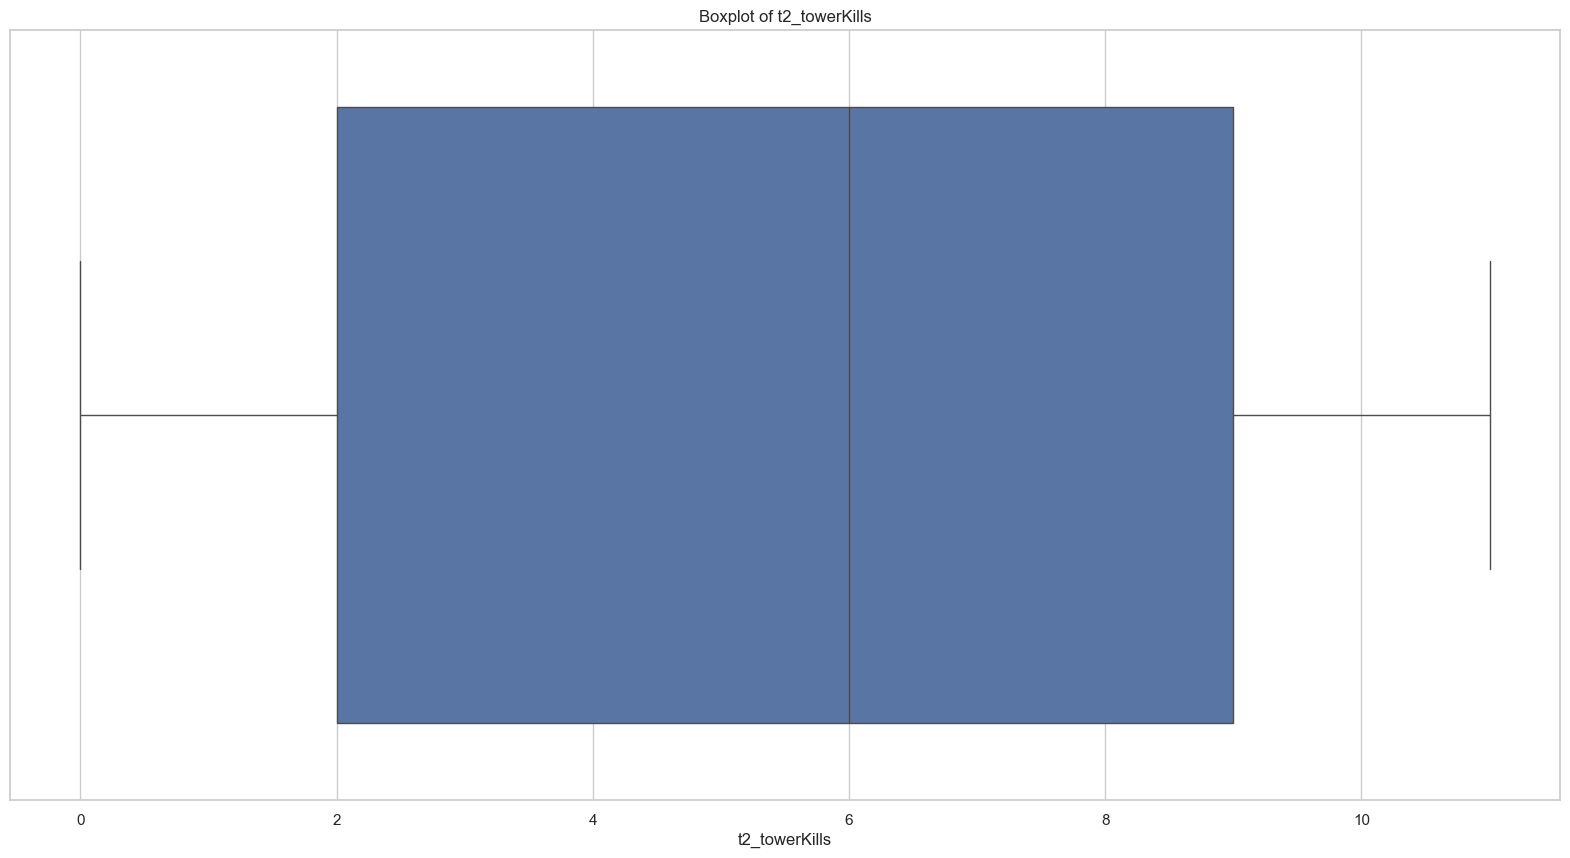

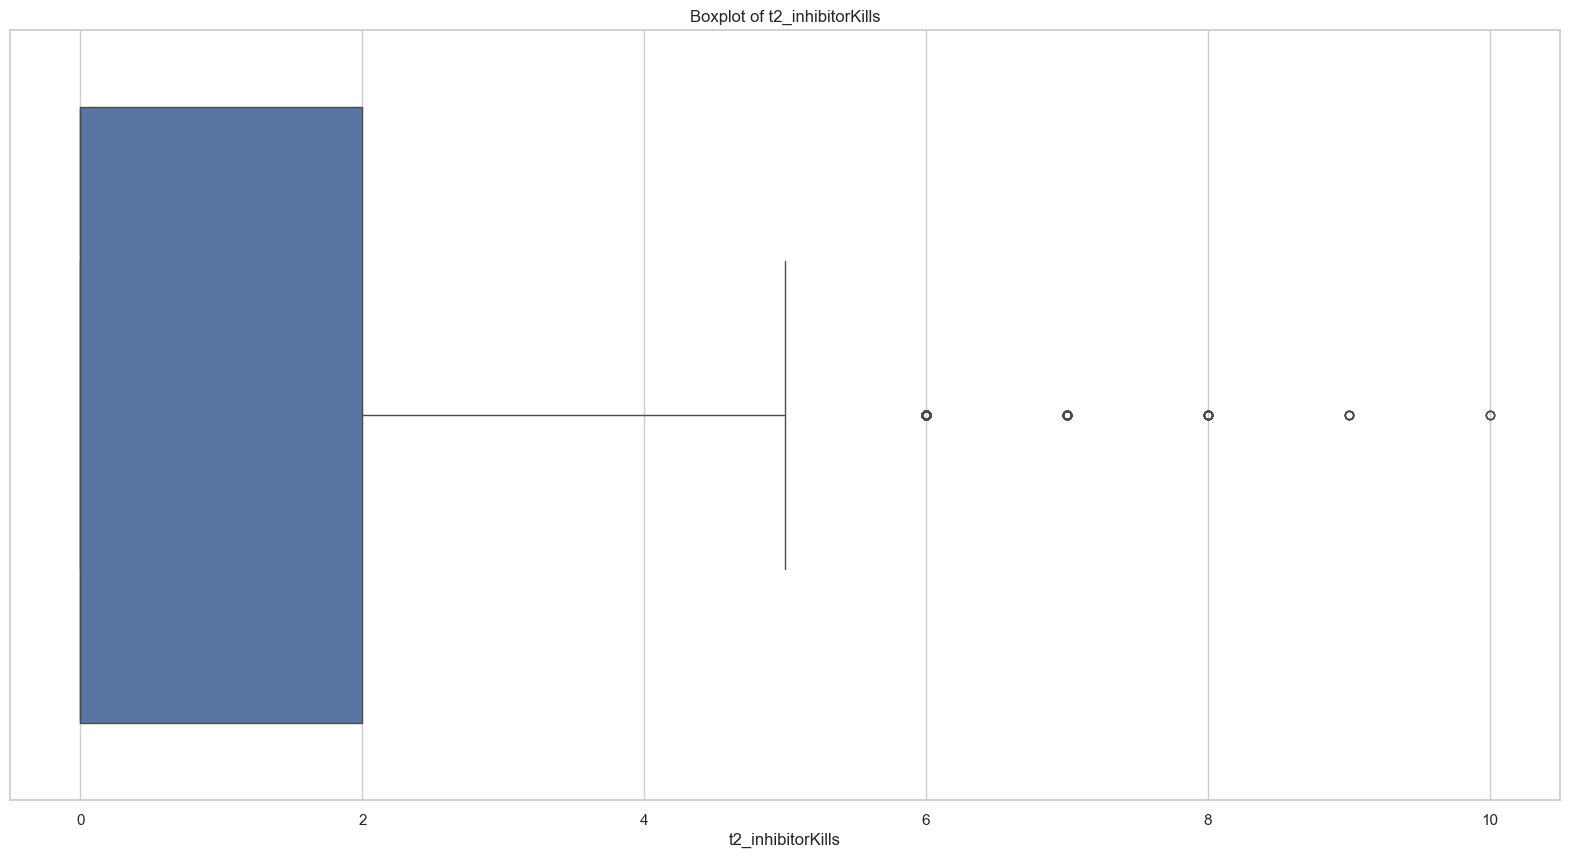

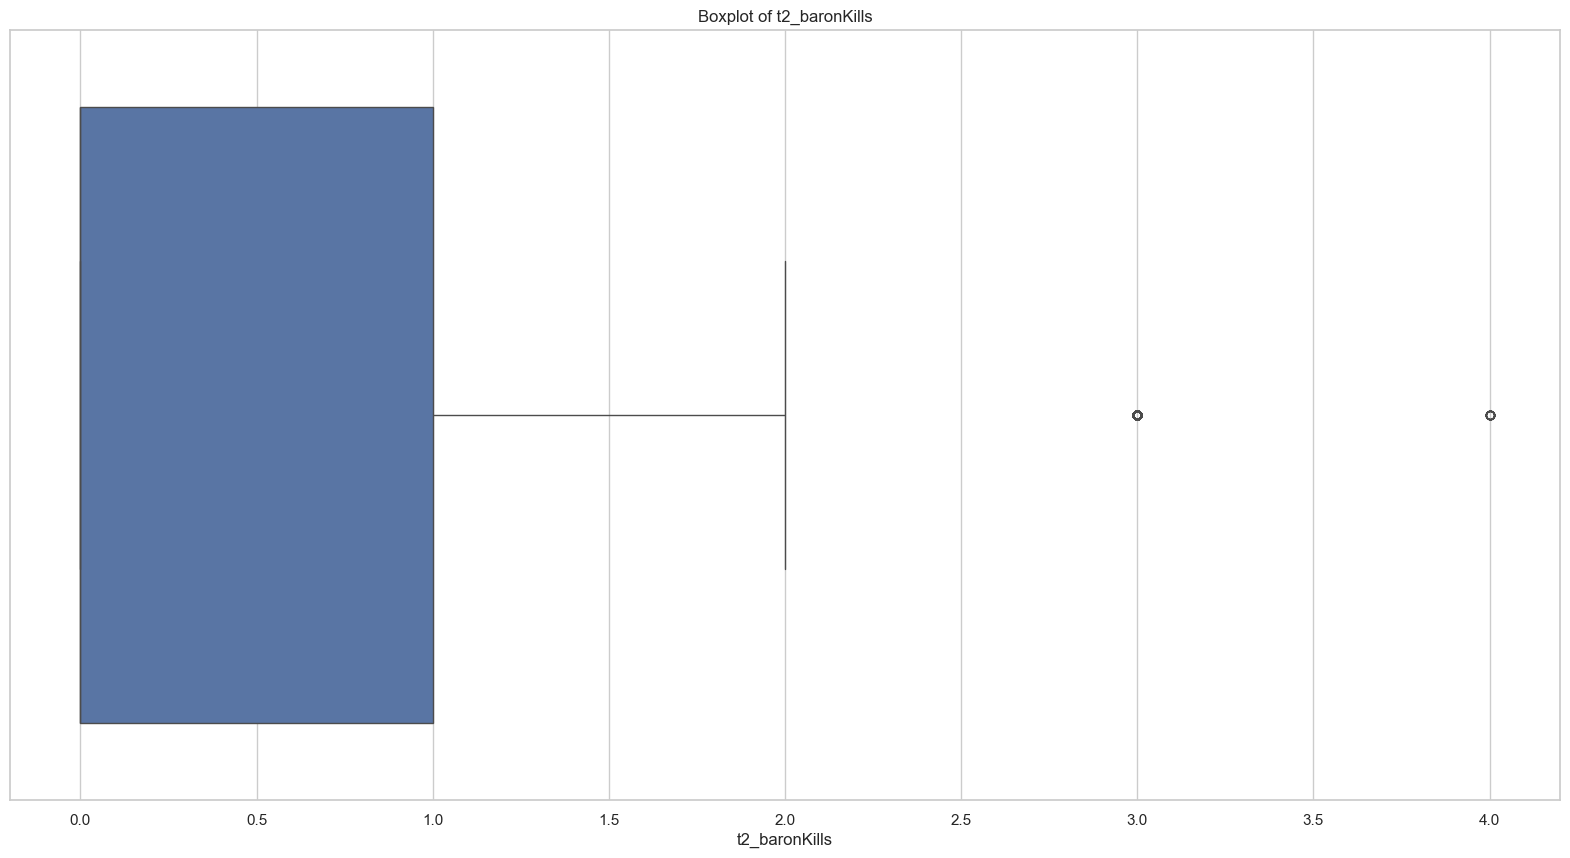

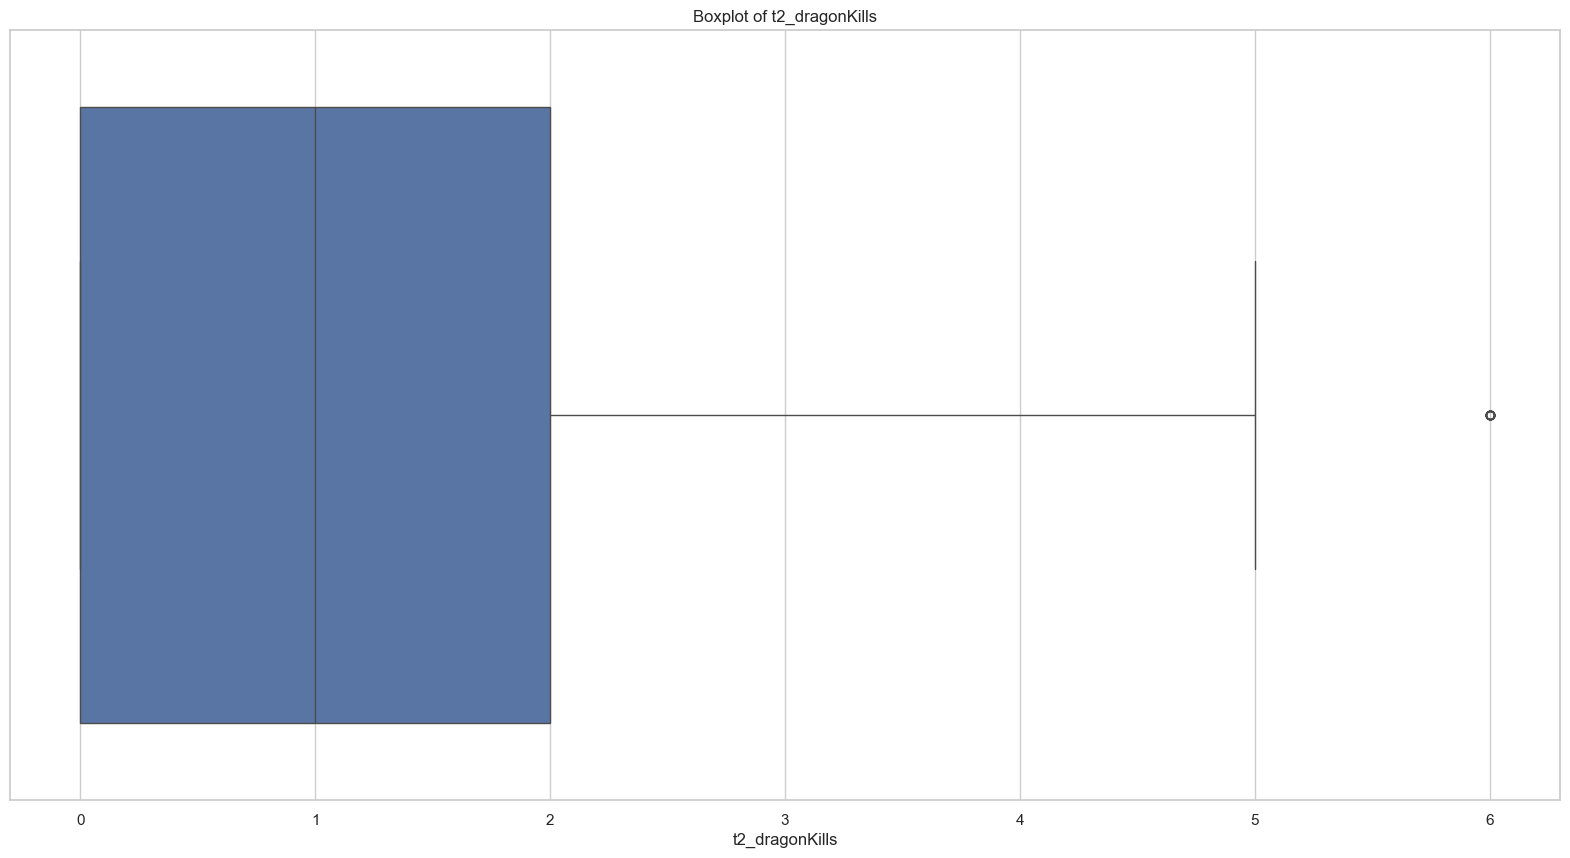

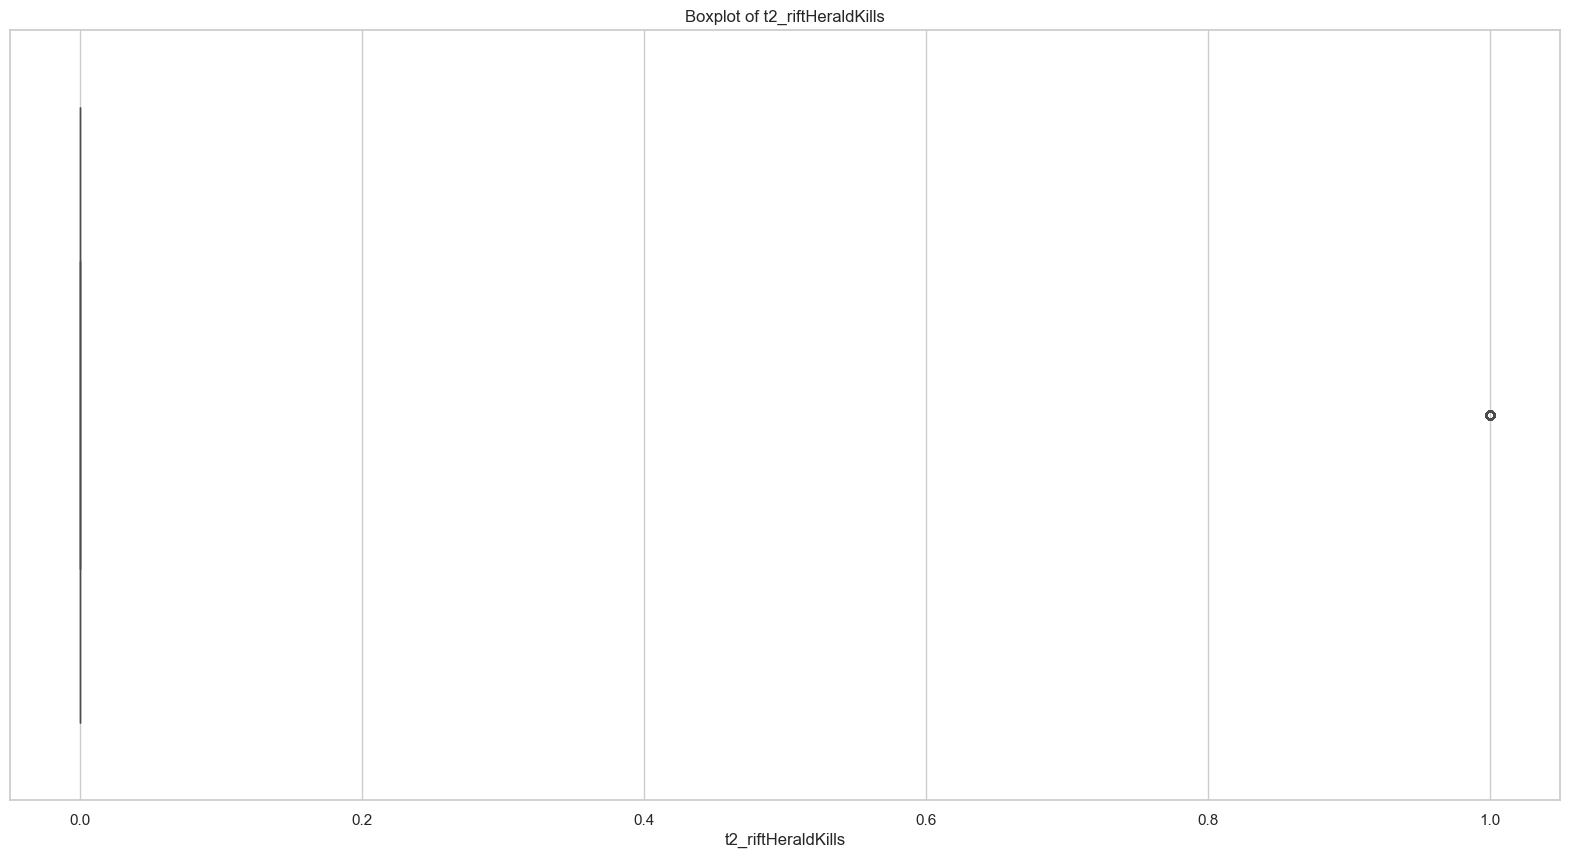

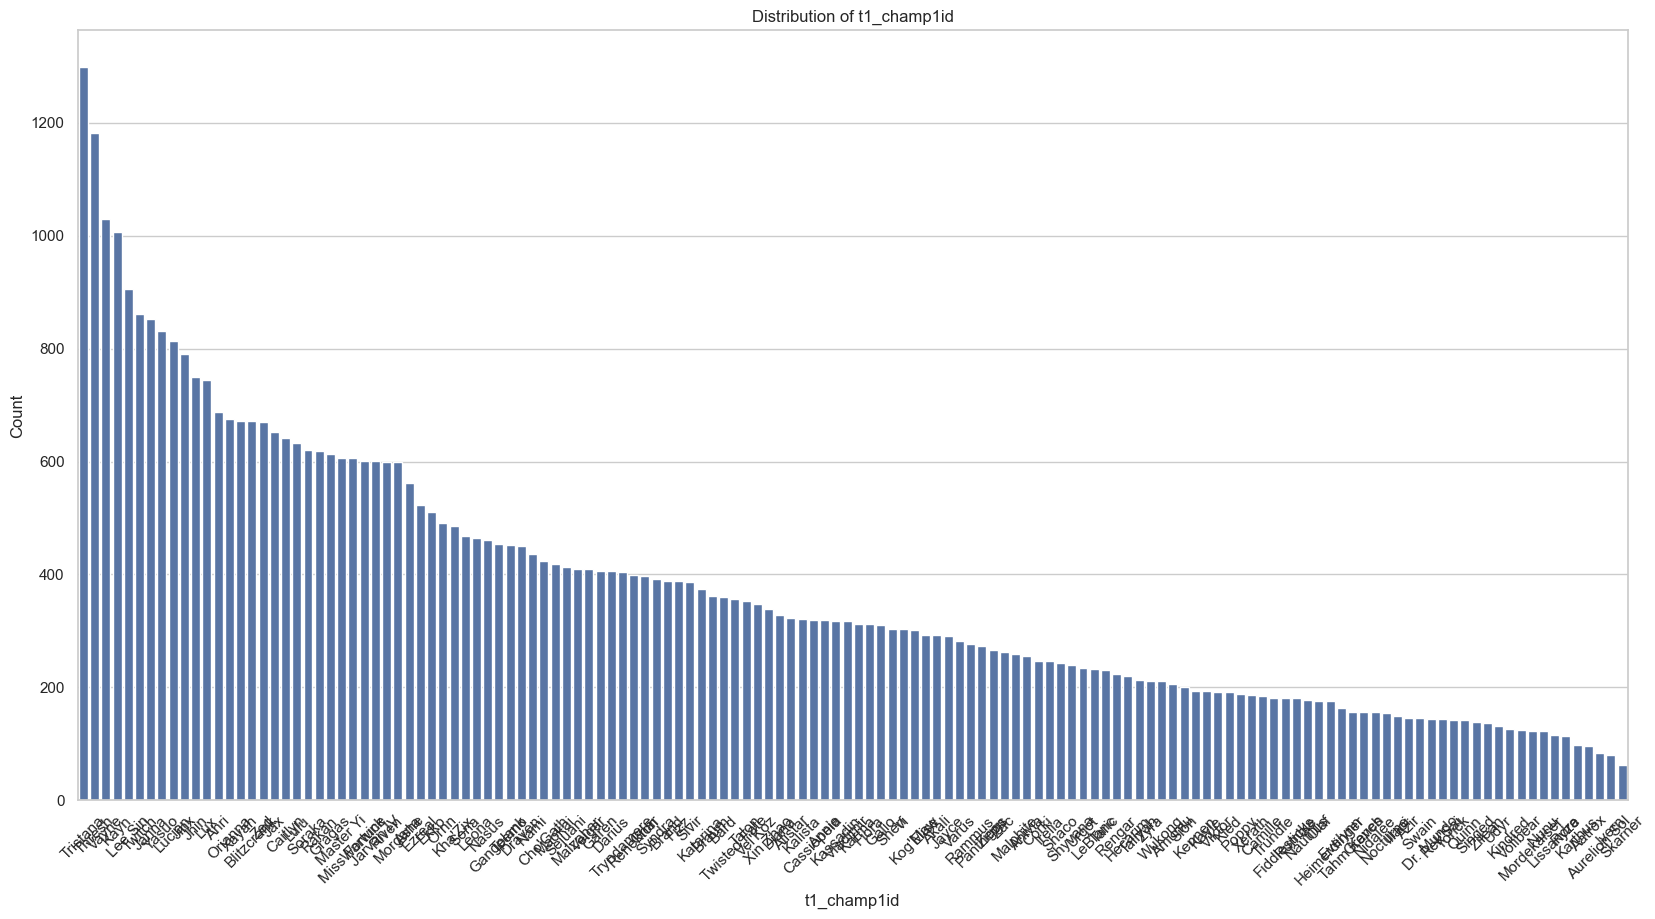

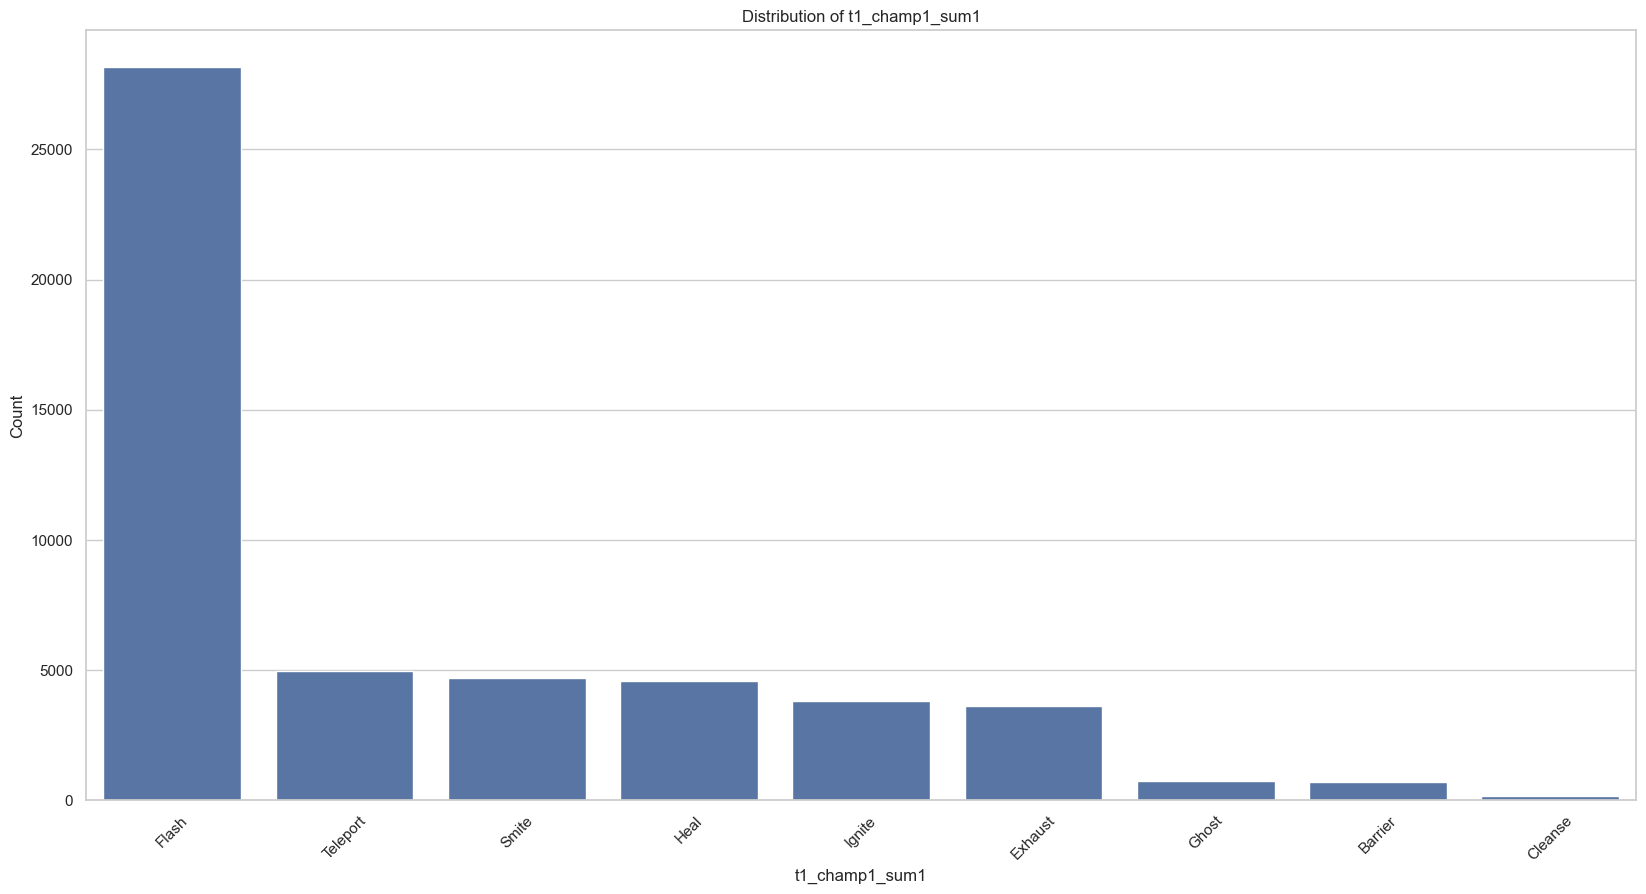

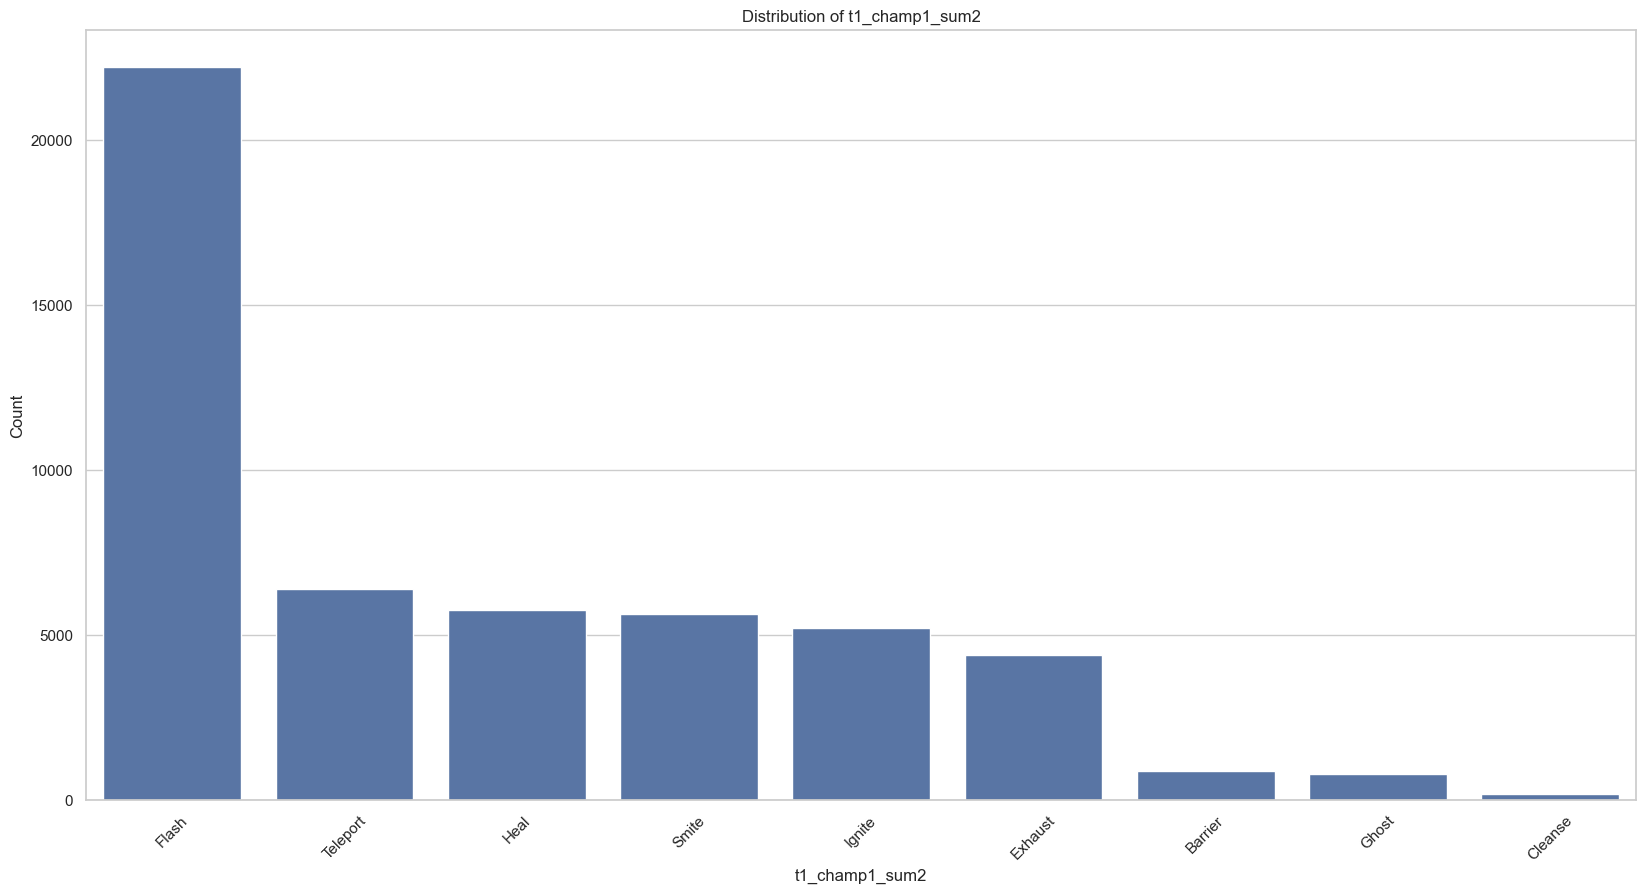

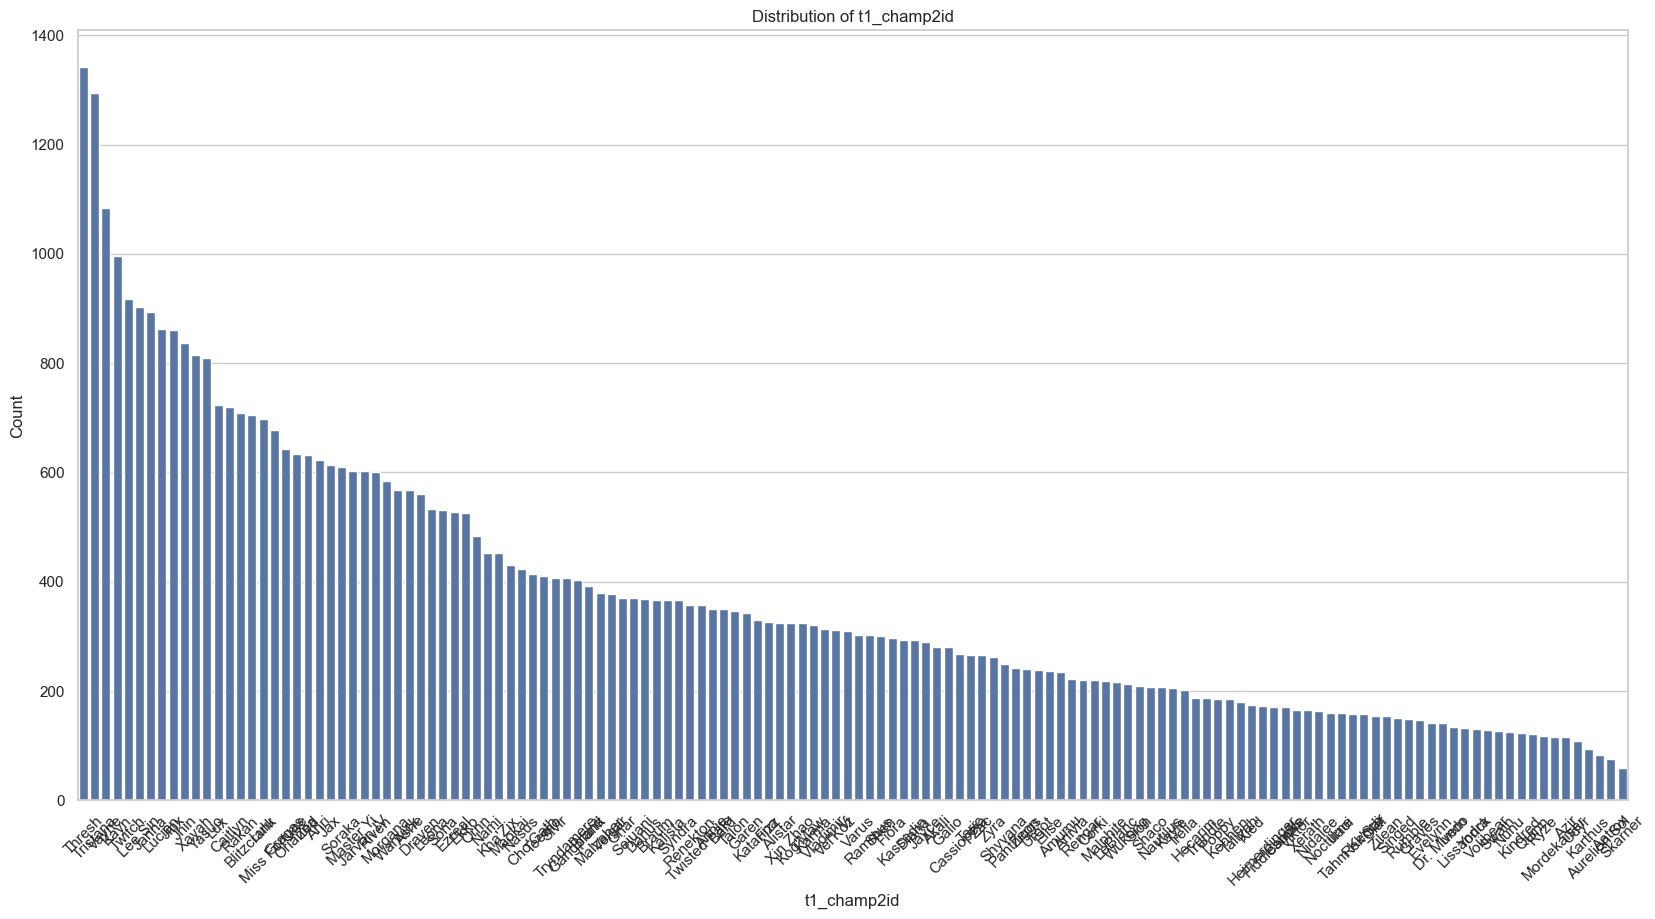

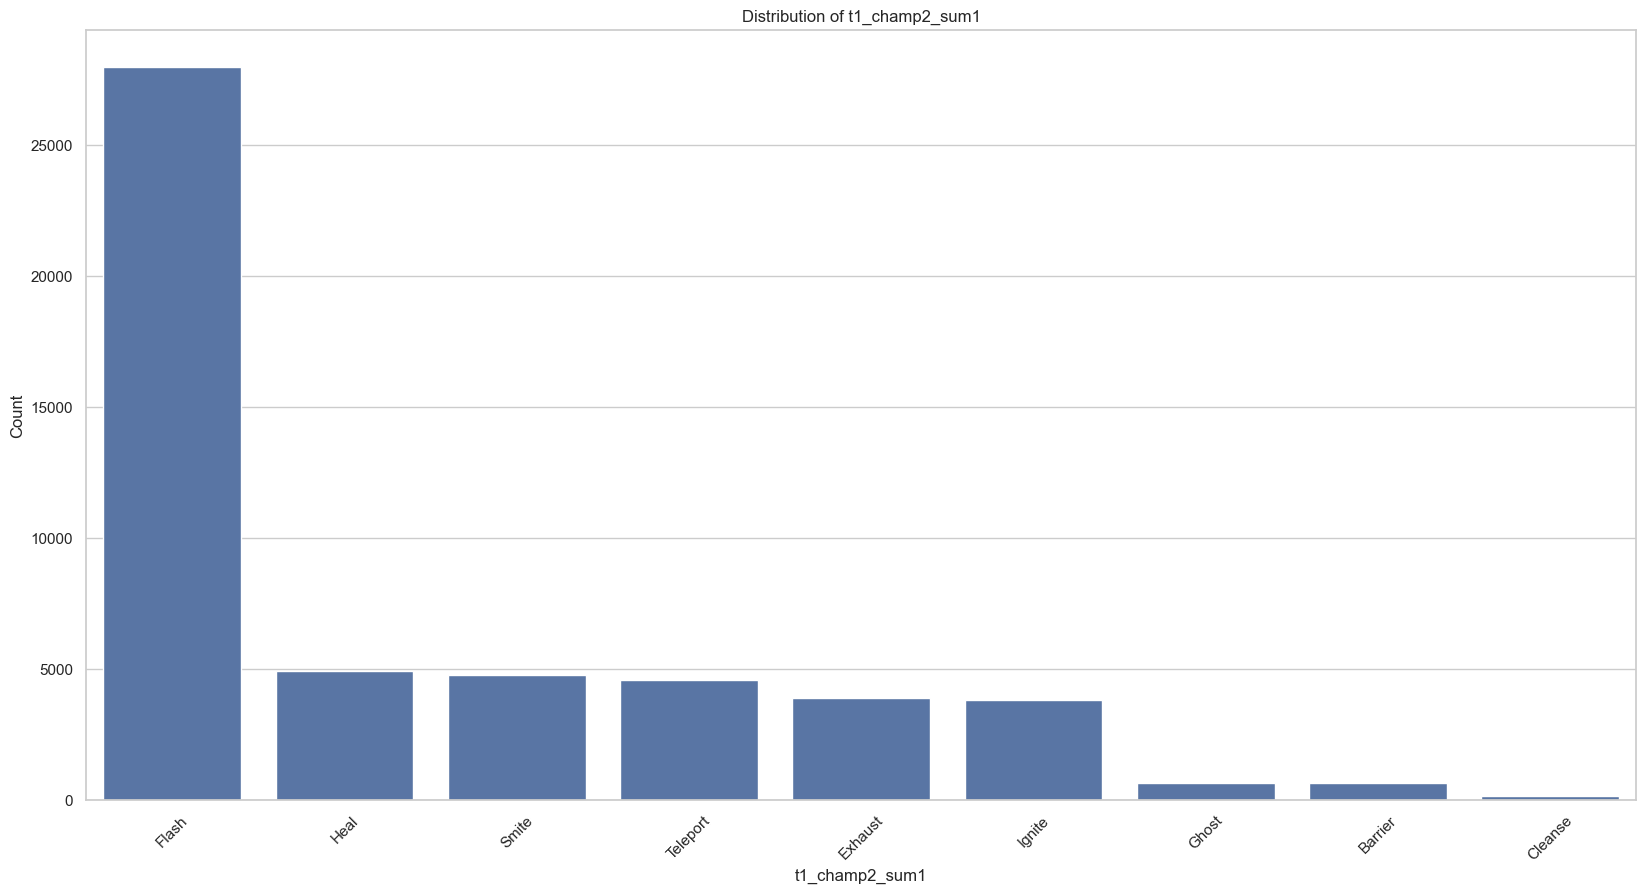

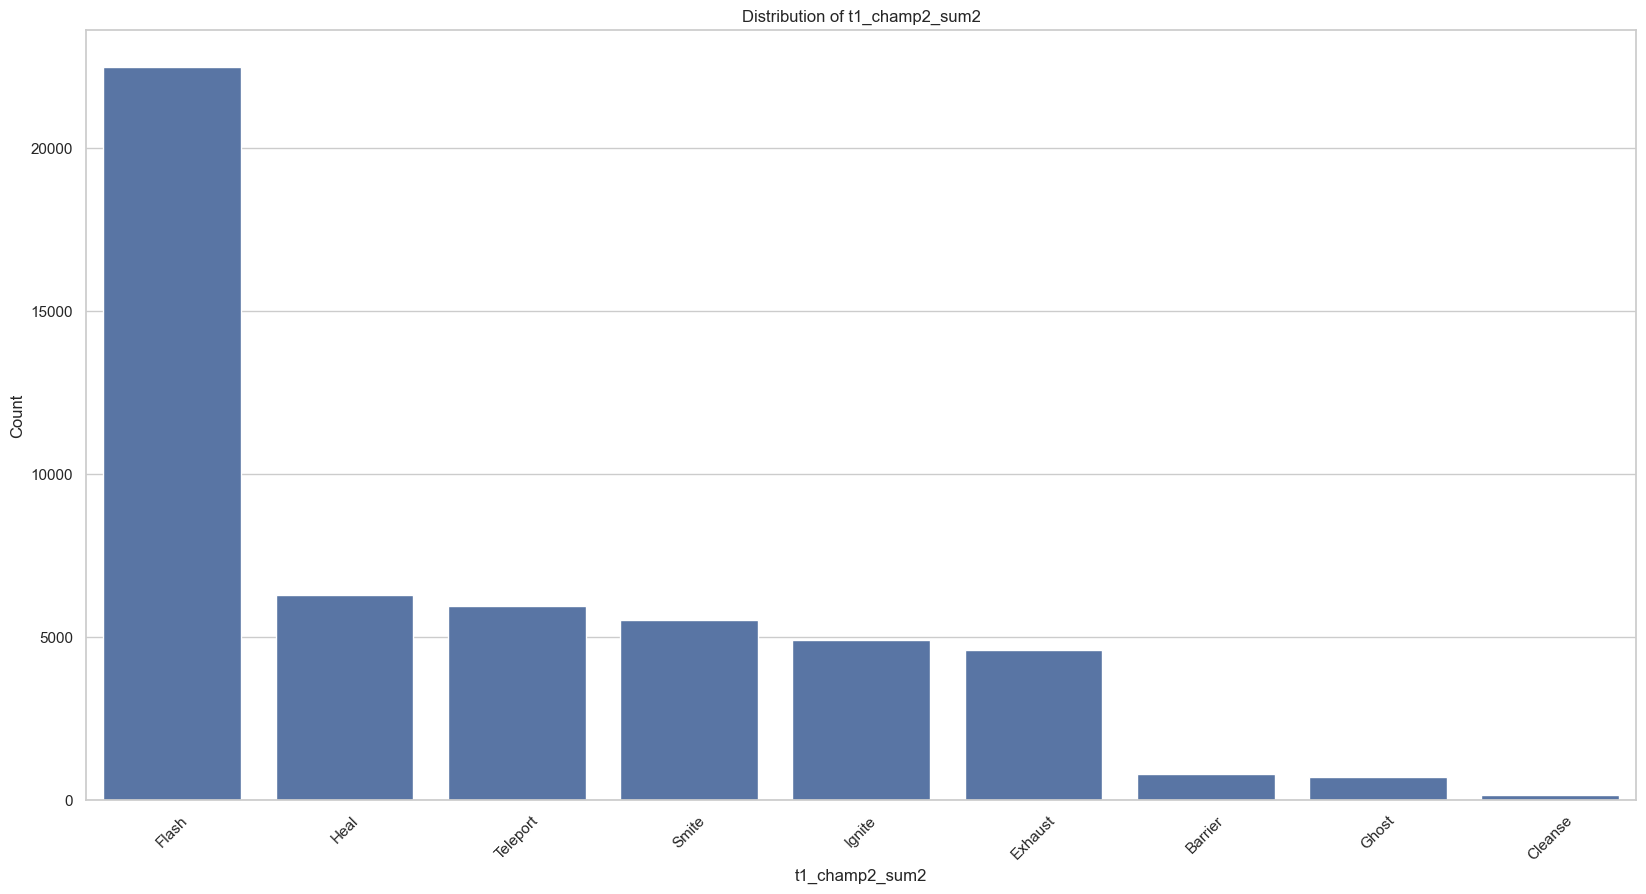

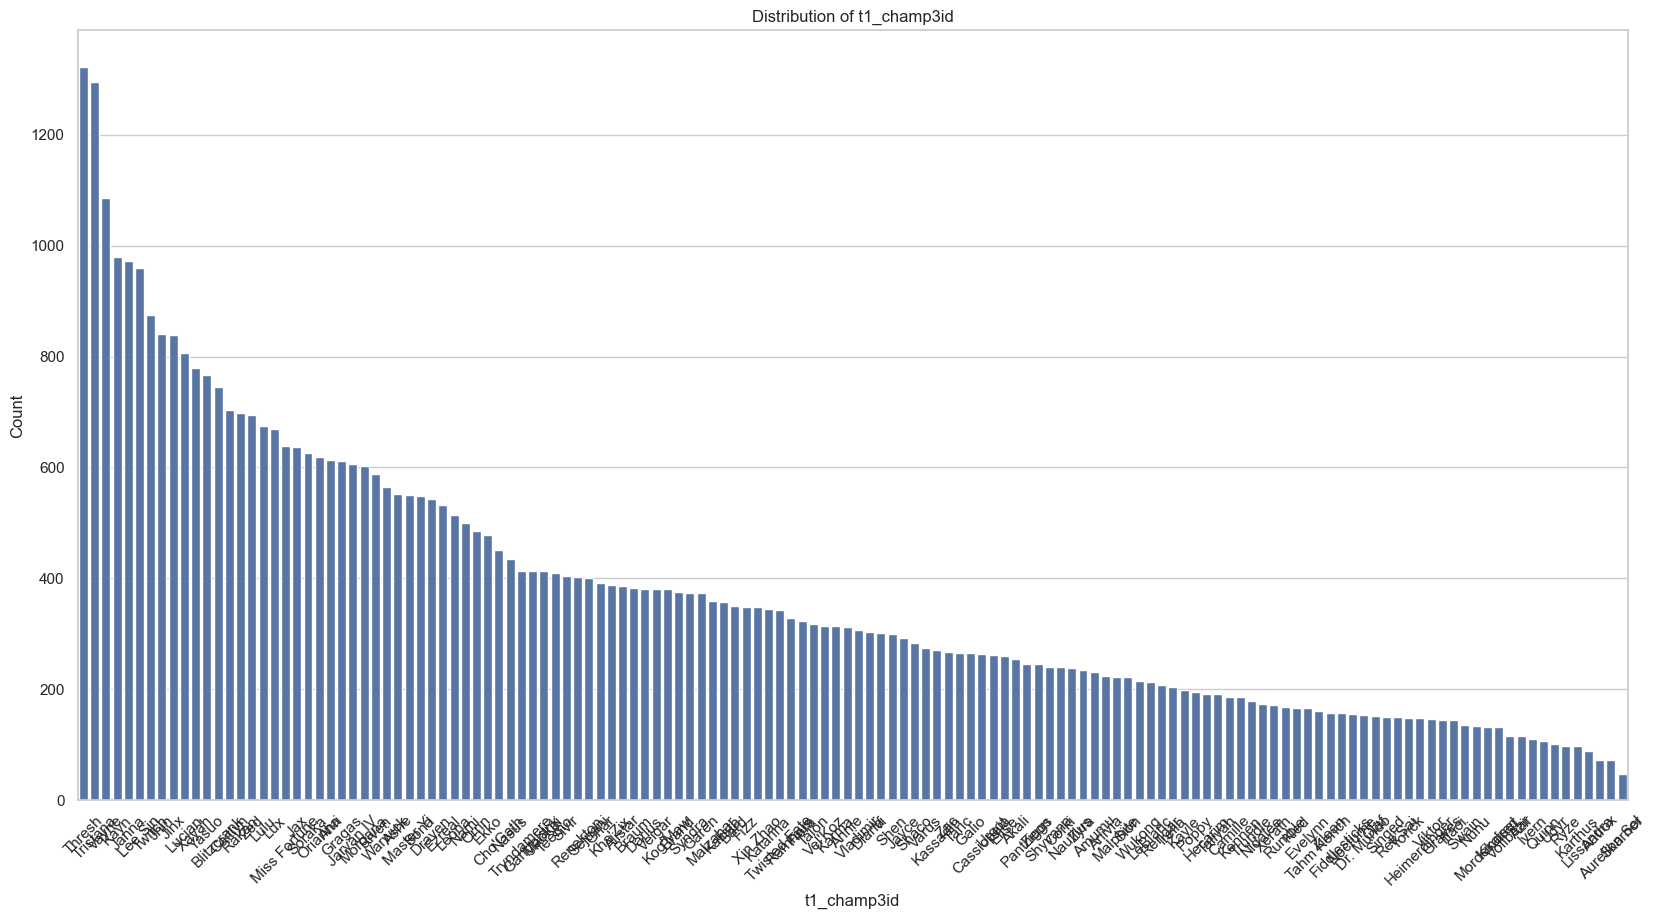

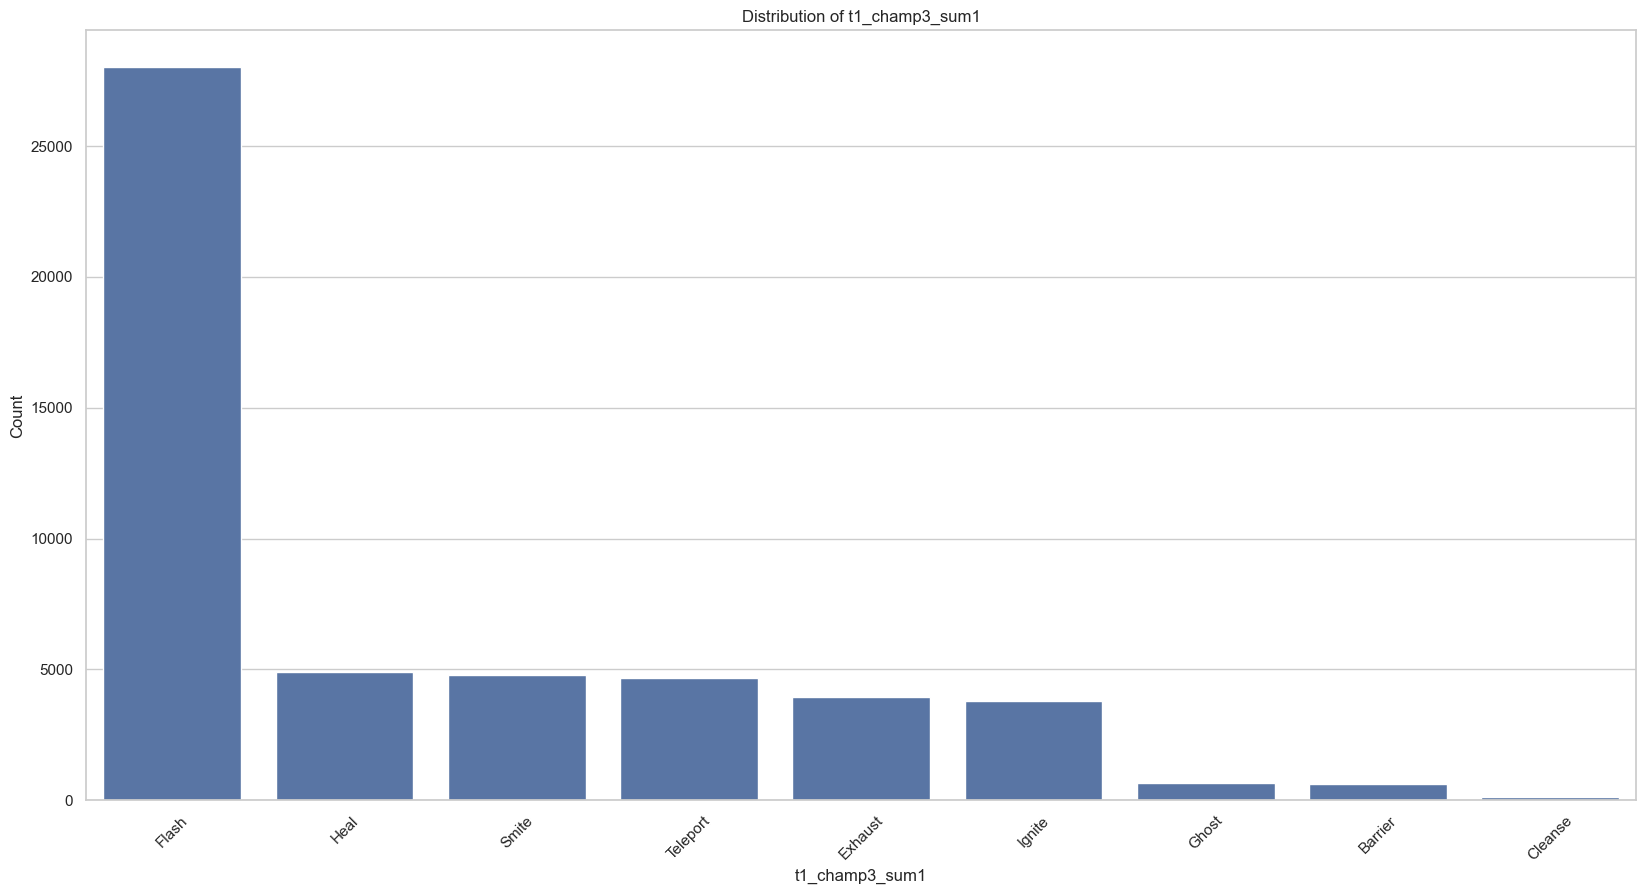

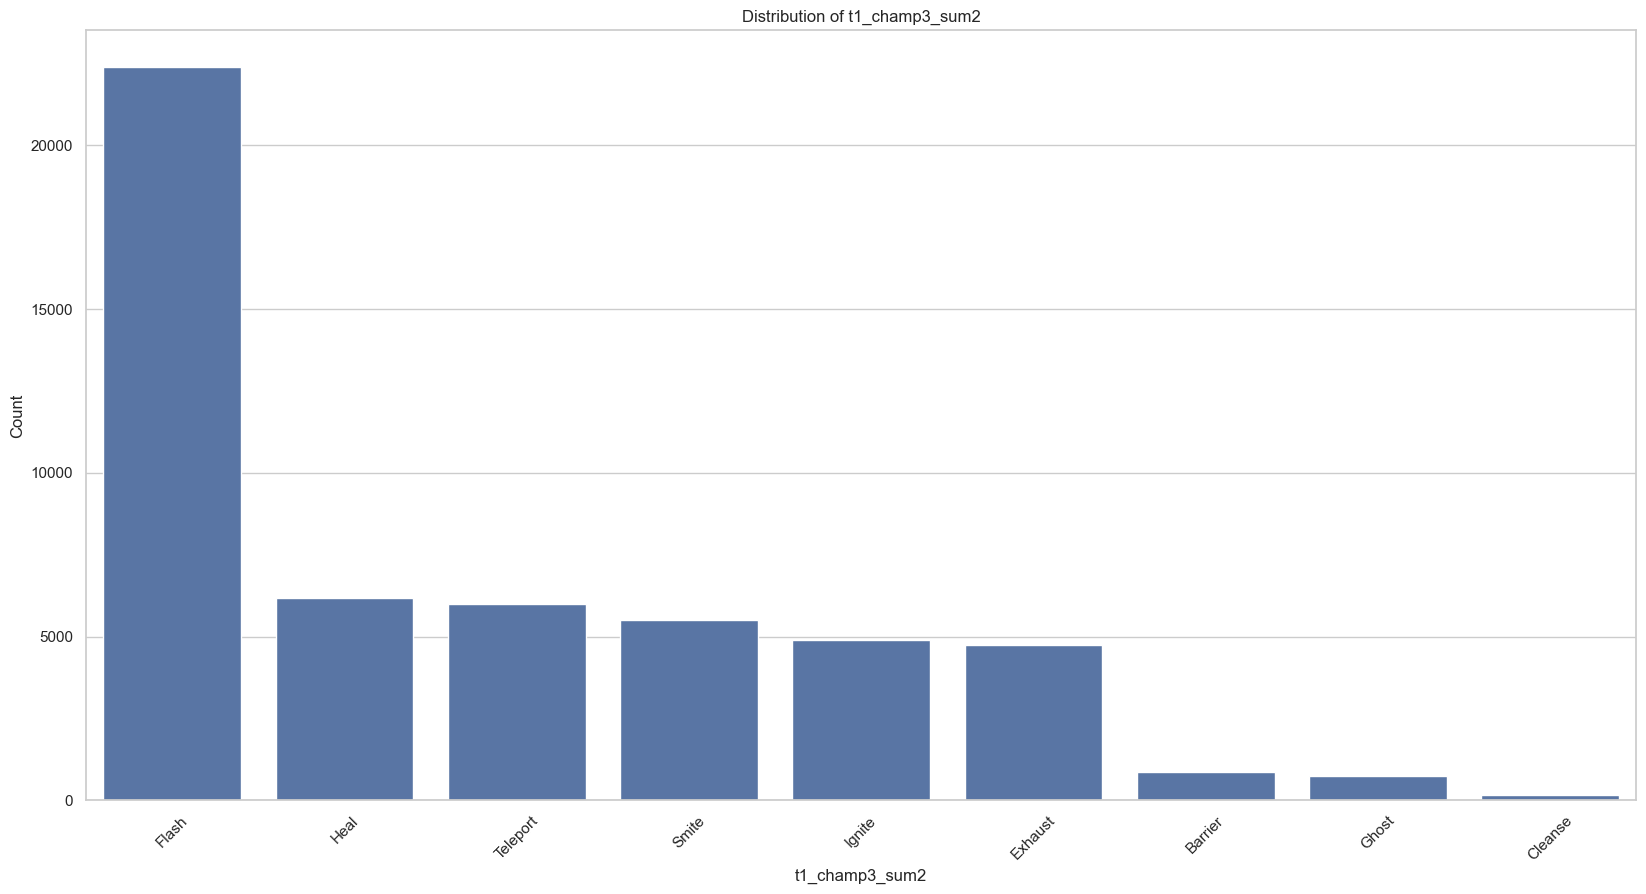

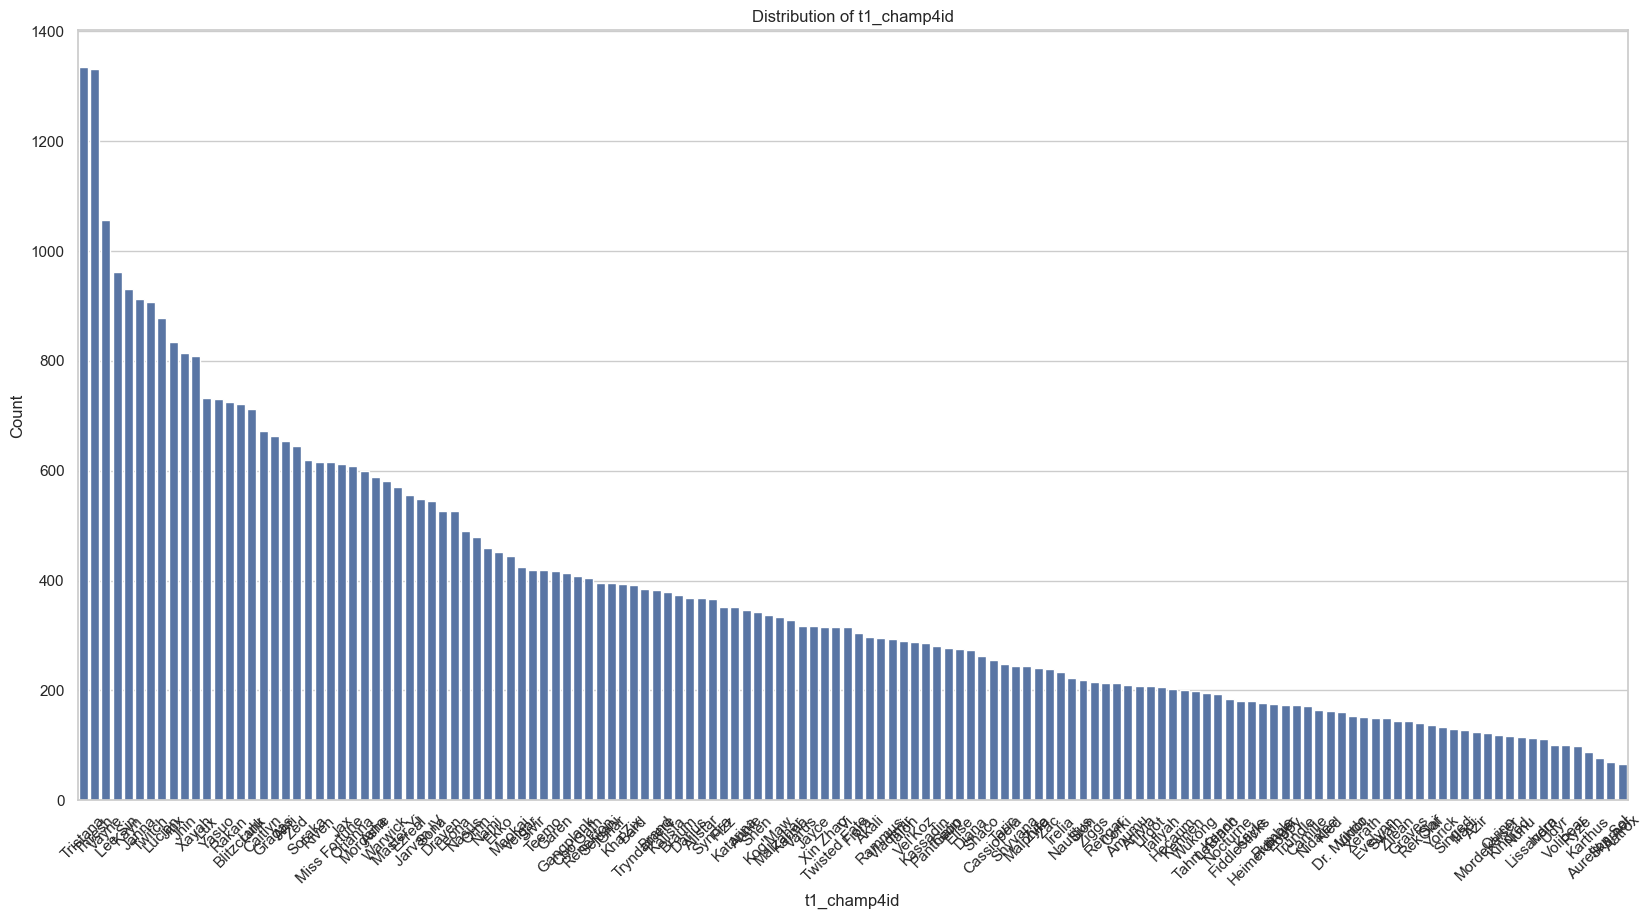

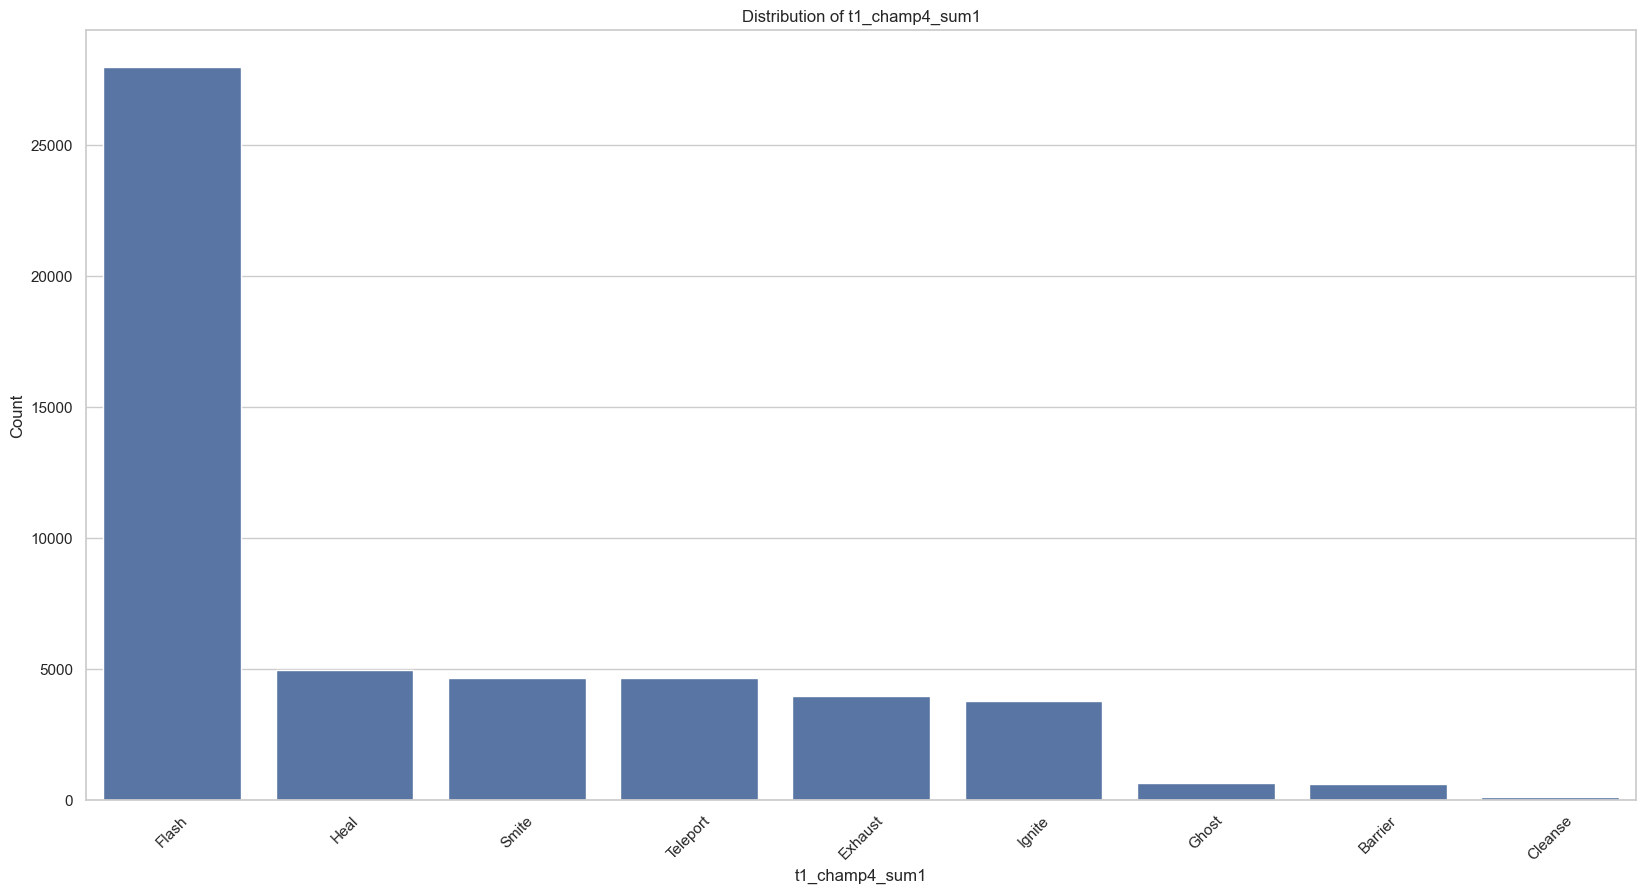

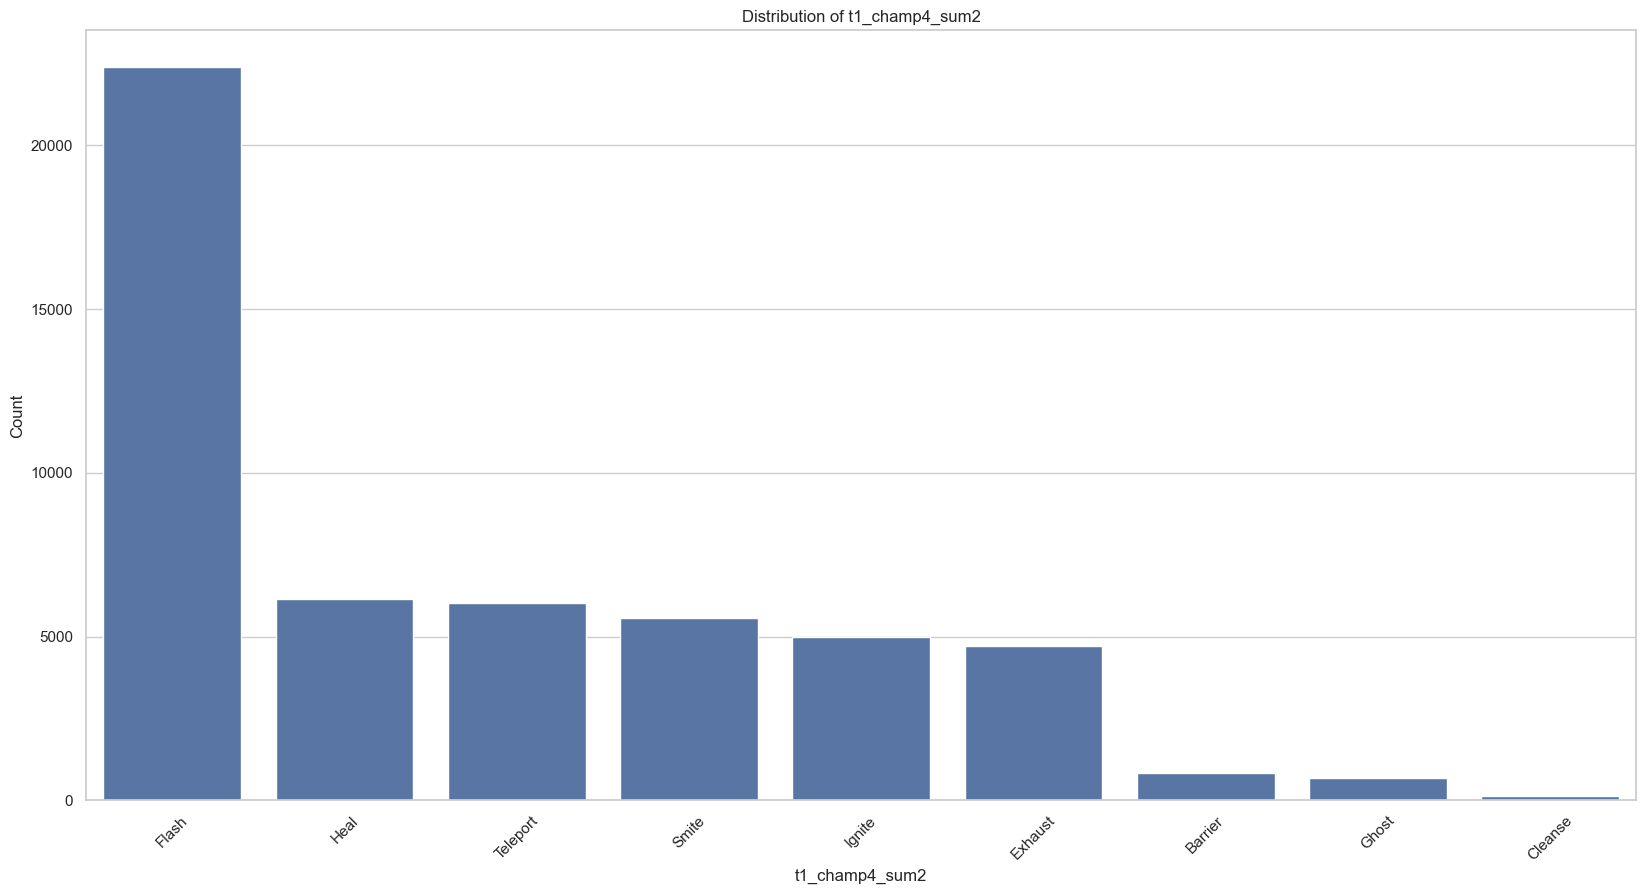

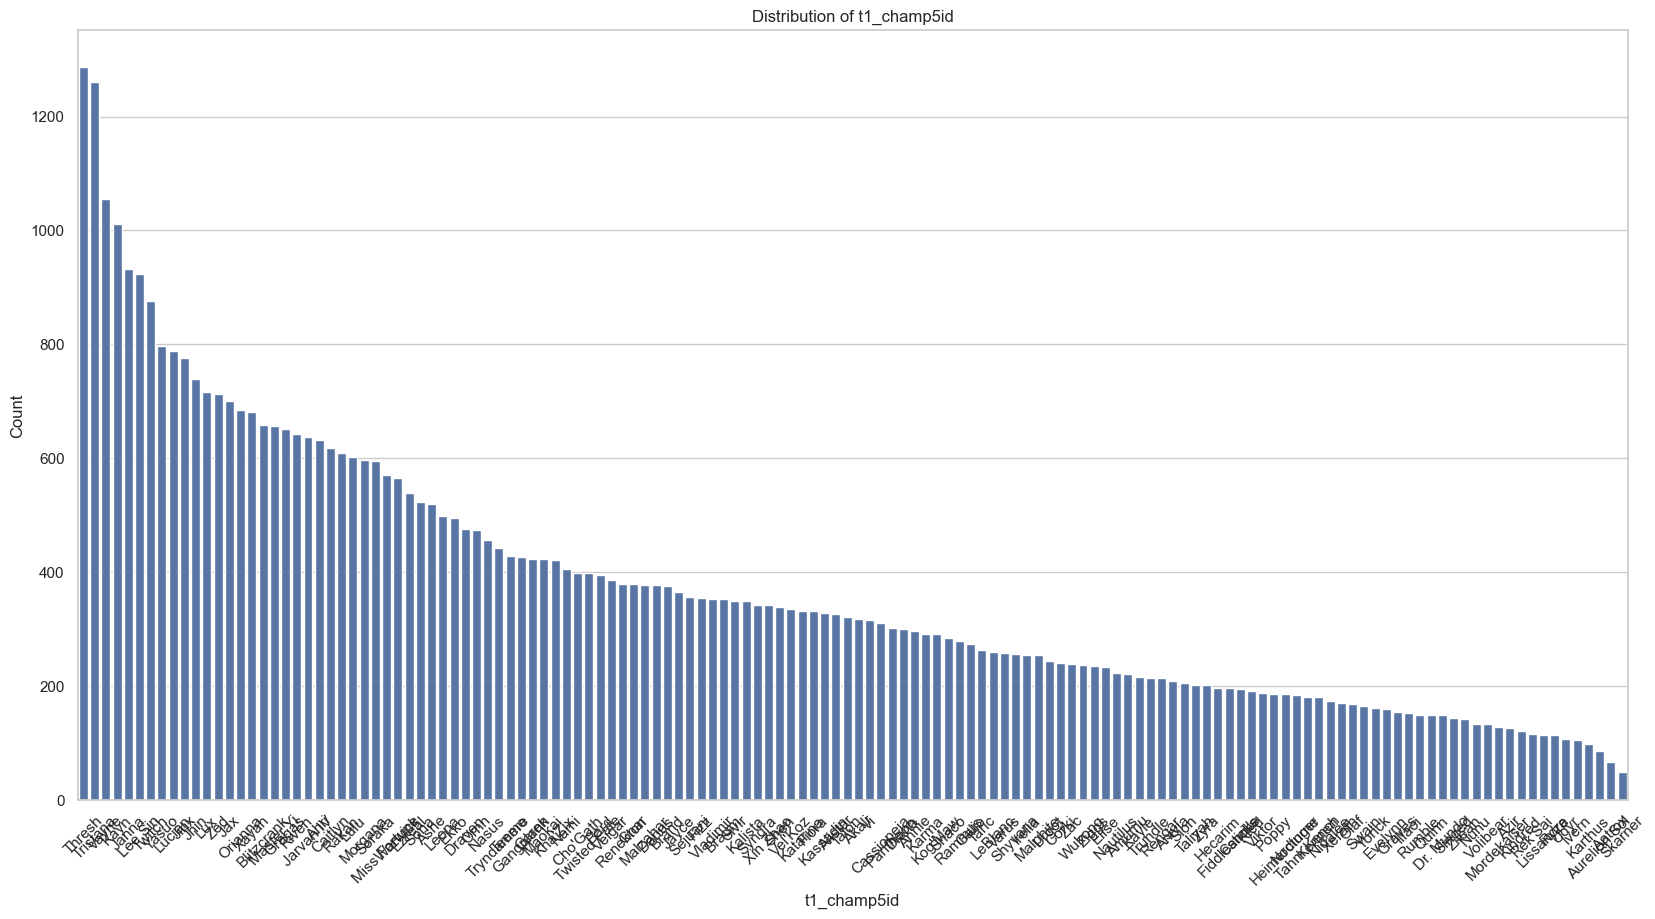

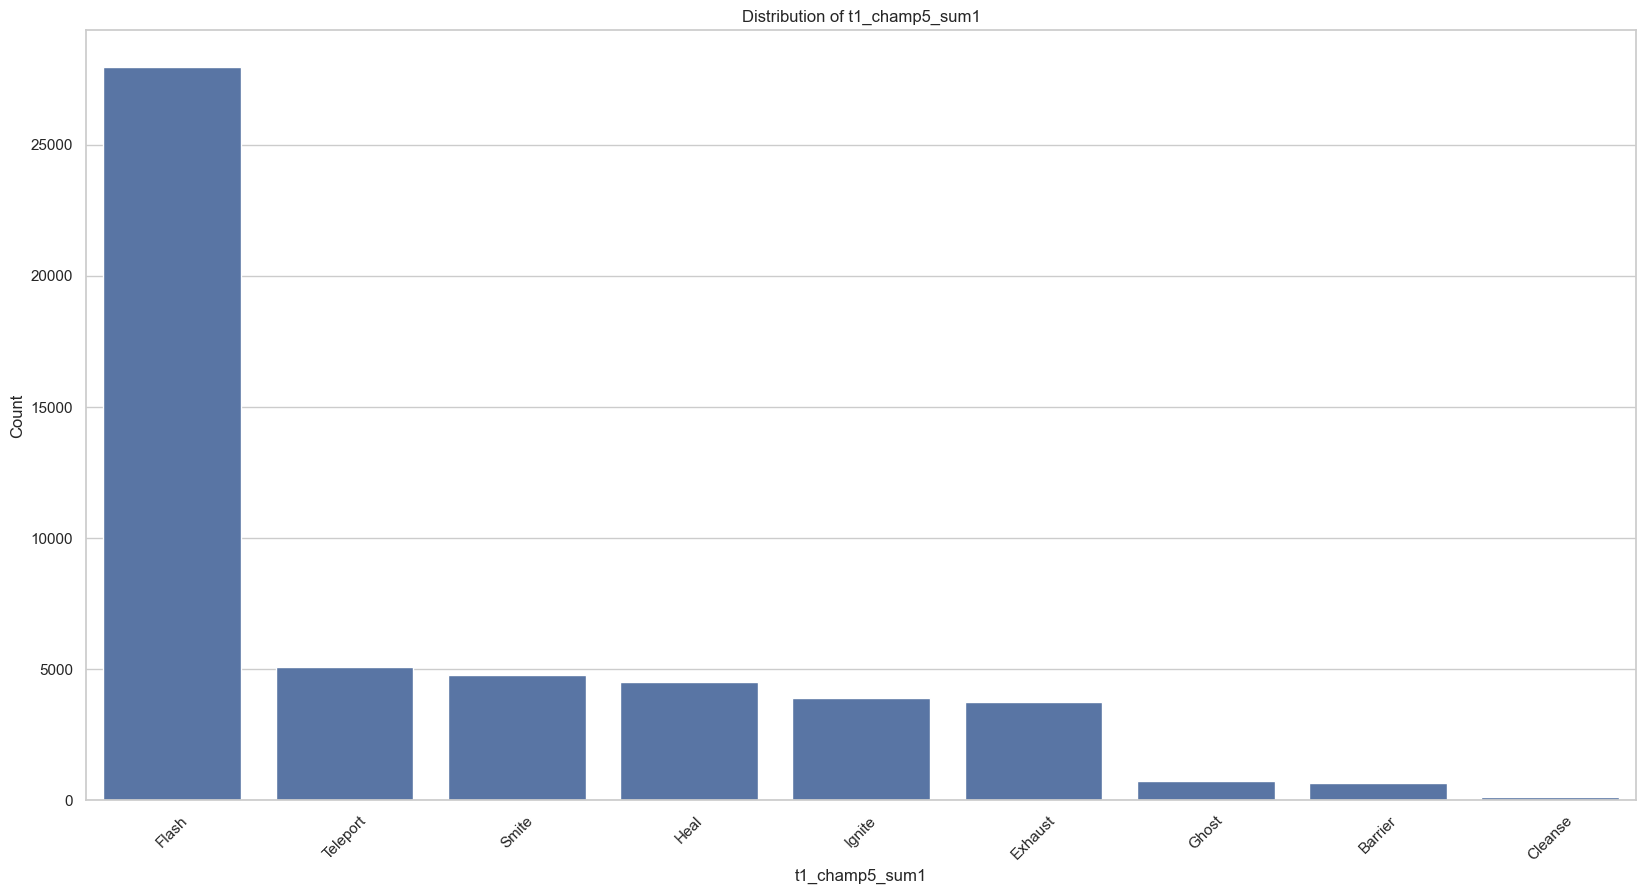

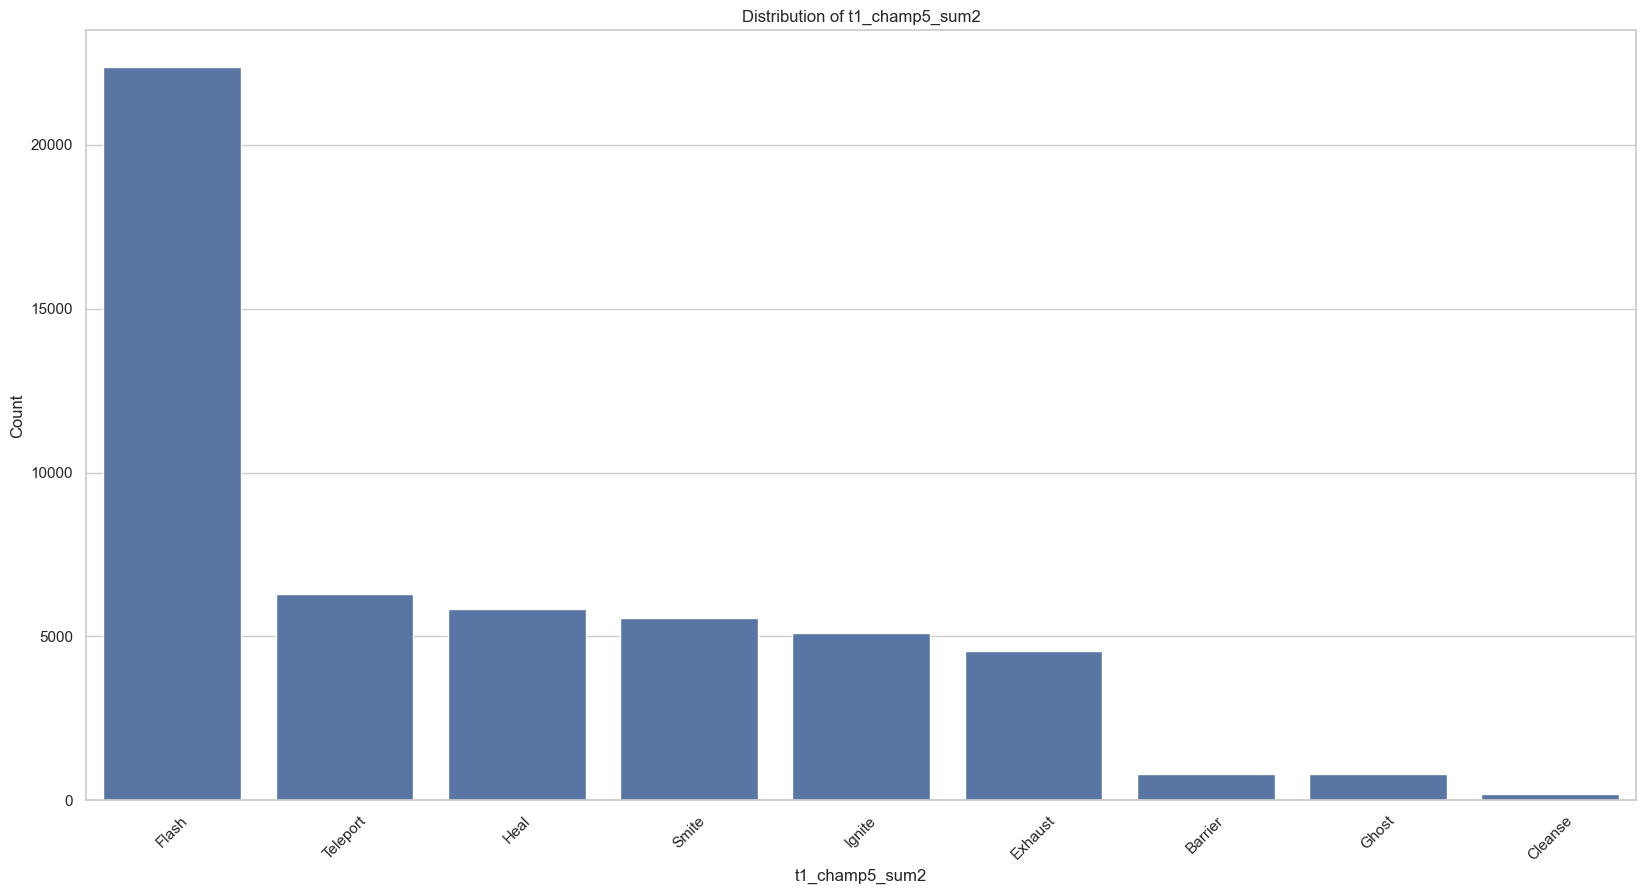

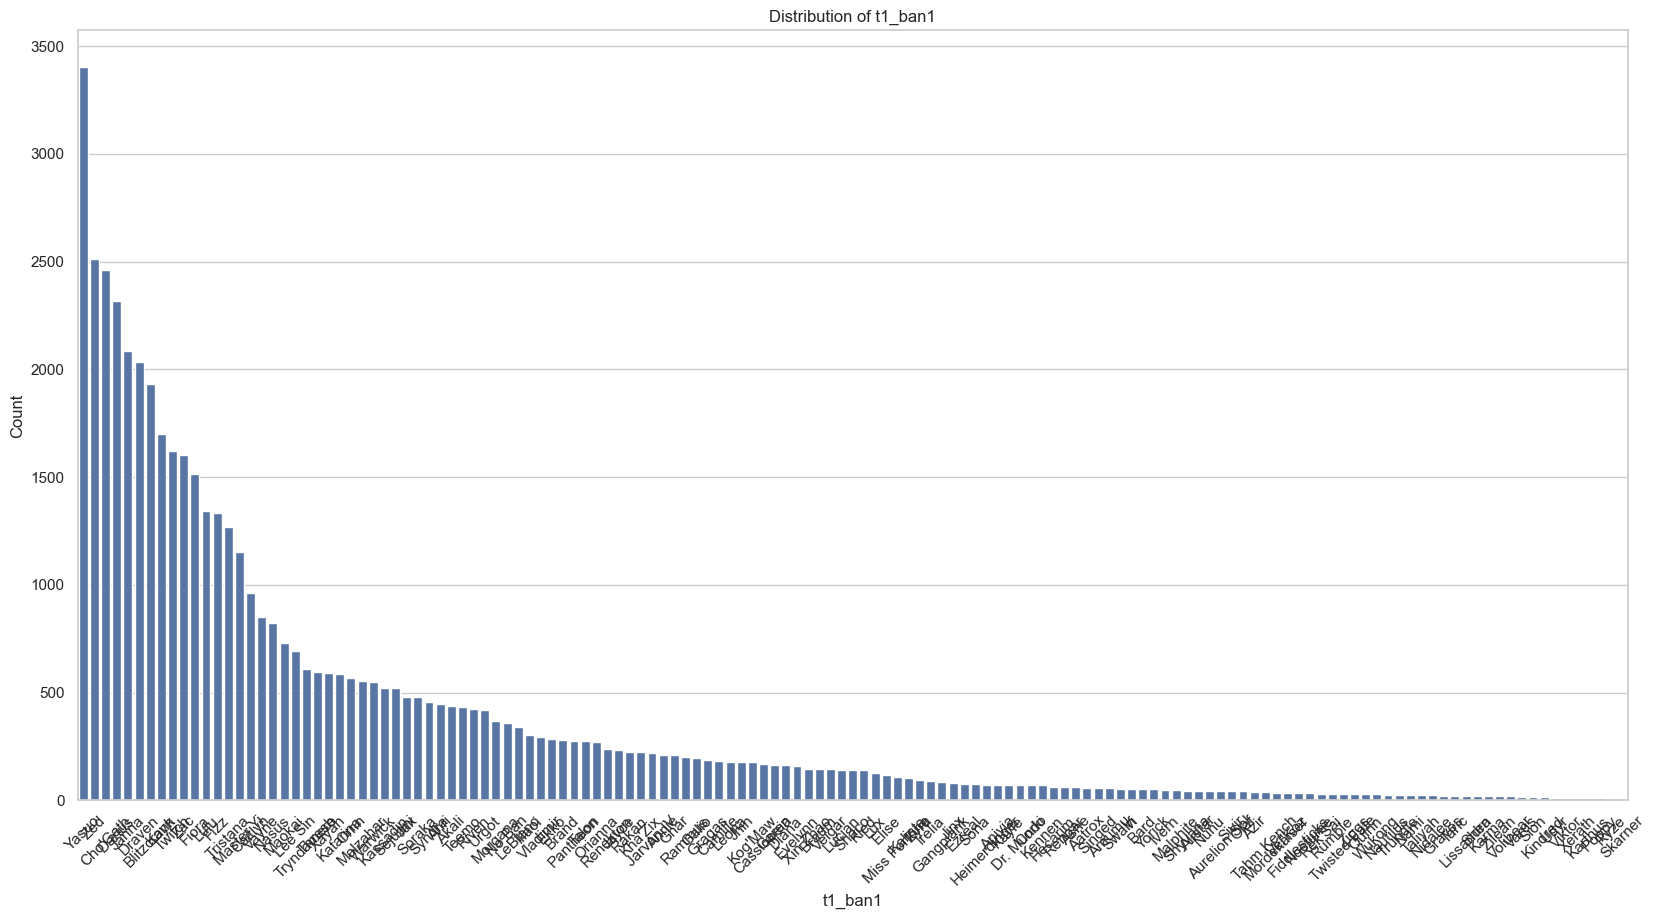

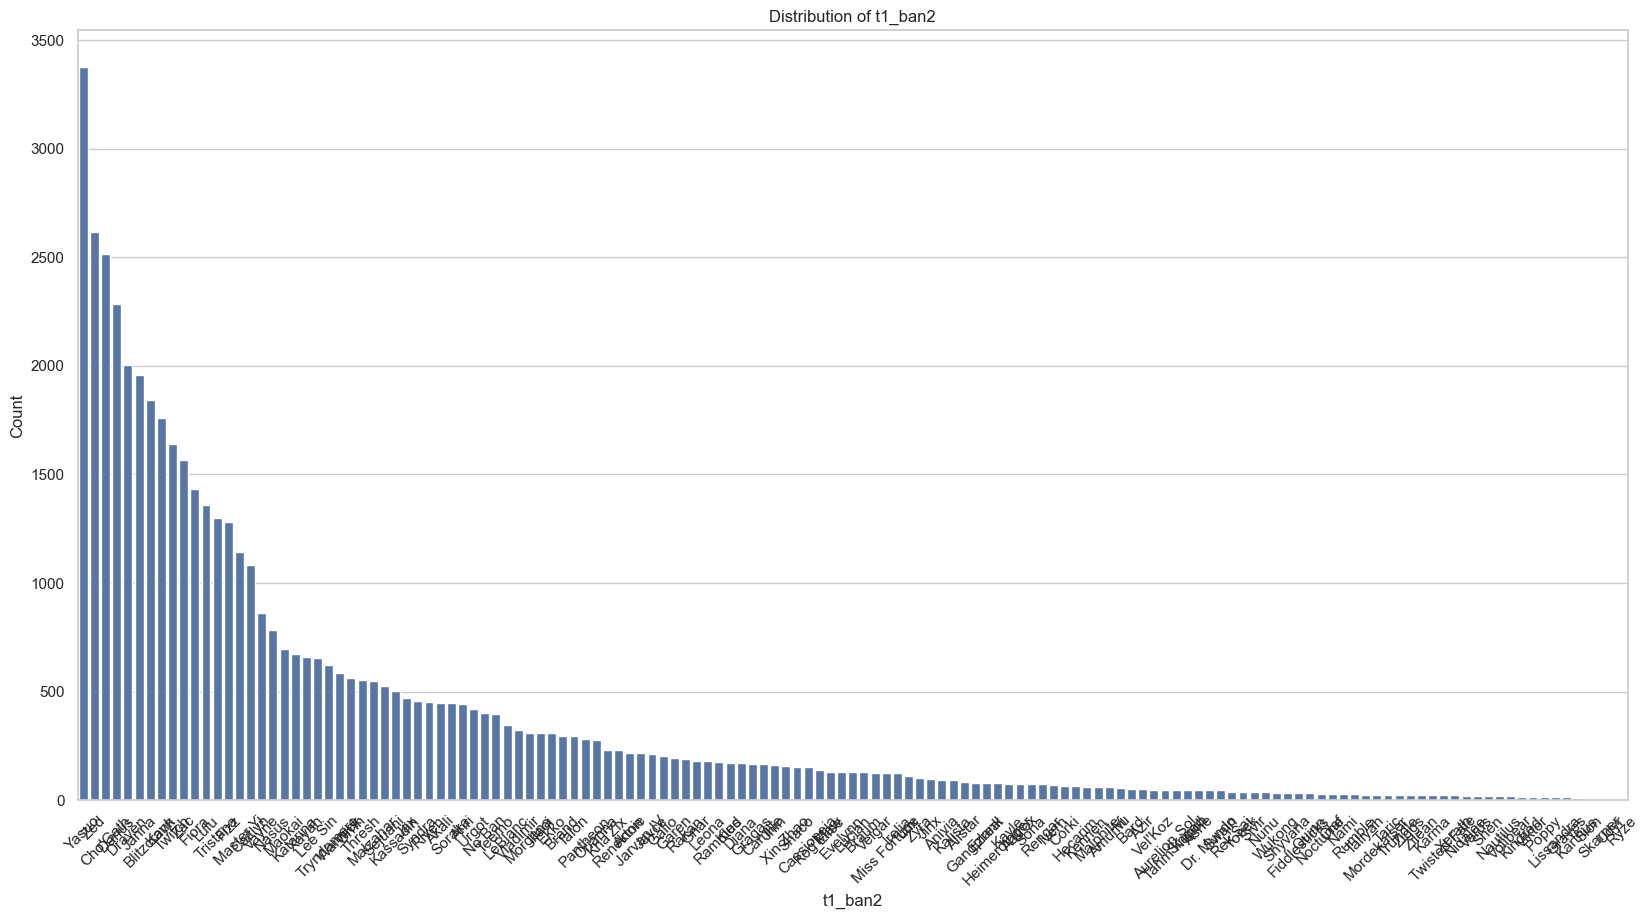

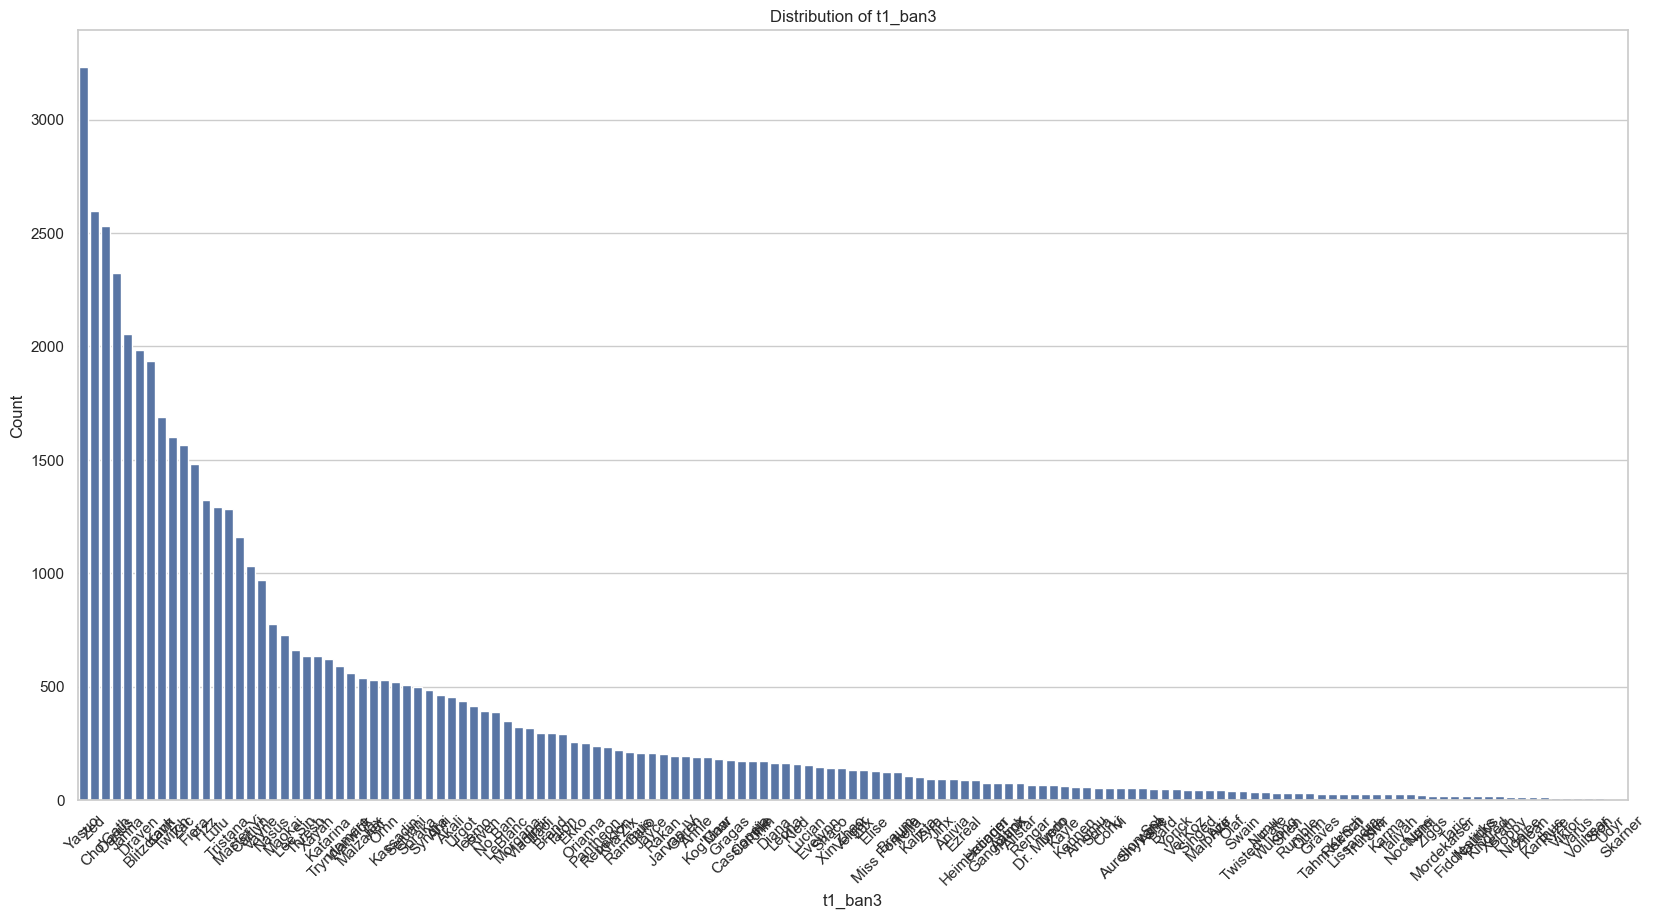

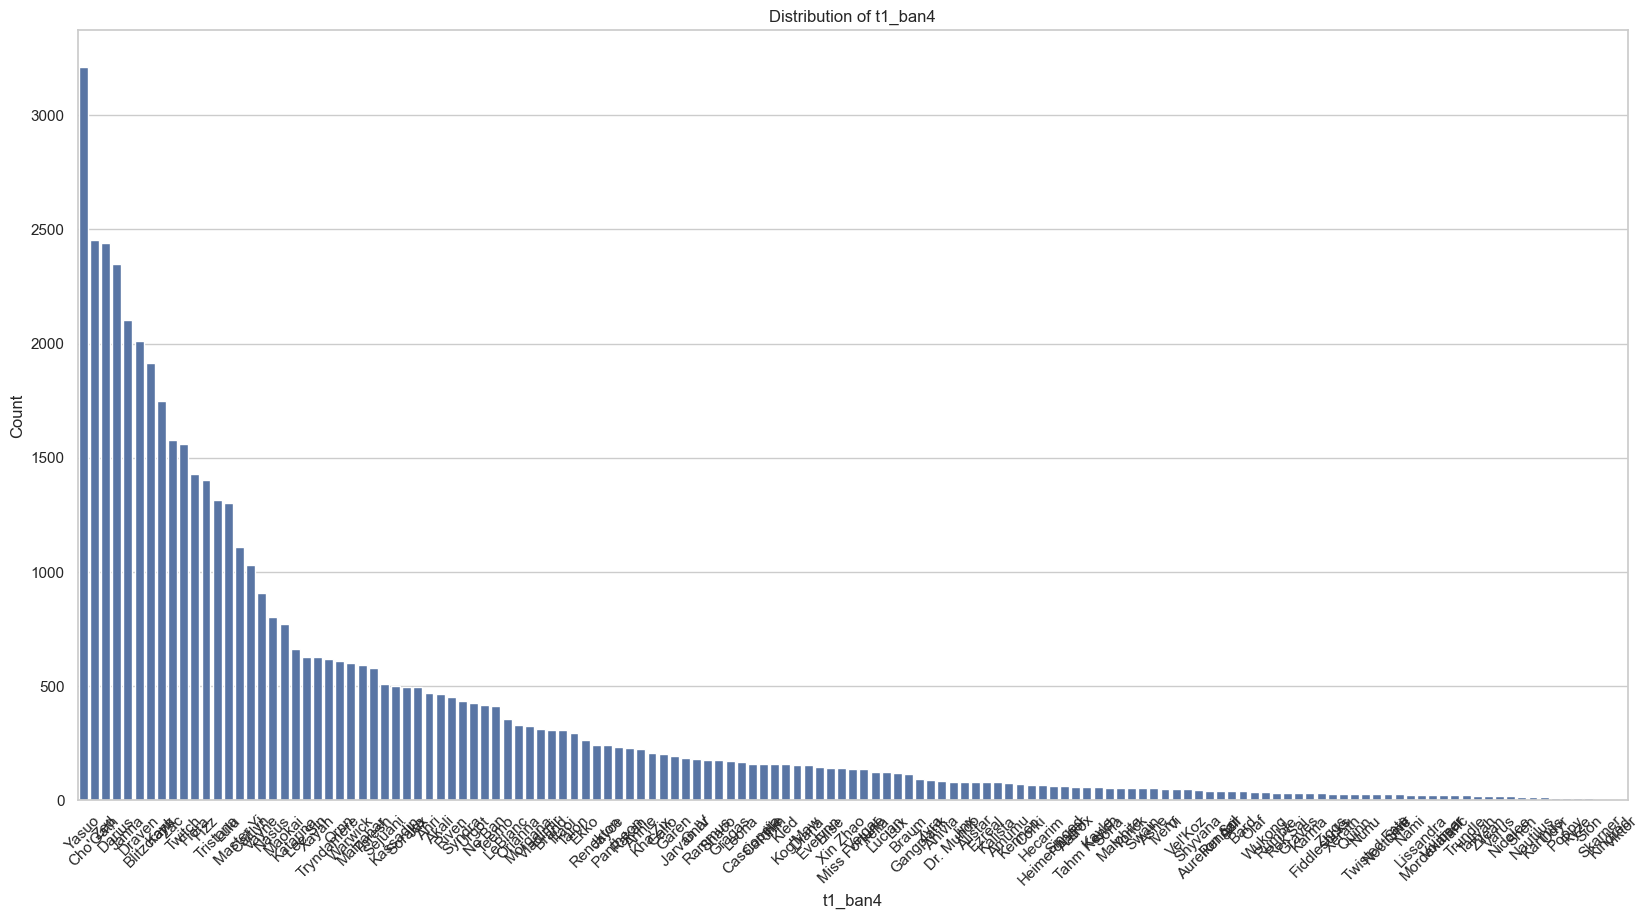

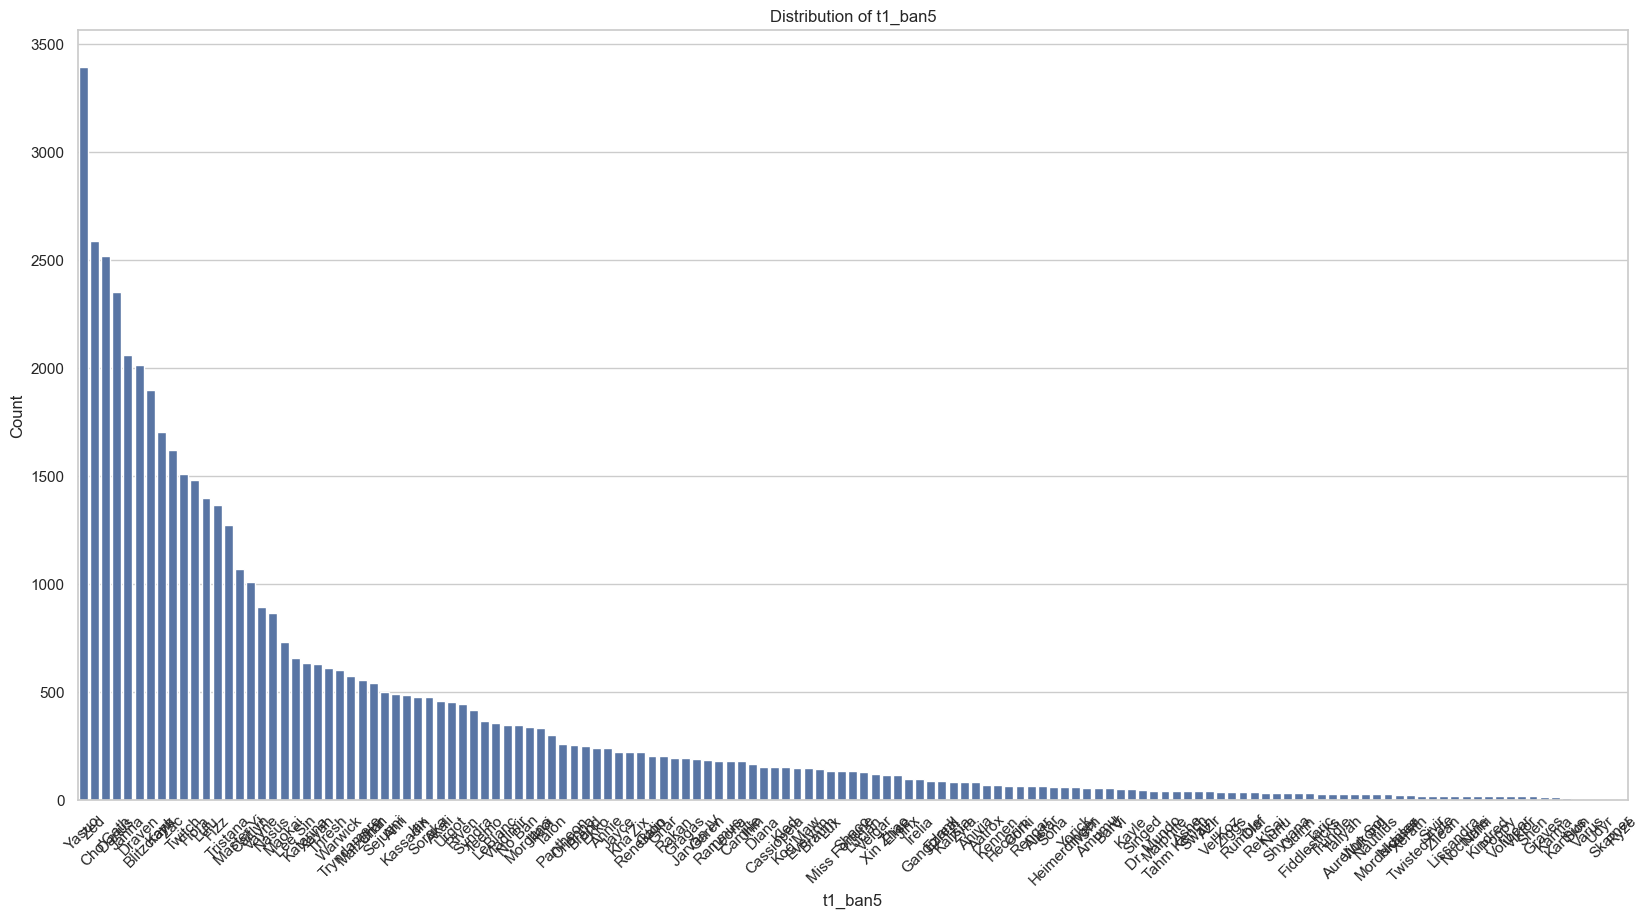

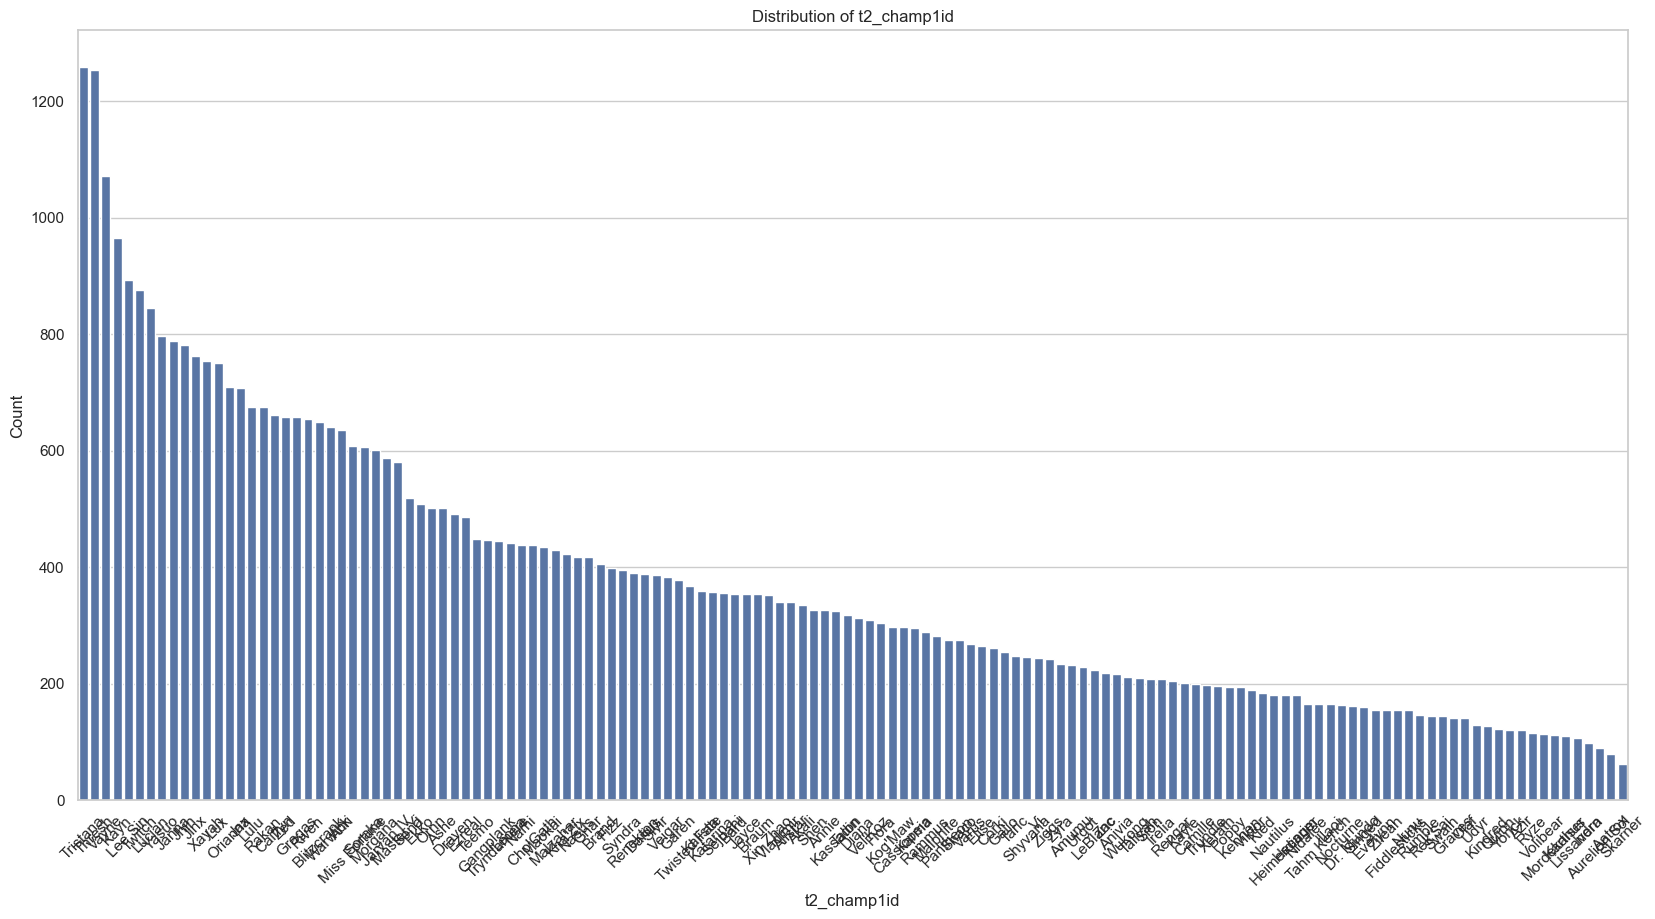

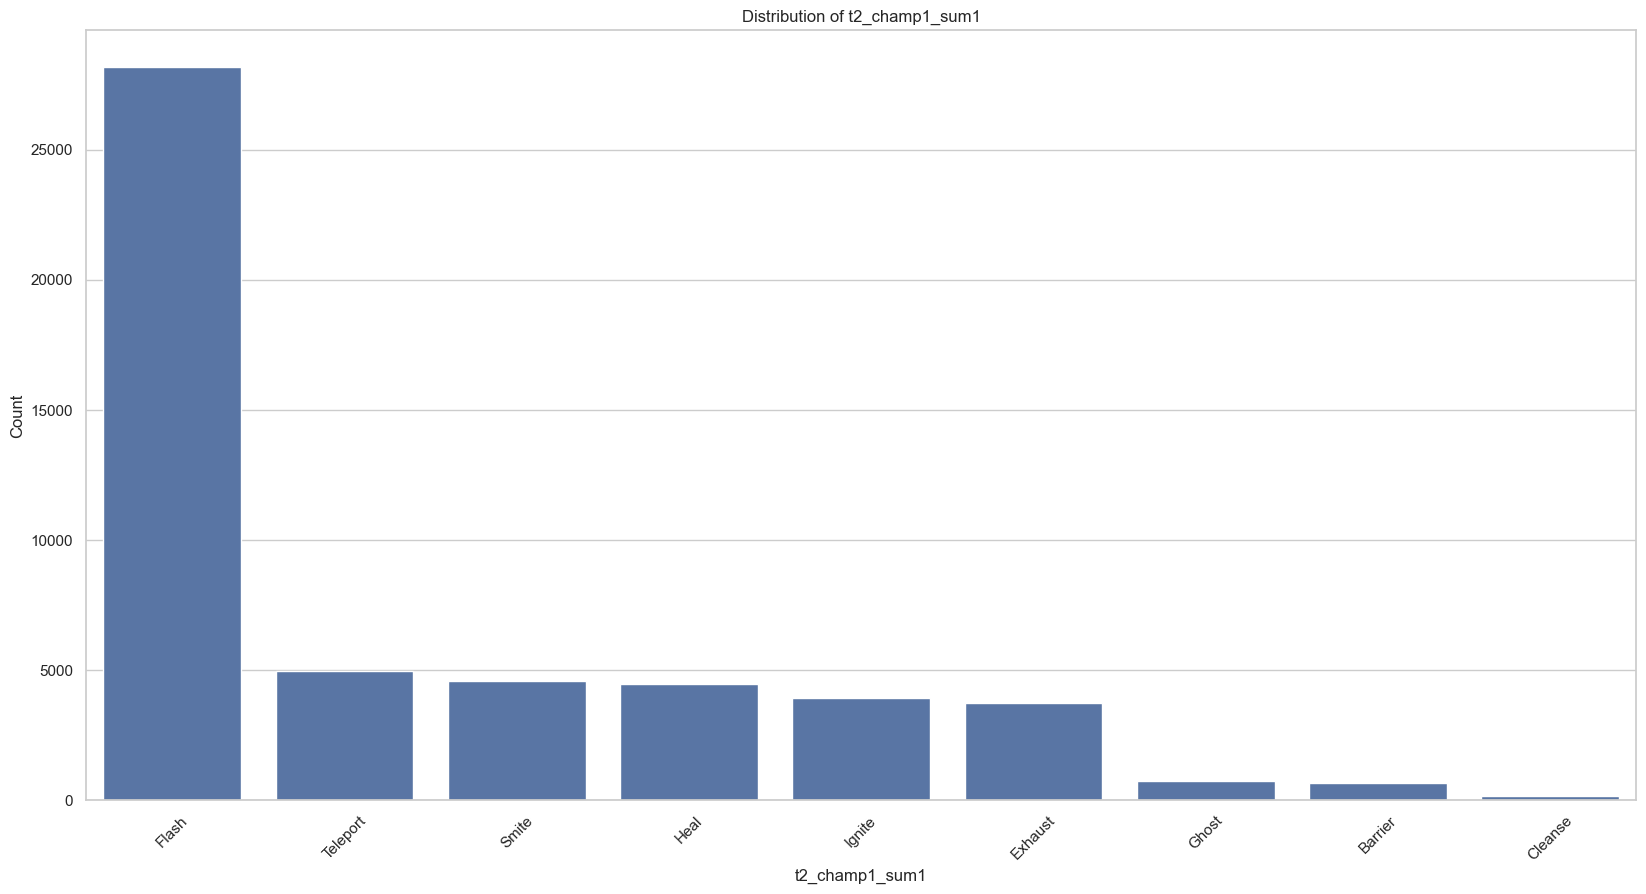

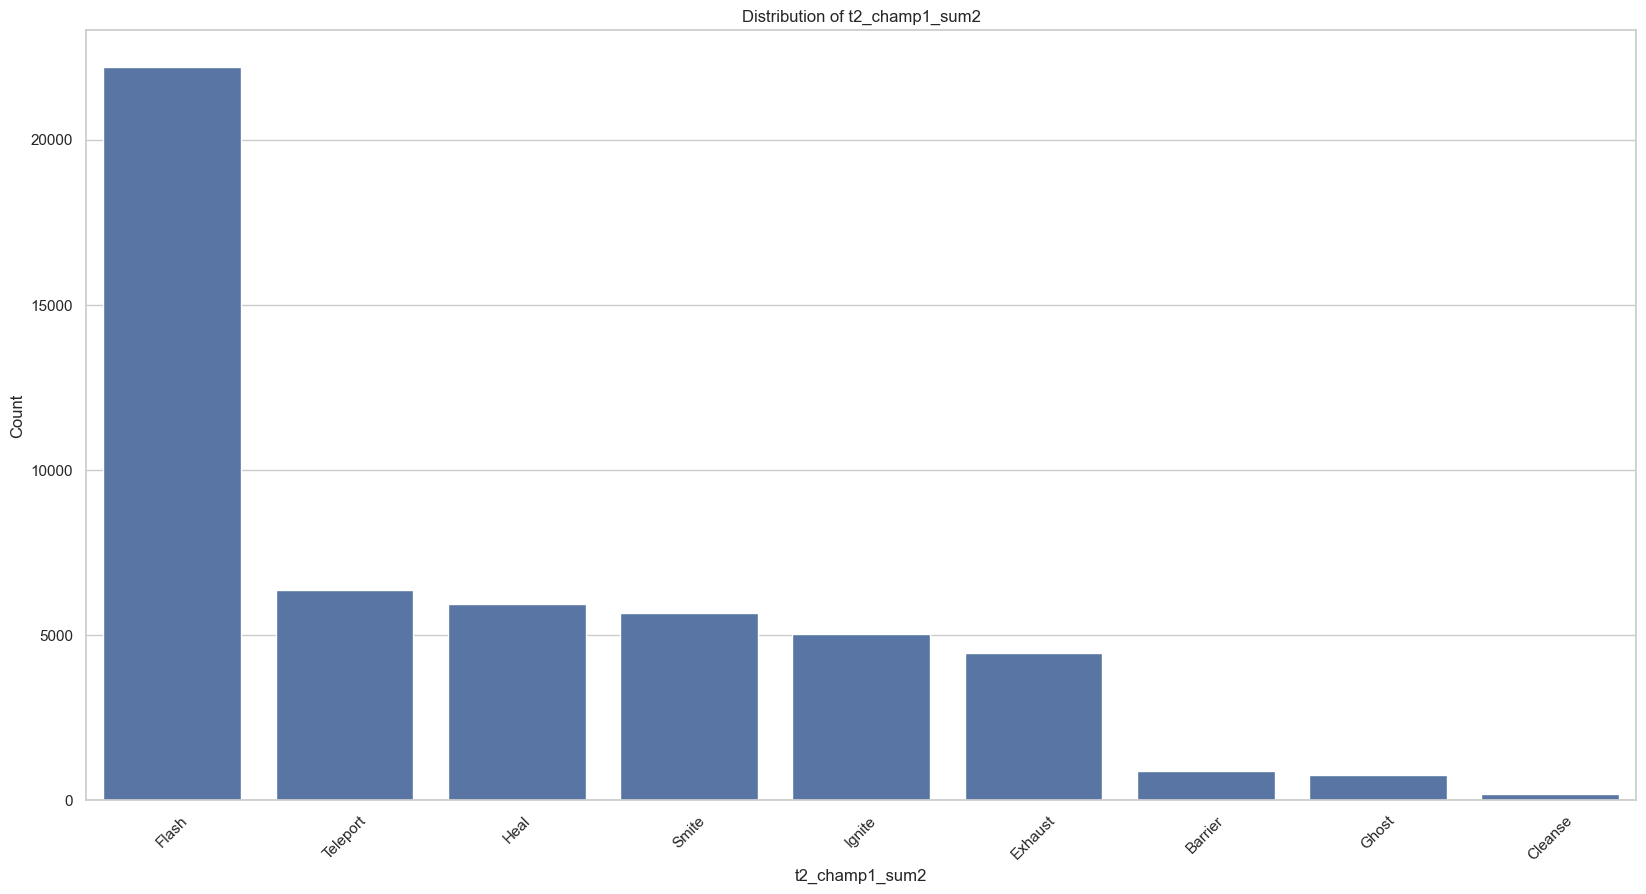

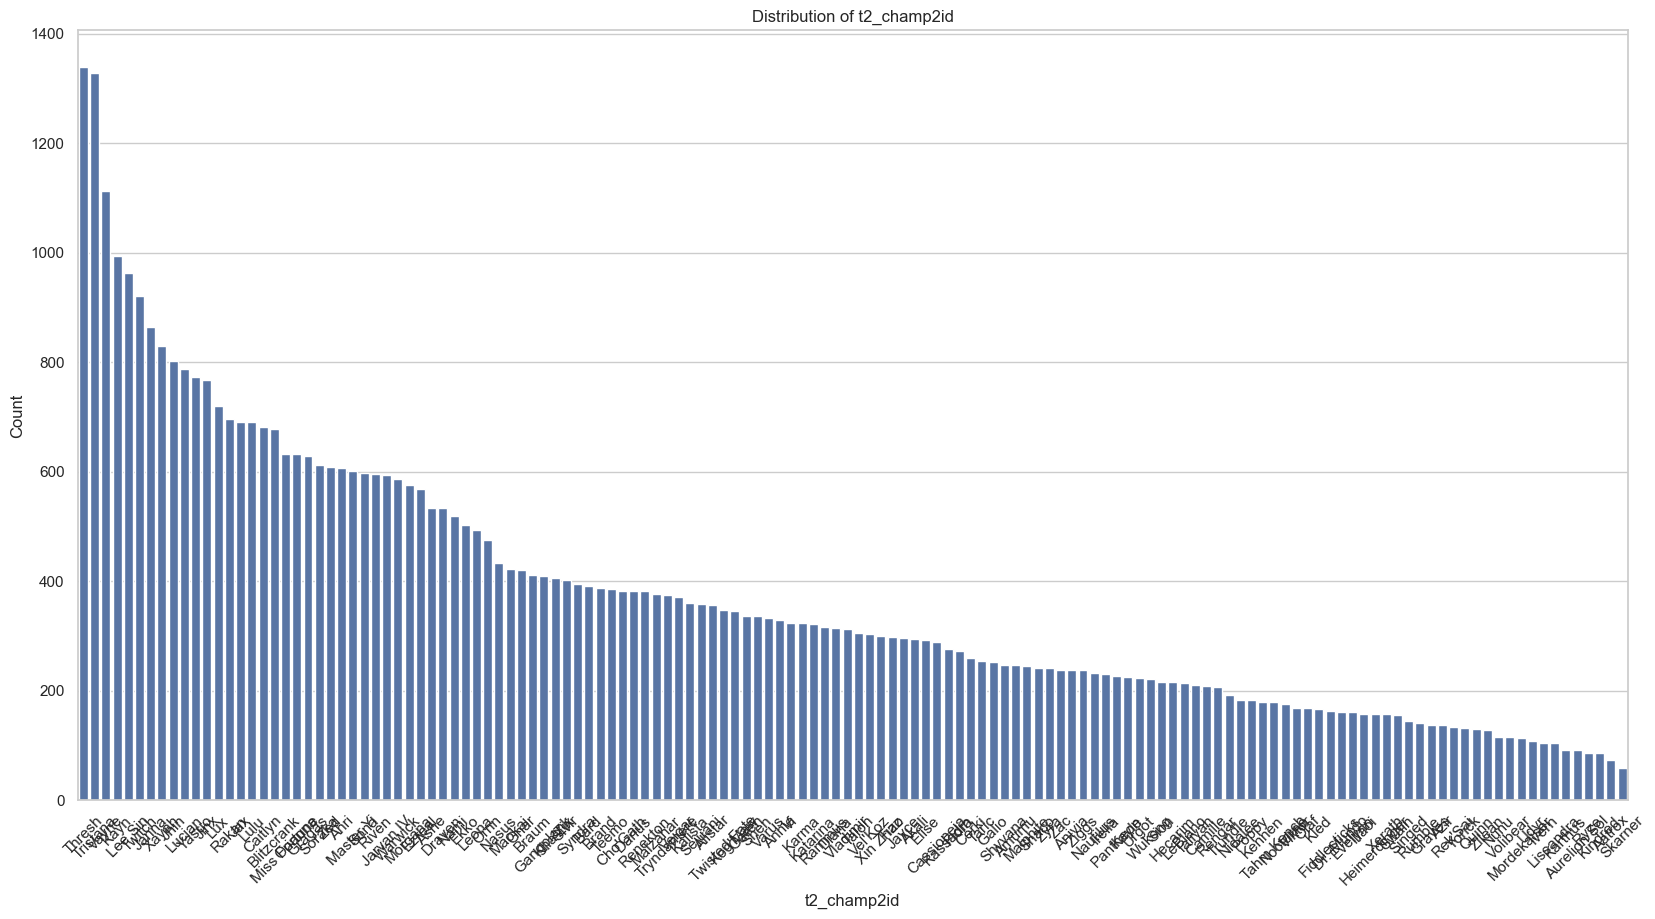

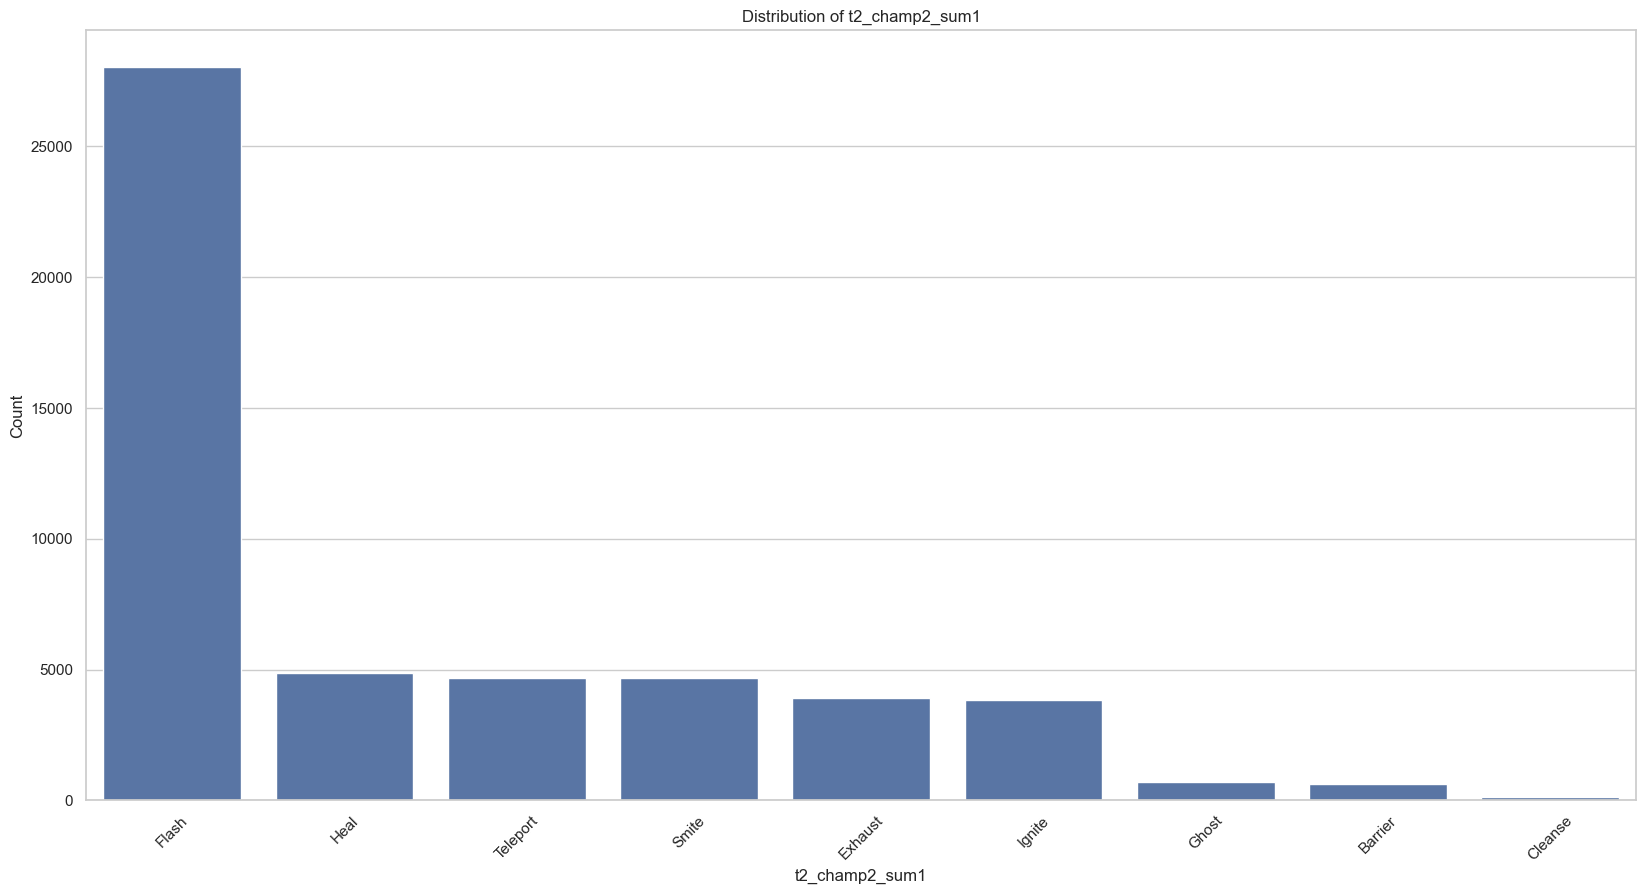

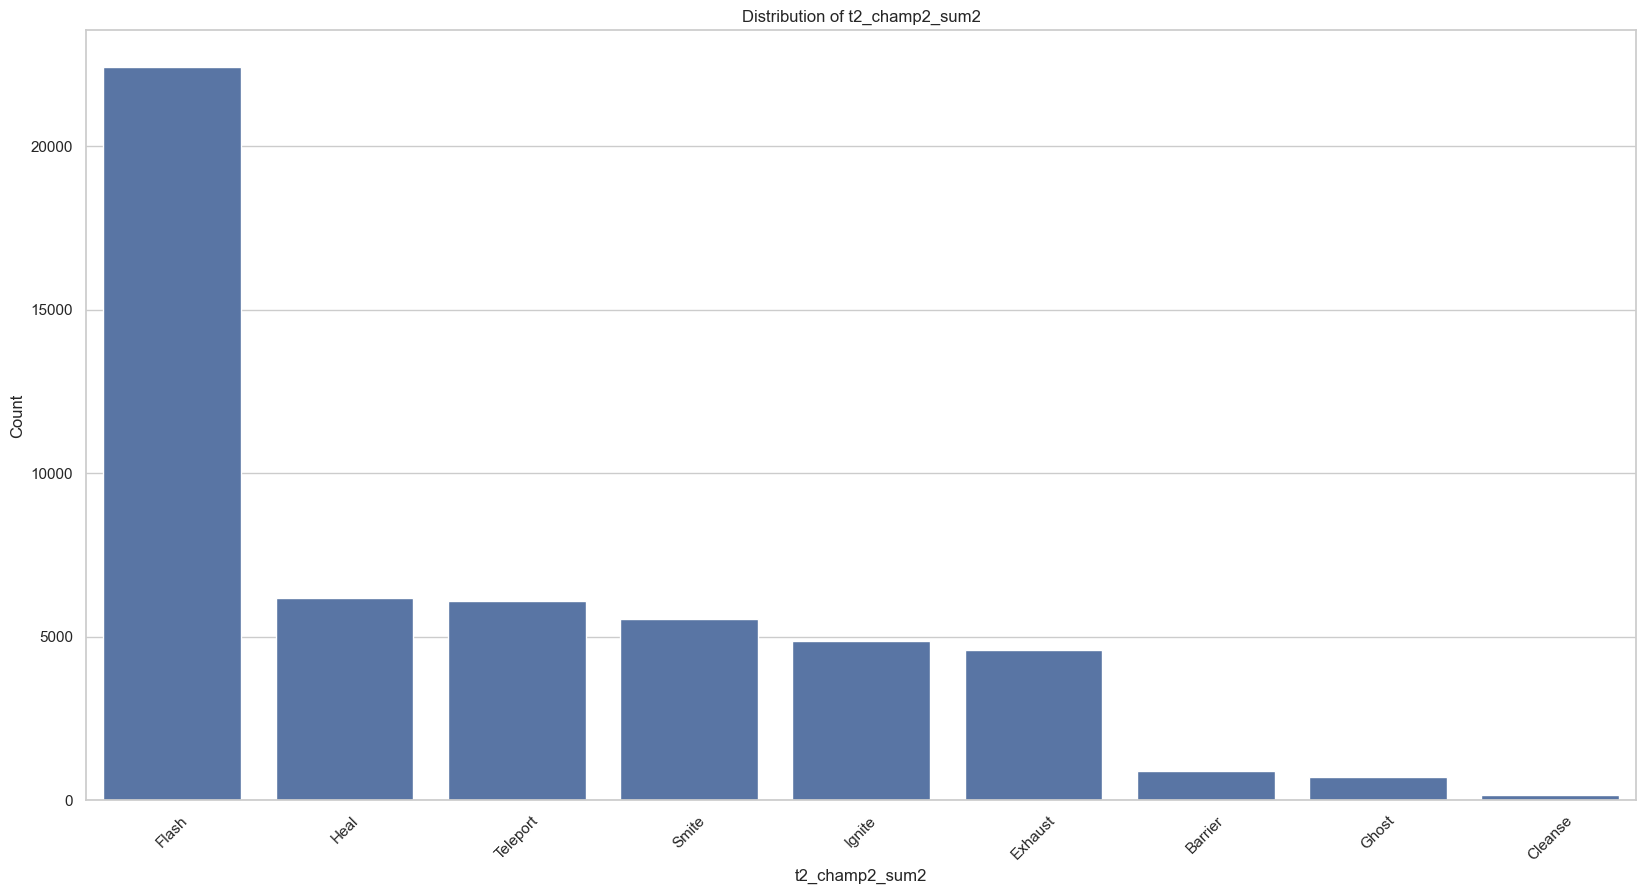

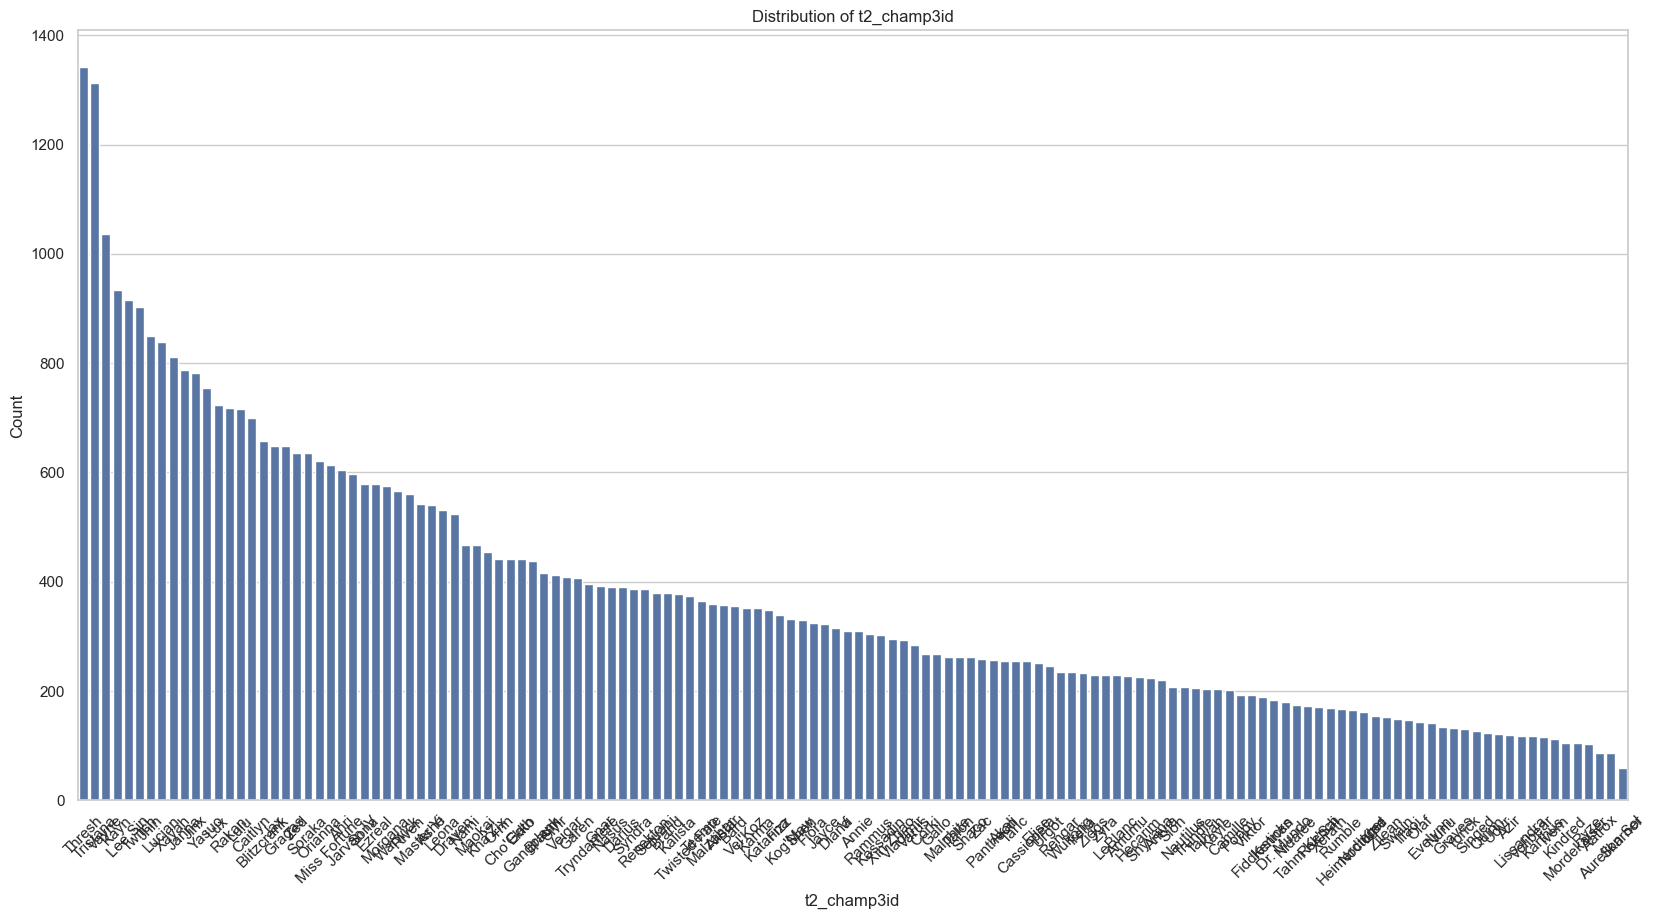

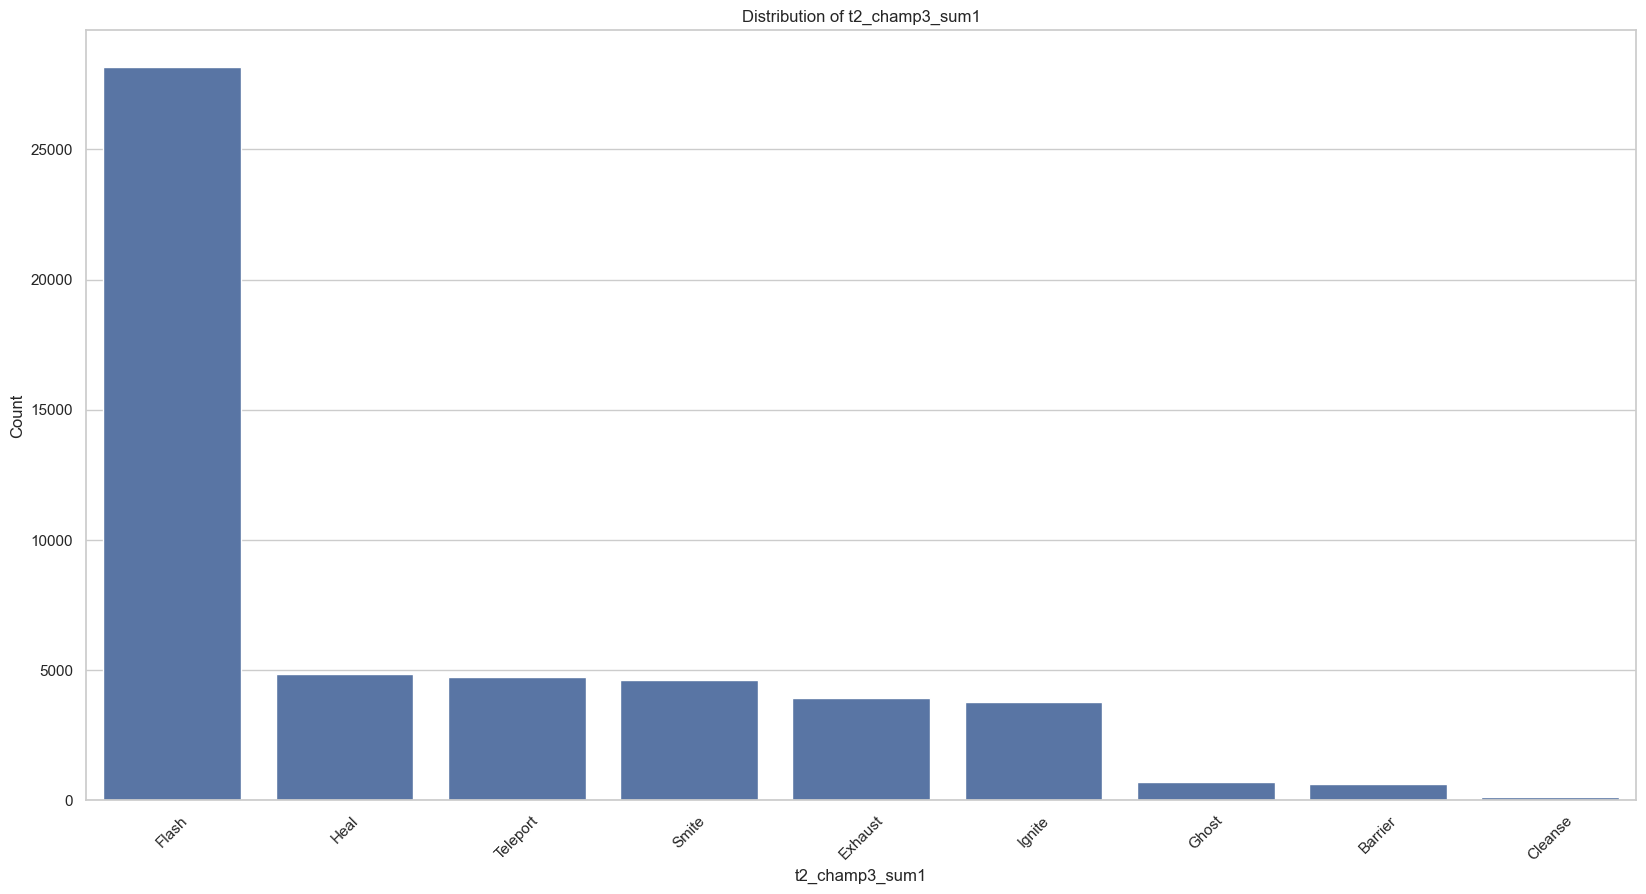

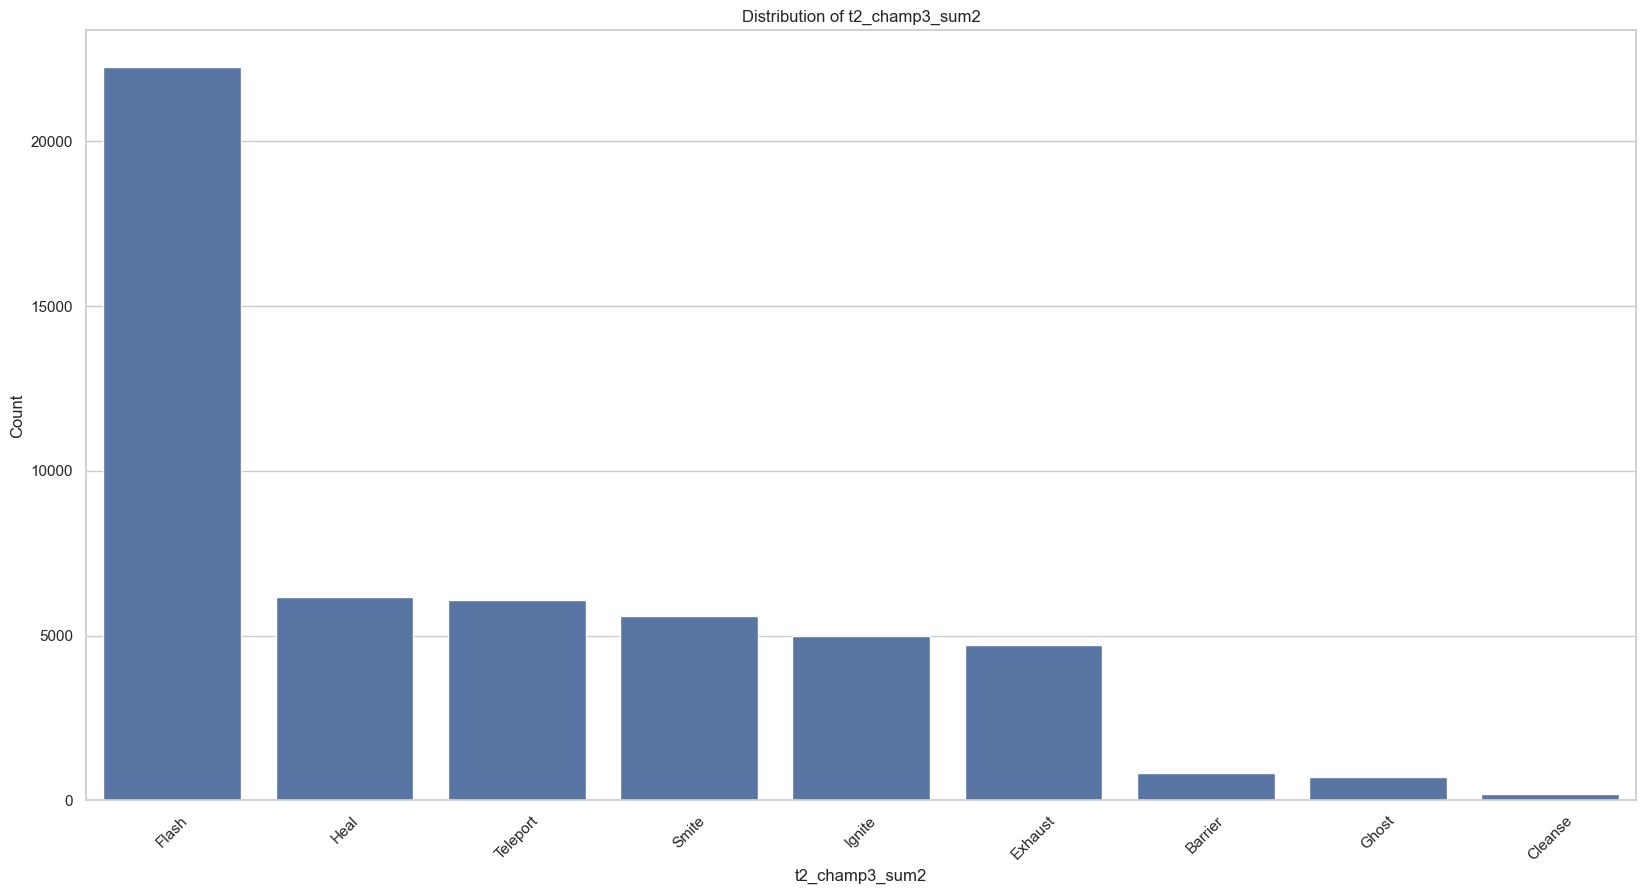

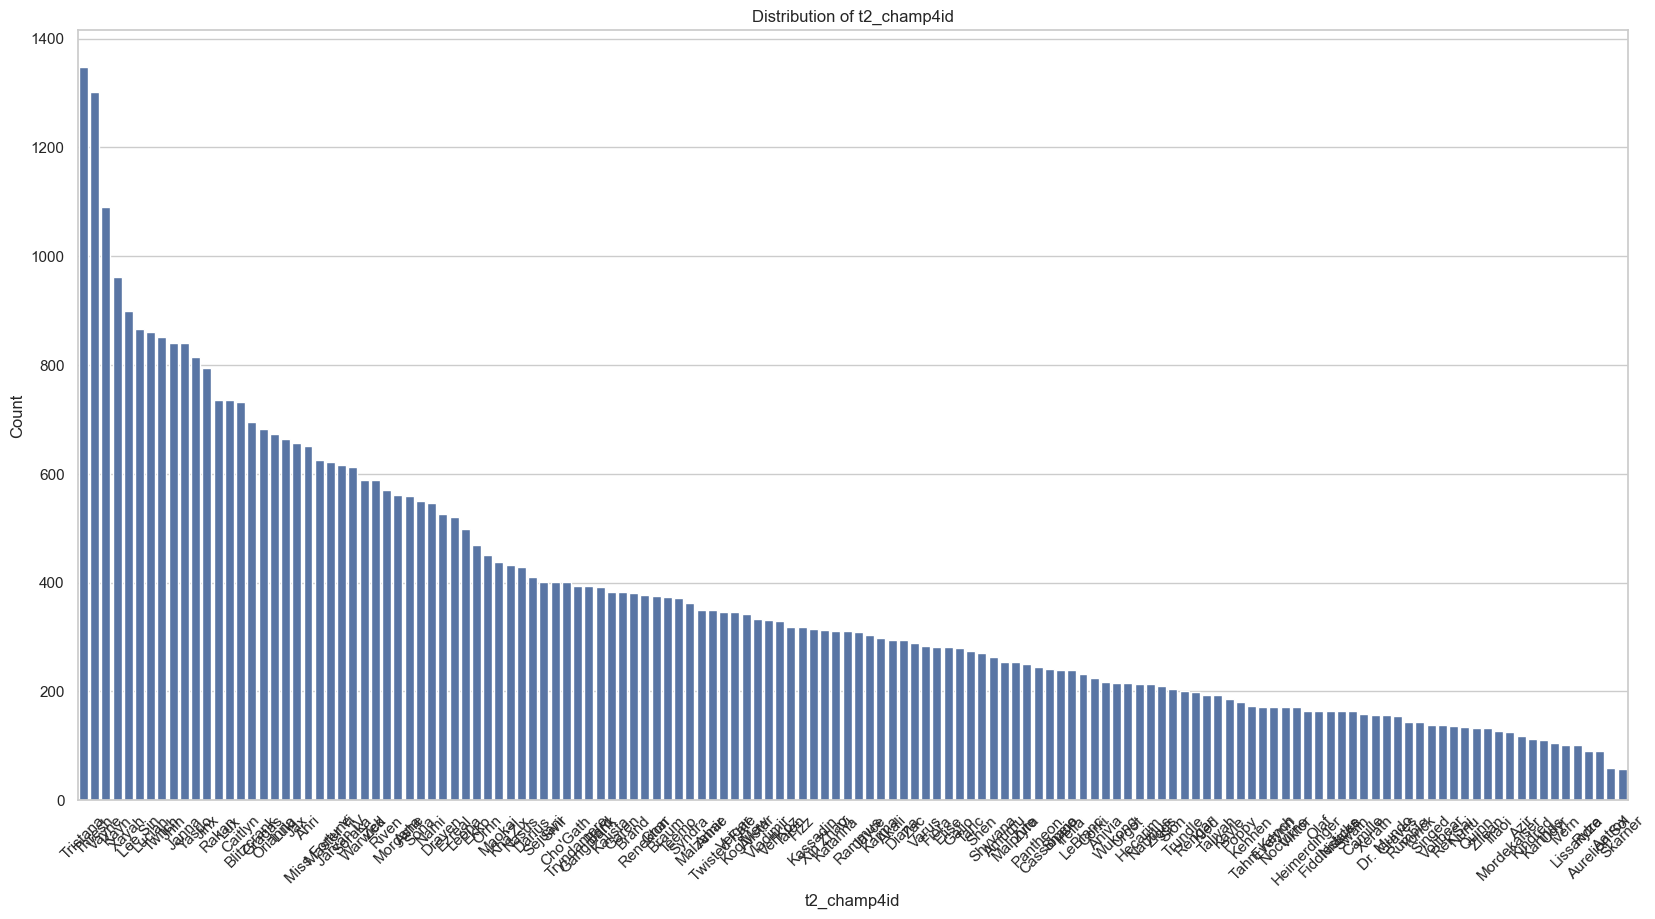

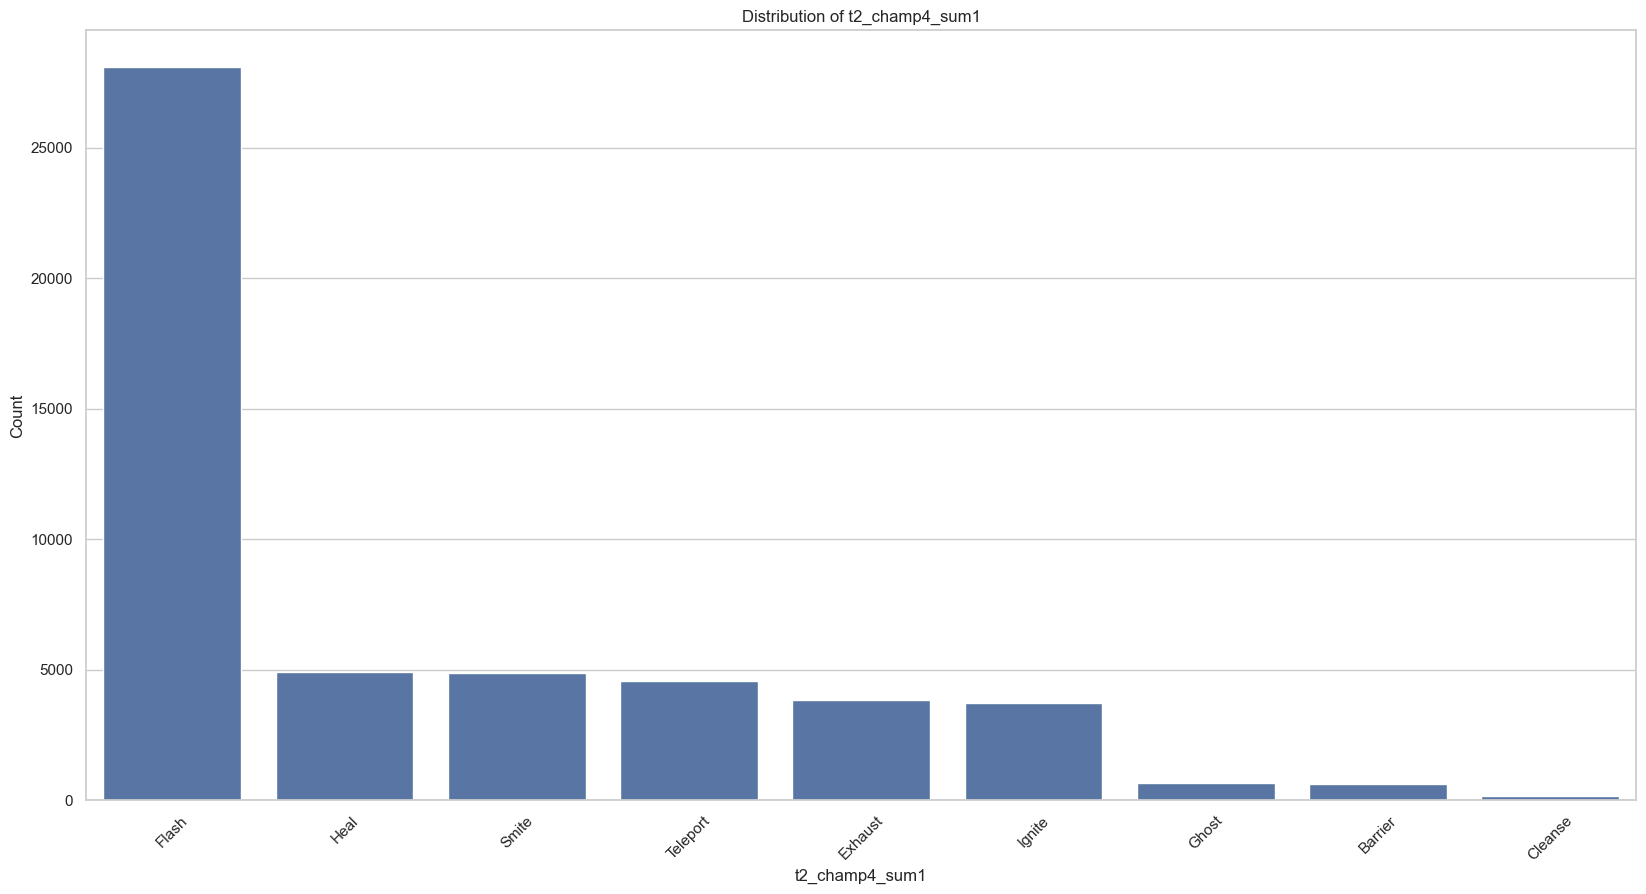

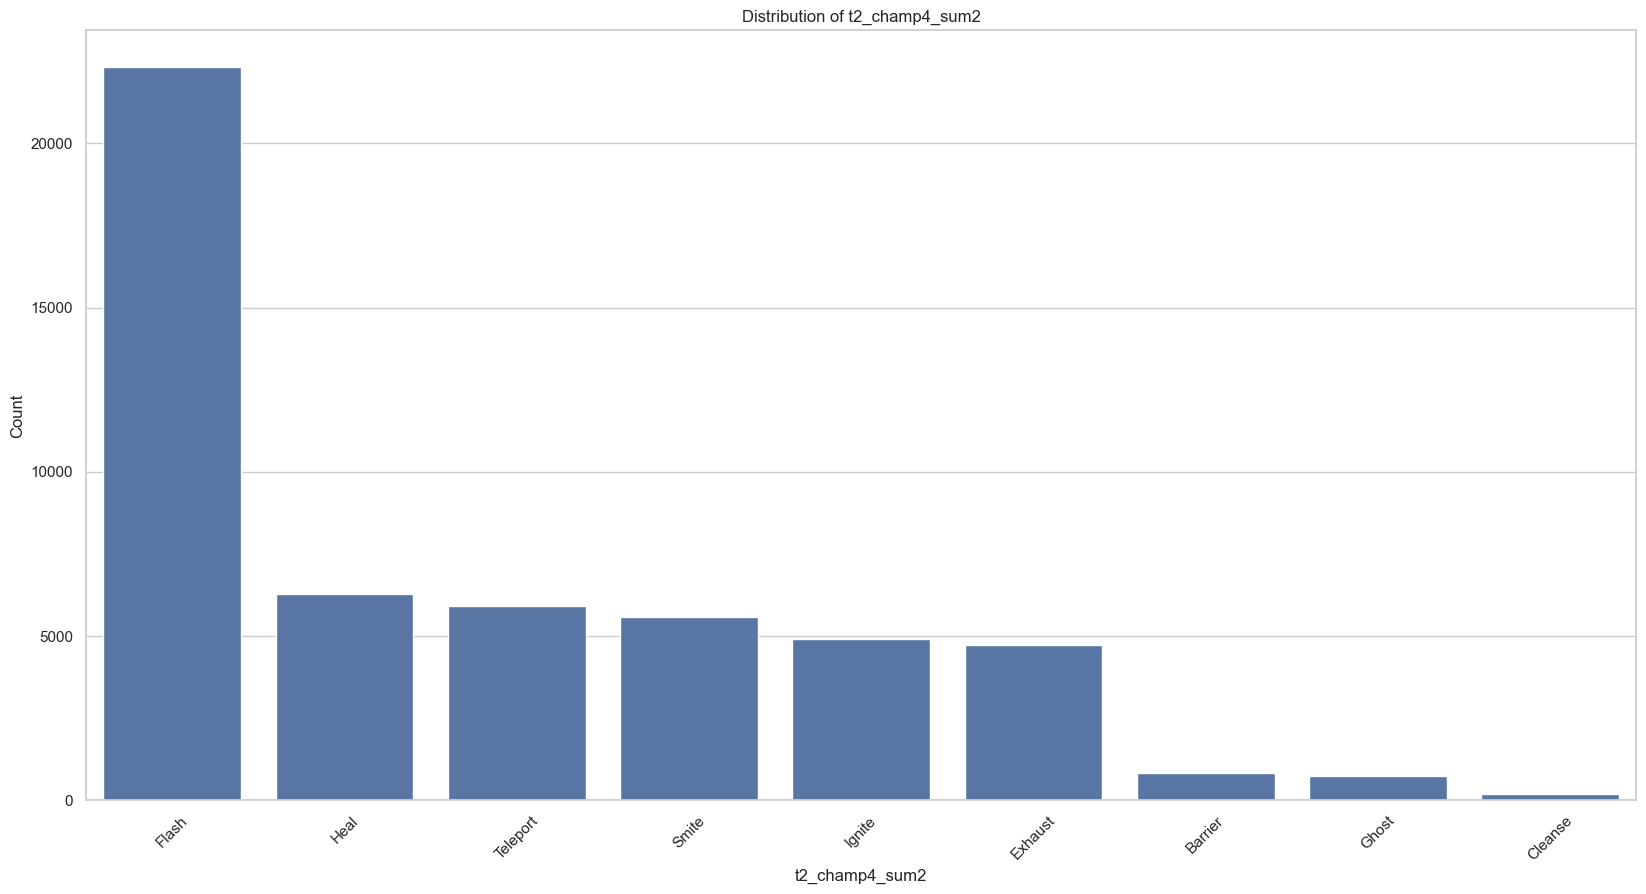

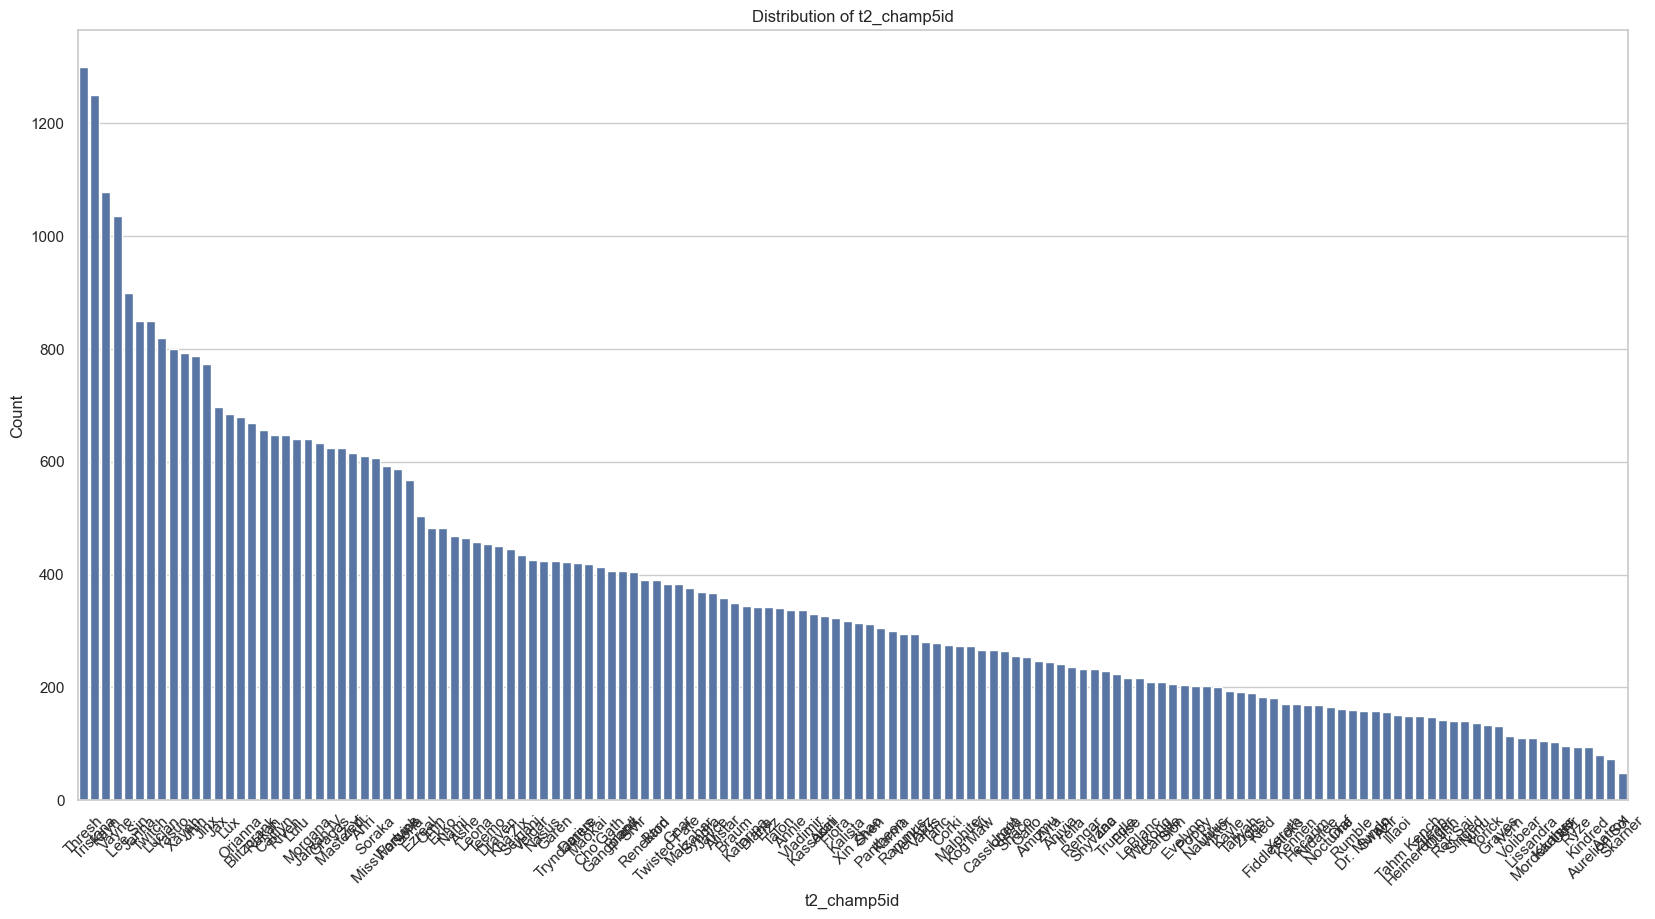

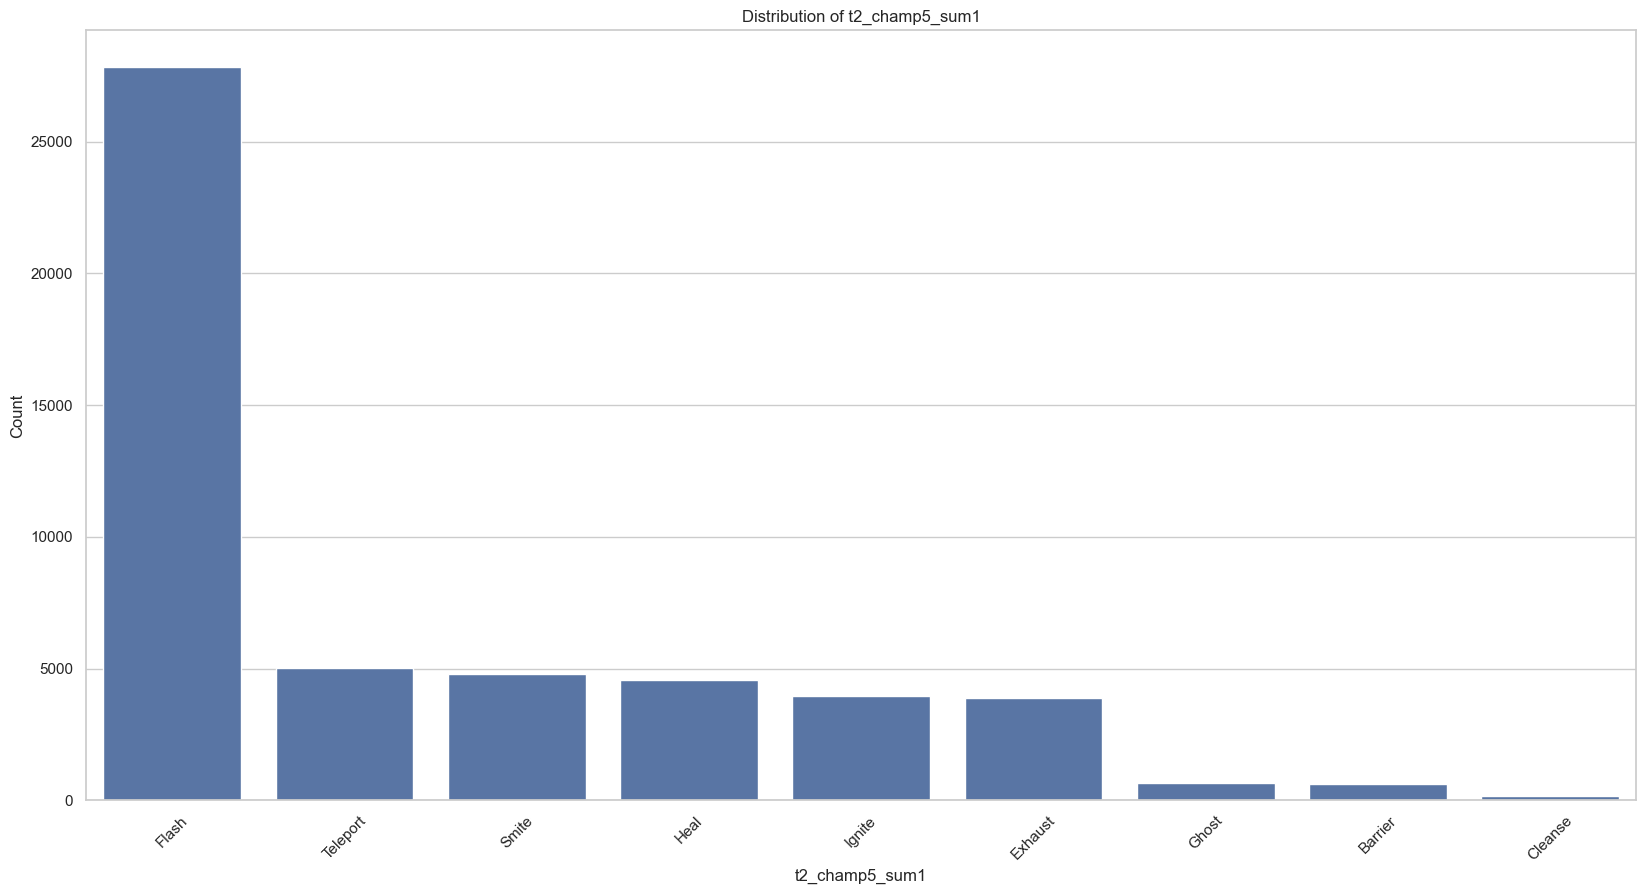

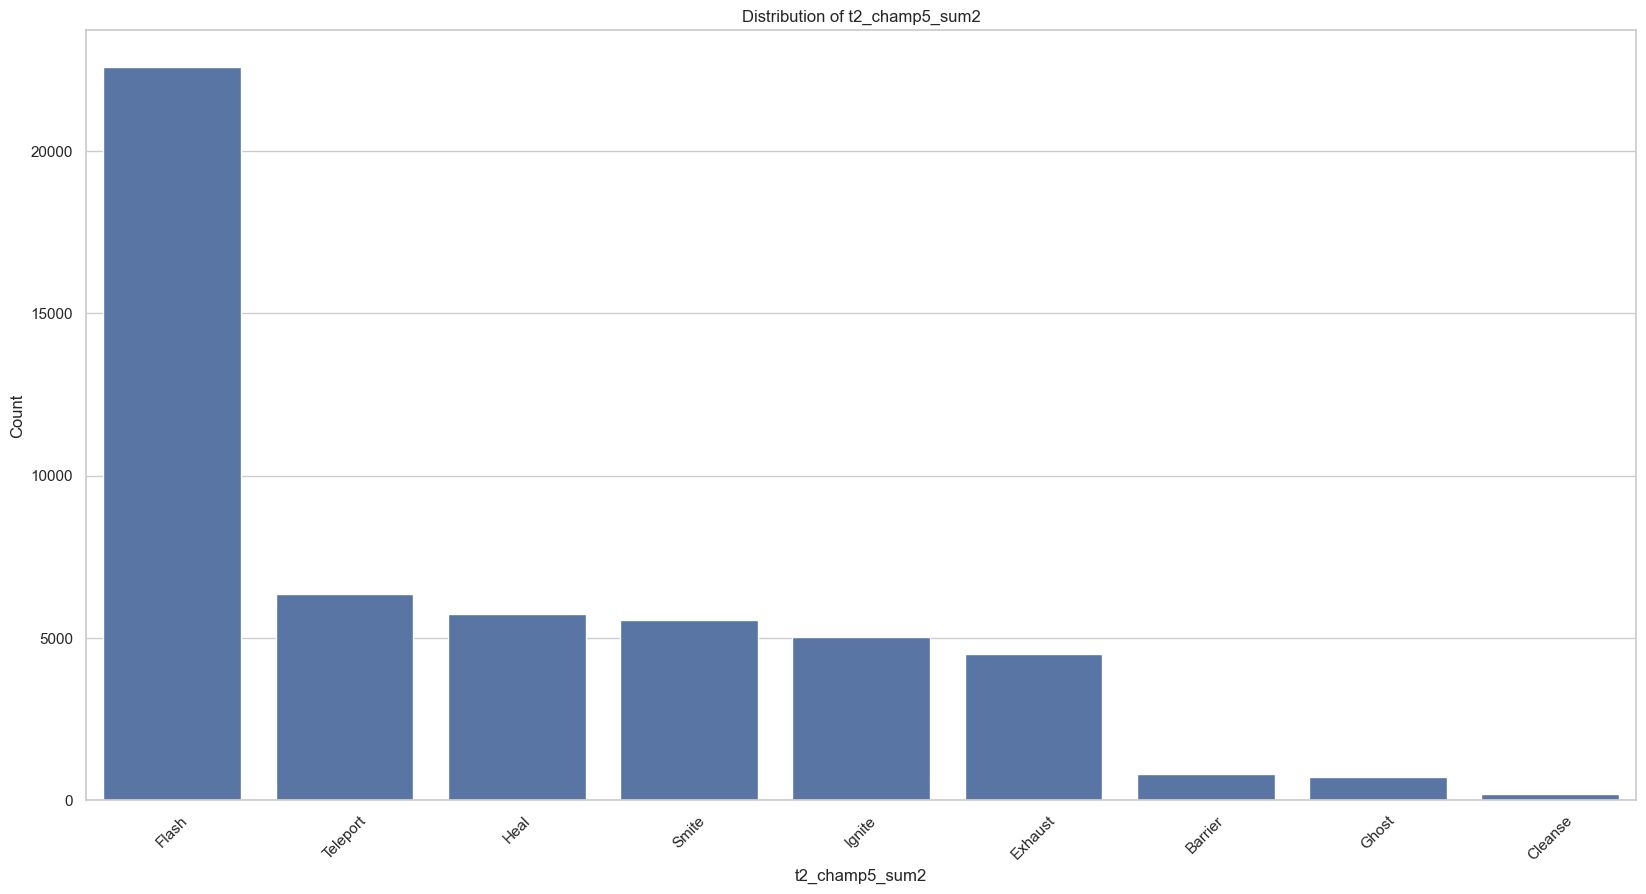

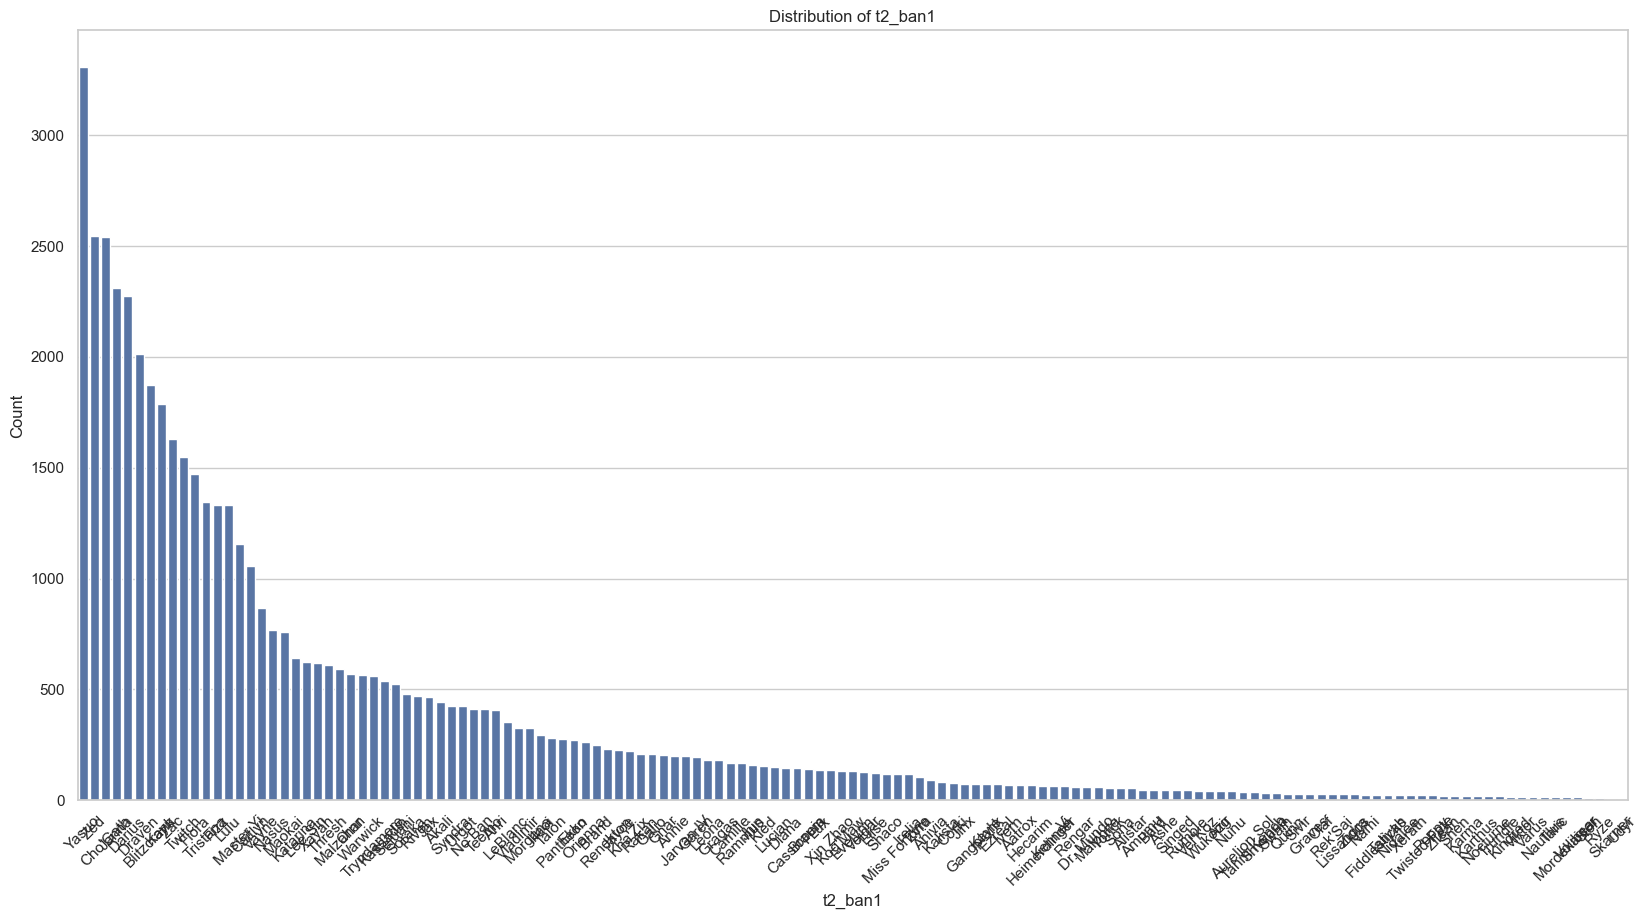

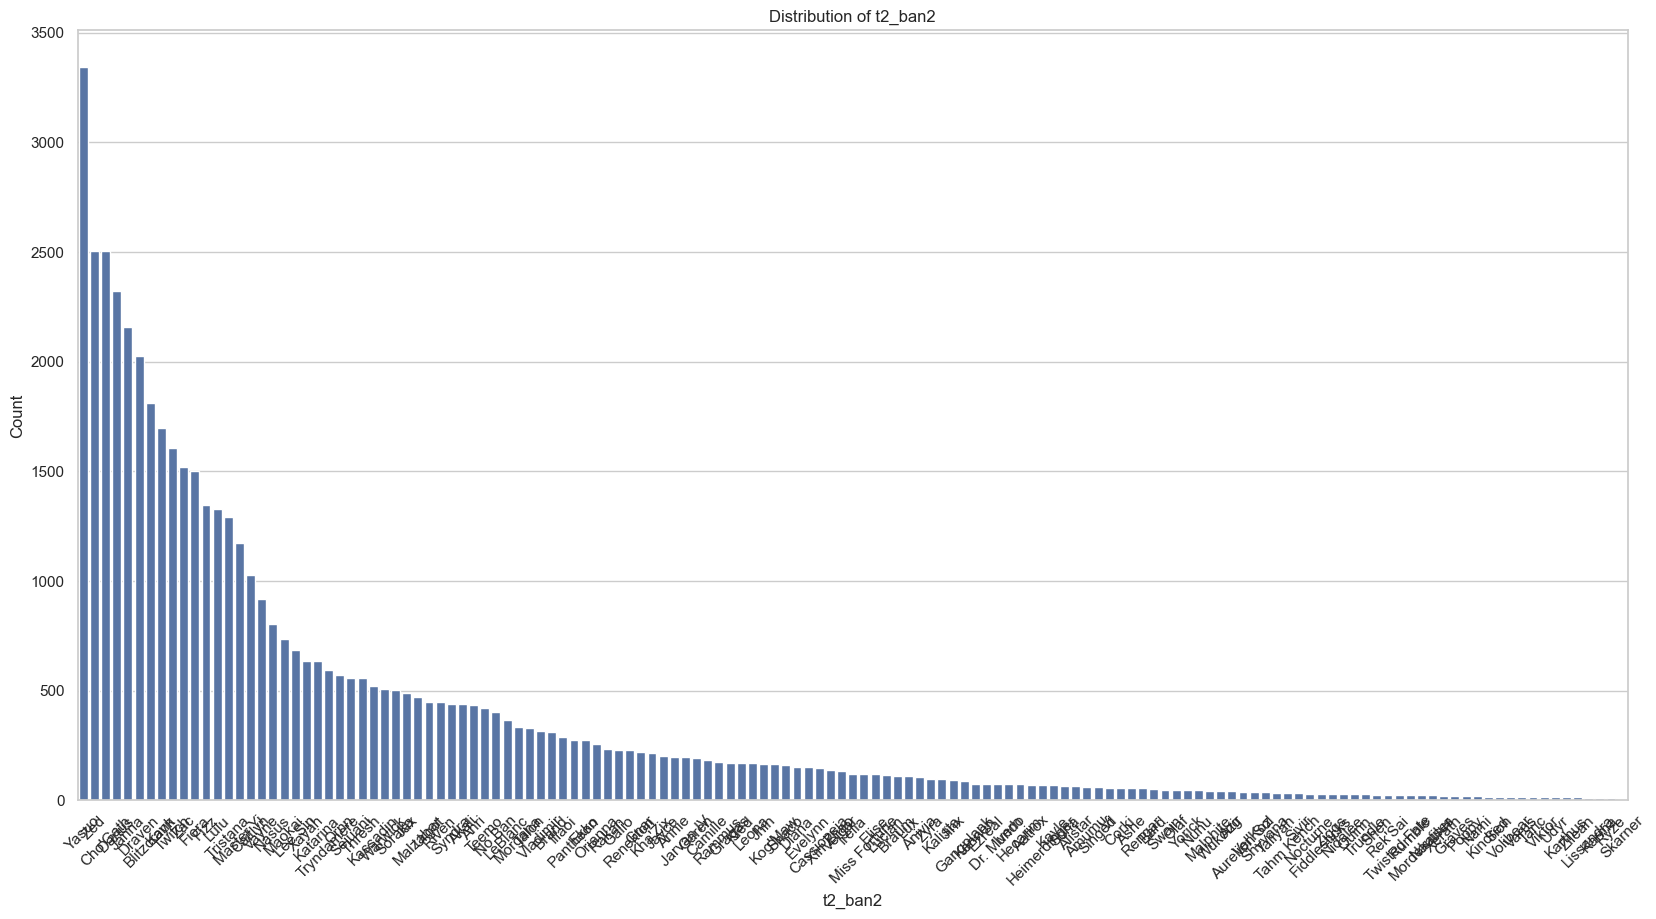

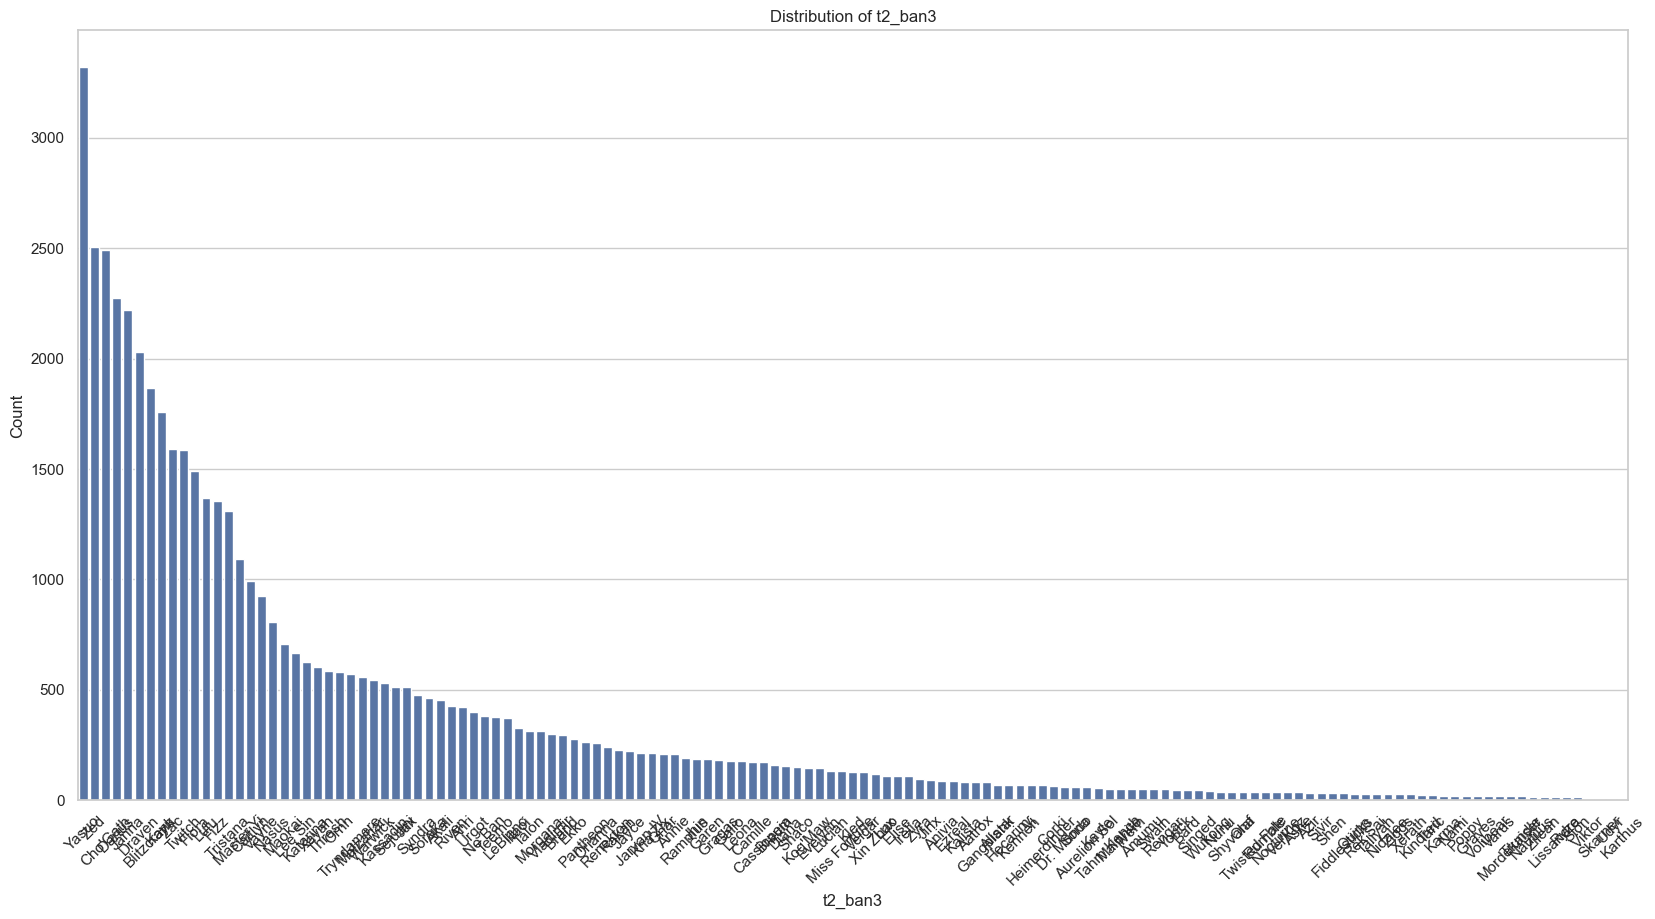

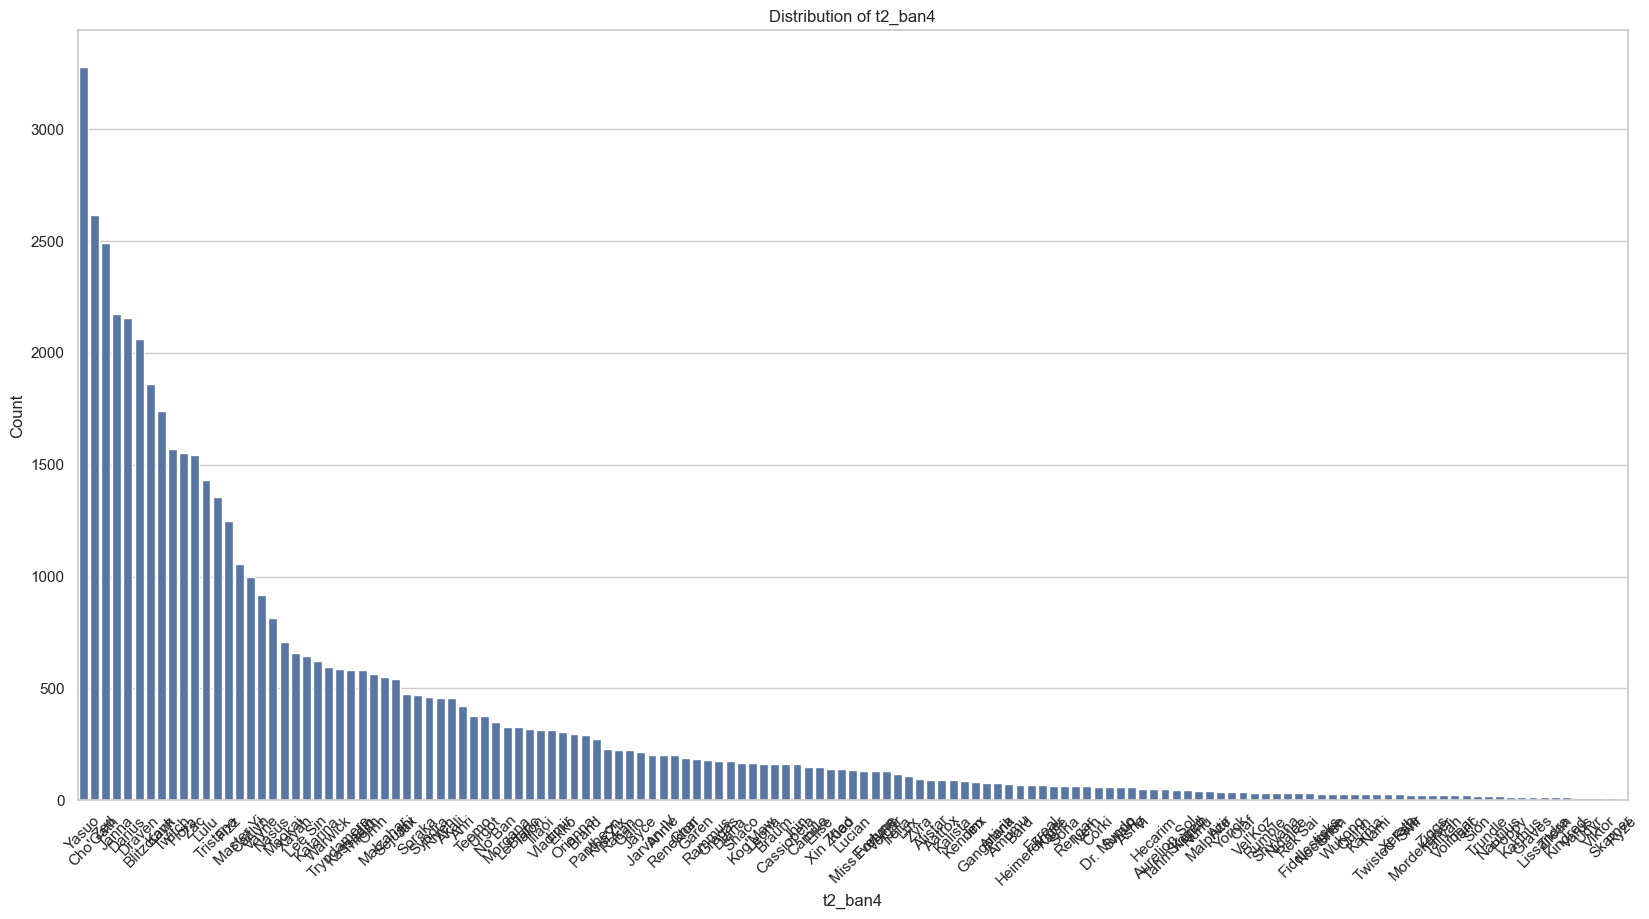

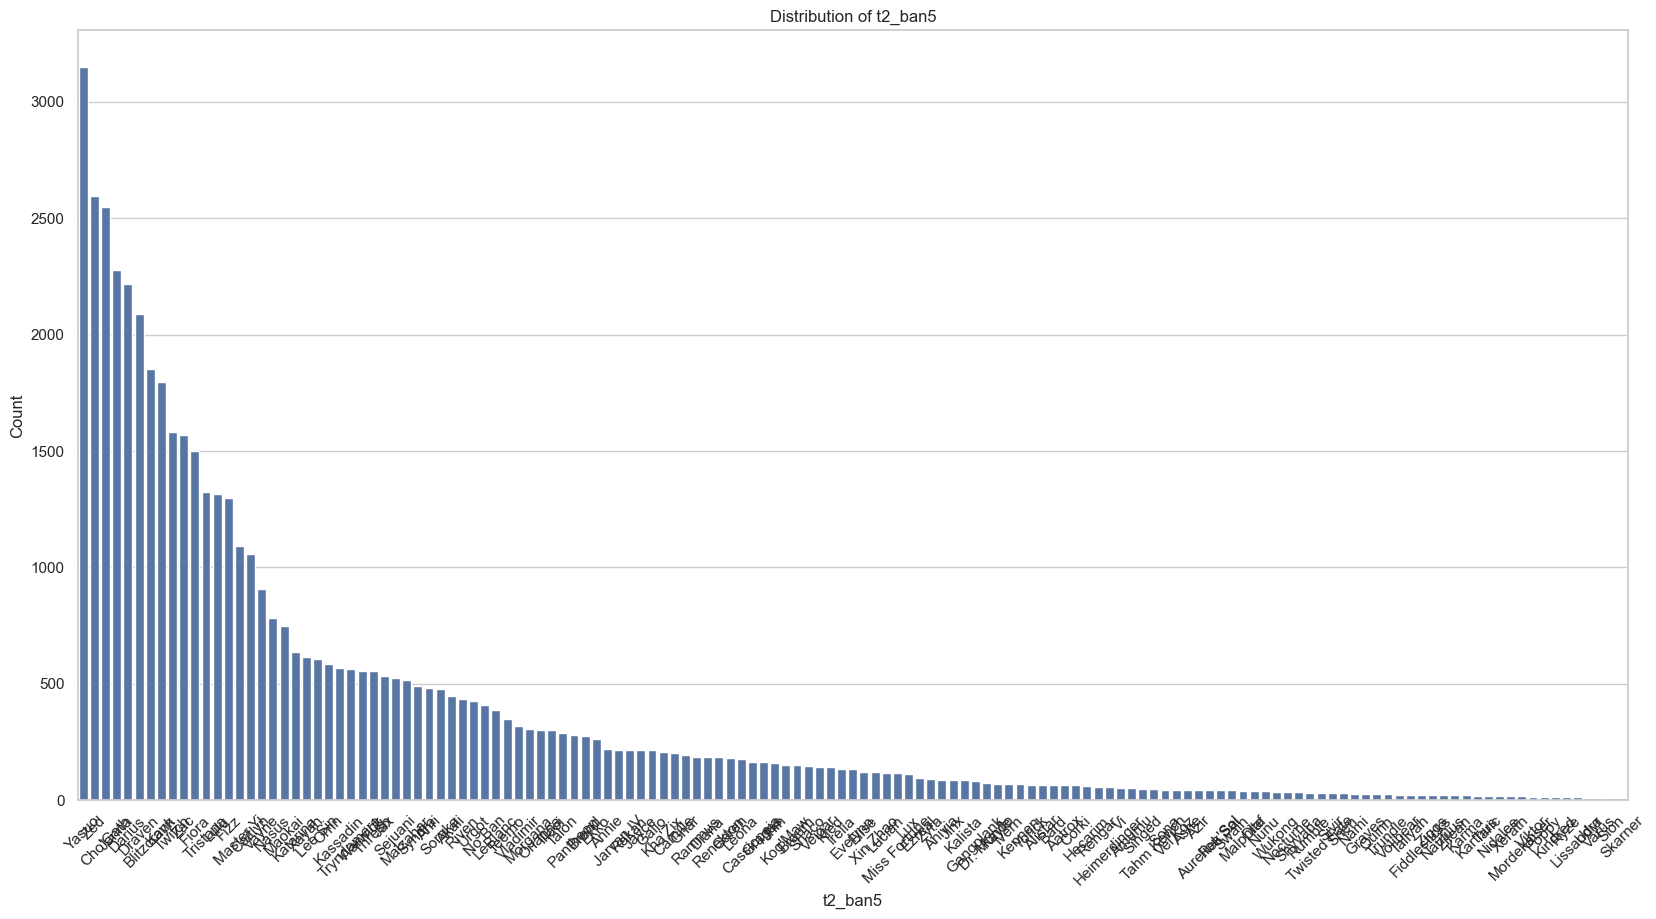

In [24]:
# Define numerical and categorical variables
numerical_data = df.select_dtypes(include='number')
categorical_data = df.select_dtypes(include='object')

# Set up the plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (20,10)

# 1. Numerical Variables: Boxplots
for col in numerical_data:
    # Boxplot
    plt.figure(figsize=(20,10))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

# 2. Categorical Variables: Bar Plots
for col in categorical_data:
    plt.figure(figsize=(20,10))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


For numerical columns:
- gameDuration, t1_inhibitorKills, t1_baronKills, t1_dragonKills, t2_inhibitorKills, t2_baronKills, t2_dragonKills, and t2_riftHeraldKills are not normally distributed.

For categorical columns:
- all categorical columns are not normally distributed.

### 1.4 Data Cleaning

In [25]:
df_copy = df.copy()
df_copy

,gameId,gameDuration,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,32,1,2,1,1,1,1,2,Vladimir,Teleport,Flash,Bard,Exhaust,Flash,Kog'Maw,Flash,Heal,Master Yi,Smite,Ghost,Viktor,Flash,Ignite,11,1,2,3,0,Riven,Janna,Cassiopeia,Draven,Kayn,Graves,Smite,Flash,Xayah,Flash,Heal,Darius,Ghost,Flash,Zed,Ignite,Flash,Thresh,Flash,Exhaust,5,0,0,1,1,Fiora,Vayne,Karma,Soraka,Caitlyn
1,3229566029,31,1,1,1,1,0,1,1,Draven,Heal,Flash,Irelia,Teleport,Flash,Nidalee,Flash,Exhaust,Kayle,Flash,Ignite,Shaco,Flash,Smite,10,4,0,2,1,Caitlyn,Darius,Teemo,Xayah,Warwick,Malphite,Flash,Teleport,Morgana,Flash,Ignite,Hecarim,Smite,Flash,Yasuo,Flash,Ignite,Riven,Flash,Heal,2,0,0,0,0,Master Yi,Vayne,Zed,Caitlyn,Illaoi
2,3327363504,25,1,2,1,1,1,2,0,Tristana,Flash,Heal,Kayn,Smite,Flash,Nami,Exhaust,Flash,Rumble,Flash,Teleport,Kassadin,Teleport,Flash,8,1,1,1,0,Lulu,Janna,Twitch,Soraka,Blitzcrank,Cassiopeia,Flash,Heal,Thresh,Ignite,Flash,Jayce,Flash,Teleport,Jax,Flash,Smite,Ashe,Heal,Flash,2,0,0,1,0,Yasuo,Zed,Kha'Zix,Maokai,Evelynn
3,3326856598,29,1,1,1,1,1,1,0,Maokai,Flash,Teleport,Brand,Flash,Ignite,Twitch,Flash,Heal,Orianna,Flash,Cleanse,Dr. Mundo,Smite,Flash,9,2,1,2,0,Zed,Vayne,Ornn,Fiora,Cho'Gath,Malzahar,Ignite,Flash,Warwick,Smite,Flash,Thresh,Flash,Exhaust,Riven,Flash,Ignite,Ashe,Flash,Heal,0,0,0,0,0,Camille,Tristana,Kayn,Janna,Caitlyn
4,3330080762,35,1,2,1,1,1,1,0,Warwick,Flash,Teleport,Twitch,Smite,Flash,Janna,Flash,Exhaust,Draven,Flash,Heal,Syndra,Heal,Flash,9,2,1,3,0,Malzahar,Lee Sin,Thresh,Morgana,Cho'Gath,Sona,Exhaust,Flash,Jarvan IV,Flash,Teleport,Kayn,Smite,Flash,Kassadin,Flash,Teleport,Caitlyn,Flash,Heal,3,0,0,1,0,Garen,Master Yi,Braum,Darius,Tristana
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51485,3308904636,32,2,1,2,2,0,2,0,Warwick,Teleport,Flash,Kalista,Flash,Heal,Talon,Flash,Ignite,Bard,Flash,Ignite,Lee Sin,Flash,Smite,2,0,0,0,0,Fiora,Tristana,Master Yi,Yasuo,Rakan,Veigar,Teleport,Flash,Yorick,Teleport,Flash,Vayne,Flash,Heal,Janna,Exhaust,Flash,Gragas,Smite,Flash,10,2,0,4,0,Katarina,No Ban,Malzahar,Zed,Yasuo
51486,3215685759,55,2,1,1,2,2,2,2,Malzahar,Flash,Ignite,Amumu,Flash,Smite,Cho'Gath,Teleport,Flash,Thresh,Ignite,Flash,Tristana,Flash,Heal,5,4,0,2,0,Yasuo,Camille,Darius,Lux,Illaoi,Shyvana,Smite,Flash,Kalista,Heal,Flash,Leona,Exhaust,Flash,Nasus,Flash,Teleport,Veigar,Ignite,Flash,11,7,4,4,1,Yasuo,Katarina,Draven,Zac,Fizz
51487,3322765040,36,2,2,2,2,0,1,0,Kayn,Smite,Flash,Tristana,Heal,Flash,Bard,Exhaust,Flash,Ezreal,Teleport,Flash,Rumble,Flash,Teleport,0,0,0,1,0,Zed,Cho'Gath,Jax,Blitzcrank,Master Yi,Annie,Flash,Teleport,Draven,Heal,Flash,Rammus,Smite,Flash,Karma,Teleport,Flash,Lux,Ignite,Flash,10,2,0,2,0,Sejuani,Darius,Blitzcrank,Master Yi,Yasuo
51488,3256675373,25,2,2,2,2,0,2,0,Kha'Zix,Smite,Flash,Lucian,Flash,Heal,Illaoi,Flash,Teleport,Braum,Flash,Exhaust,Lux,Flash,Ignite,0,0,0,0,0,Draven,Lee Sin,Caitlyn,Yasuo,Twitch,Miss Fortune,Heal,Flash,Nocturne,Flash,Teleport,Morgana,Flash,Ignite,Karthus,Teleport,Flash,Master Yi,Smite,Flash,11,3,0,1,0,Zac,Irelia,Caitlyn,Malzahar,Fiora


Data Duplicate

In [26]:
df_copy.groupby("gameId").size().reset_index(name="count").query("count > 1")

,gameId,count
1069,3226356326,2
4686,3253756161,2
5791,3259210188,2
6002,3260951695,2
6008,3260960203,2
...,...,...
50624,3331398020,2
50684,3331444373,2
50758,3331485517,2
50783,3331491546,2


In [27]:
df_copy = df_copy.drop_duplicates(subset=["gameId"], keep="first")

Based on game knowledge, the duration of ranked games should be at least 25 minutes. So we keep the game duration at least 25 minutes.
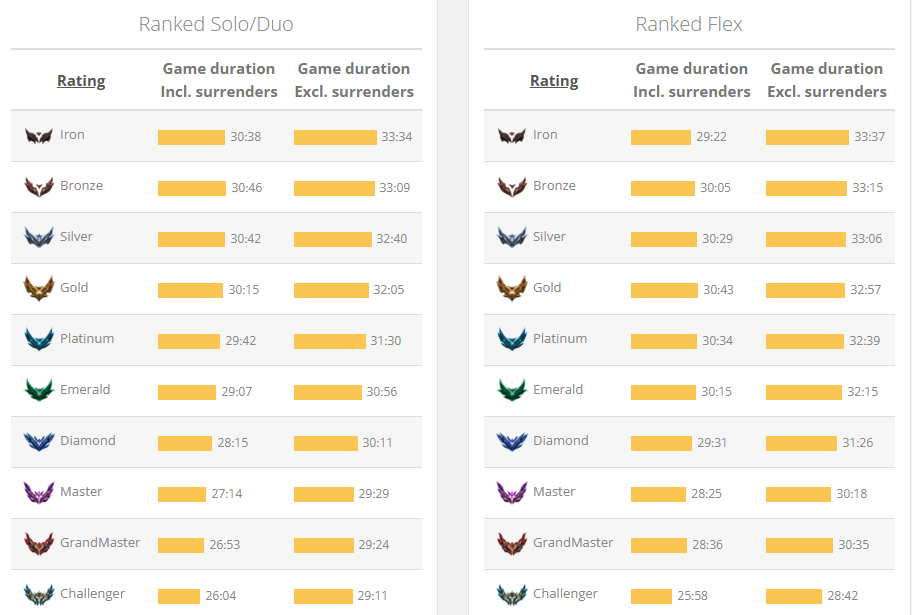

In [28]:
df_copy = df_copy[(df_copy['gameDuration'] > 24)]
df_copy

,gameId,gameDuration,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,32,1,2,1,1,1,1,2,Vladimir,Teleport,Flash,Bard,Exhaust,Flash,Kog'Maw,Flash,Heal,Master Yi,Smite,Ghost,Viktor,Flash,Ignite,11,1,2,3,0,Riven,Janna,Cassiopeia,Draven,Kayn,Graves,Smite,Flash,Xayah,Flash,Heal,Darius,Ghost,Flash,Zed,Ignite,Flash,Thresh,Flash,Exhaust,5,0,0,1,1,Fiora,Vayne,Karma,Soraka,Caitlyn
1,3229566029,31,1,1,1,1,0,1,1,Draven,Heal,Flash,Irelia,Teleport,Flash,Nidalee,Flash,Exhaust,Kayle,Flash,Ignite,Shaco,Flash,Smite,10,4,0,2,1,Caitlyn,Darius,Teemo,Xayah,Warwick,Malphite,Flash,Teleport,Morgana,Flash,Ignite,Hecarim,Smite,Flash,Yasuo,Flash,Ignite,Riven,Flash,Heal,2,0,0,0,0,Master Yi,Vayne,Zed,Caitlyn,Illaoi
2,3327363504,25,1,2,1,1,1,2,0,Tristana,Flash,Heal,Kayn,Smite,Flash,Nami,Exhaust,Flash,Rumble,Flash,Teleport,Kassadin,Teleport,Flash,8,1,1,1,0,Lulu,Janna,Twitch,Soraka,Blitzcrank,Cassiopeia,Flash,Heal,Thresh,Ignite,Flash,Jayce,Flash,Teleport,Jax,Flash,Smite,Ashe,Heal,Flash,2,0,0,1,0,Yasuo,Zed,Kha'Zix,Maokai,Evelynn
3,3326856598,29,1,1,1,1,1,1,0,Maokai,Flash,Teleport,Brand,Flash,Ignite,Twitch,Flash,Heal,Orianna,Flash,Cleanse,Dr. Mundo,Smite,Flash,9,2,1,2,0,Zed,Vayne,Ornn,Fiora,Cho'Gath,Malzahar,Ignite,Flash,Warwick,Smite,Flash,Thresh,Flash,Exhaust,Riven,Flash,Ignite,Ashe,Flash,Heal,0,0,0,0,0,Camille,Tristana,Kayn,Janna,Caitlyn
4,3330080762,35,1,2,1,1,1,1,0,Warwick,Flash,Teleport,Twitch,Smite,Flash,Janna,Flash,Exhaust,Draven,Flash,Heal,Syndra,Heal,Flash,9,2,1,3,0,Malzahar,Lee Sin,Thresh,Morgana,Cho'Gath,Sona,Exhaust,Flash,Jarvan IV,Flash,Teleport,Kayn,Smite,Flash,Kassadin,Flash,Teleport,Caitlyn,Flash,Heal,3,0,0,1,0,Garen,Master Yi,Braum,Darius,Tristana
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51484,3316694929,45,2,2,1,2,2,2,0,Varus,Flash,Heal,Brand,Heal,Flash,LeBlanc,Ignite,Flash,Shaco,Ignite,Smite,Cho'Gath,Flash,Ignite,5,1,0,2,0,Illaoi,Blitzcrank,Lee Sin,Yasuo,Jinx,Taric,Flash,Exhaust,Jhin,Flash,Heal,Master Yi,Smite,Ghost,Akali,Flash,Ignite,Kayn,Flash,Teleport,11,5,2,3,0,Maokai,Miss Fortune,Yasuo,Blitzcrank,Renekton
51485,3308904636,32,2,1,2,2,0,2,0,Warwick,Teleport,Flash,Kalista,Flash,Heal,Talon,Flash,Ignite,Bard,Flash,Ignite,Lee Sin,Flash,Smite,2,0,0,0,0,Fiora,Tristana,Master Yi,Yasuo,Rakan,Veigar,Teleport,Flash,Yorick,Teleport,Flash,Vayne,Flash,Heal,Janna,Exhaust,Flash,Gragas,Smite,Flash,10,2,0,4,0,Katarina,No Ban,Malzahar,Zed,Yasuo
51486,3215685759,55,2,1,1,2,2,2,2,Malzahar,Flash,Ignite,Amumu,Flash,Smite,Cho'Gath,Teleport,Flash,Thresh,Ignite,Flash,Tristana,Flash,Heal,5,4,0,2,0,Yasuo,Camille,Darius,Lux,Illaoi,Shyvana,Smite,Flash,Kalista,Heal,Flash,Leona,Exhaust,Flash,Nasus,Flash,Teleport,Veigar,Ignite,Flash,11,7,4,4,1,Yasuo,Katarina,Draven,Zac,Fizz
51487,3322765040,36,2,2,2,2,0,1,0,Kayn,Smite,Flash,Tristana,Heal,Flash,Bard,Exhaust,Flash,Ezreal,Teleport,Flash,Rumble,Flash,Teleport,0,0,0,1,0,Zed,Cho'Gath,Jax,Blitzcrank,Master Yi,Annie,Flash,Teleport,Draven,Heal,Flash,Rammus,Smite,Flash,Karma,Teleport,Flash,Lux,Ignite,Flash,10,2,0,2,0,Sejuani,Darius,Blitzcrank,Master Yi,Yasuo


1.5 * IQR outliers detection method

In [29]:
# Auto-detect numerical columns
numerical_data = df_copy.select_dtypes(include=['int64','float64']).columns.tolist()

# Subset only numerical columns
numeric = df_copy[numerical_data]

list_total_outliers = []

for each_kolom in numeric.columns:
    q3 = numeric[each_kolom].quantile(0.75)
    q1 = numeric[each_kolom].quantile(0.25)
    iqr = q3 - q1
    whis = 1.5 * iqr
    upper_bound = q3 + whis
    lower_bound = q1 - whis

    total_outliers = numeric[
        (numeric[each_kolom] > upper_bound) | 
        (numeric[each_kolom] < lower_bound)
    ].shape[0]
    
    list_total_outliers.append(total_outliers)

outlier_summary = pd.DataFrame({
    'column': numeric.columns,
    'total outliers': list_total_outliers,
    'outliers percentage' : [total/len(df_copy) for total in list_total_outliers]
})

outlier_summary


,column,total outliers,outliers percentage
0,gameId,2011,0.049767
1,winner,0,0.000000
2,firstBlood,0,0.000000
3,firstTower,0,0.000000
4,firstInhibitor,0,0.000000
5,firstBaron,0,0.000000
6,firstDragon,0,0.000000
7,firstRiftHerald,0,0.000000
8,t1_towerKills,0,0.000000
9,t1_inhibitorKills,198,0.004900


Based on outliers detection, t2_riftHeraldKills have 24% outliers. 

Based on LoL game knowledge, The Rift Herald is an epic monster in Summoner's Rift. It is located in the baron pit. Slaying the Rift Herald drops the. Eye of the Herald at the entrance of the pit for 20 seconds, which can be picked up by one member of the slayer's team, and is used for summoning the Rift Herald Mercenary.

- Rift Heralds are large monsters that only appear in the early-mid game (before the Baron spawns).
- A maximum of two Heralds can spawn in a single game (the first Herald → if killed quickly enough, a second Herald will spawn).

So, according to game rules:
- The normal value for t2_riftHeraldKills is 0, 1, or 2.
- If there's a much higher value (e.g., 5, 10, or even 20+), it's impossible to occur in a real match.
- This means that numbers above 2 are data anomalies/input errors → outliers that are invalid by game logic.

**So based on game knowledge I'll keep the outliers.**

## 2. Explanatory Data Analysis

In [30]:
df_copy

,gameId,gameDuration,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,32,1,2,1,1,1,1,2,Vladimir,Teleport,Flash,Bard,Exhaust,Flash,Kog'Maw,Flash,Heal,Master Yi,Smite,Ghost,Viktor,Flash,Ignite,11,1,2,3,0,Riven,Janna,Cassiopeia,Draven,Kayn,Graves,Smite,Flash,Xayah,Flash,Heal,Darius,Ghost,Flash,Zed,Ignite,Flash,Thresh,Flash,Exhaust,5,0,0,1,1,Fiora,Vayne,Karma,Soraka,Caitlyn
1,3229566029,31,1,1,1,1,0,1,1,Draven,Heal,Flash,Irelia,Teleport,Flash,Nidalee,Flash,Exhaust,Kayle,Flash,Ignite,Shaco,Flash,Smite,10,4,0,2,1,Caitlyn,Darius,Teemo,Xayah,Warwick,Malphite,Flash,Teleport,Morgana,Flash,Ignite,Hecarim,Smite,Flash,Yasuo,Flash,Ignite,Riven,Flash,Heal,2,0,0,0,0,Master Yi,Vayne,Zed,Caitlyn,Illaoi
2,3327363504,25,1,2,1,1,1,2,0,Tristana,Flash,Heal,Kayn,Smite,Flash,Nami,Exhaust,Flash,Rumble,Flash,Teleport,Kassadin,Teleport,Flash,8,1,1,1,0,Lulu,Janna,Twitch,Soraka,Blitzcrank,Cassiopeia,Flash,Heal,Thresh,Ignite,Flash,Jayce,Flash,Teleport,Jax,Flash,Smite,Ashe,Heal,Flash,2,0,0,1,0,Yasuo,Zed,Kha'Zix,Maokai,Evelynn
3,3326856598,29,1,1,1,1,1,1,0,Maokai,Flash,Teleport,Brand,Flash,Ignite,Twitch,Flash,Heal,Orianna,Flash,Cleanse,Dr. Mundo,Smite,Flash,9,2,1,2,0,Zed,Vayne,Ornn,Fiora,Cho'Gath,Malzahar,Ignite,Flash,Warwick,Smite,Flash,Thresh,Flash,Exhaust,Riven,Flash,Ignite,Ashe,Flash,Heal,0,0,0,0,0,Camille,Tristana,Kayn,Janna,Caitlyn
4,3330080762,35,1,2,1,1,1,1,0,Warwick,Flash,Teleport,Twitch,Smite,Flash,Janna,Flash,Exhaust,Draven,Flash,Heal,Syndra,Heal,Flash,9,2,1,3,0,Malzahar,Lee Sin,Thresh,Morgana,Cho'Gath,Sona,Exhaust,Flash,Jarvan IV,Flash,Teleport,Kayn,Smite,Flash,Kassadin,Flash,Teleport,Caitlyn,Flash,Heal,3,0,0,1,0,Garen,Master Yi,Braum,Darius,Tristana
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51484,3316694929,45,2,2,1,2,2,2,0,Varus,Flash,Heal,Brand,Heal,Flash,LeBlanc,Ignite,Flash,Shaco,Ignite,Smite,Cho'Gath,Flash,Ignite,5,1,0,2,0,Illaoi,Blitzcrank,Lee Sin,Yasuo,Jinx,Taric,Flash,Exhaust,Jhin,Flash,Heal,Master Yi,Smite,Ghost,Akali,Flash,Ignite,Kayn,Flash,Teleport,11,5,2,3,0,Maokai,Miss Fortune,Yasuo,Blitzcrank,Renekton
51485,3308904636,32,2,1,2,2,0,2,0,Warwick,Teleport,Flash,Kalista,Flash,Heal,Talon,Flash,Ignite,Bard,Flash,Ignite,Lee Sin,Flash,Smite,2,0,0,0,0,Fiora,Tristana,Master Yi,Yasuo,Rakan,Veigar,Teleport,Flash,Yorick,Teleport,Flash,Vayne,Flash,Heal,Janna,Exhaust,Flash,Gragas,Smite,Flash,10,2,0,4,0,Katarina,No Ban,Malzahar,Zed,Yasuo
51486,3215685759,55,2,1,1,2,2,2,2,Malzahar,Flash,Ignite,Amumu,Flash,Smite,Cho'Gath,Teleport,Flash,Thresh,Ignite,Flash,Tristana,Flash,Heal,5,4,0,2,0,Yasuo,Camille,Darius,Lux,Illaoi,Shyvana,Smite,Flash,Kalista,Heal,Flash,Leona,Exhaust,Flash,Nasus,Flash,Teleport,Veigar,Ignite,Flash,11,7,4,4,1,Yasuo,Katarina,Draven,Zac,Fizz
51487,3322765040,36,2,2,2,2,0,1,0,Kayn,Smite,Flash,Tristana,Heal,Flash,Bard,Exhaust,Flash,Ezreal,Teleport,Flash,Rumble,Flash,Teleport,0,0,0,1,0,Zed,Cho'Gath,Jax,Blitzcrank,Master Yi,Annie,Flash,Teleport,Draven,Heal,Flash,Rammus,Smite,Flash,Karma,Teleport,Flash,Lux,Ignite,Flash,10,2,0,2,0,Sejuani,Darius,Blitzcrank,Master Yi,Yasuo


### 2.1. Game duration

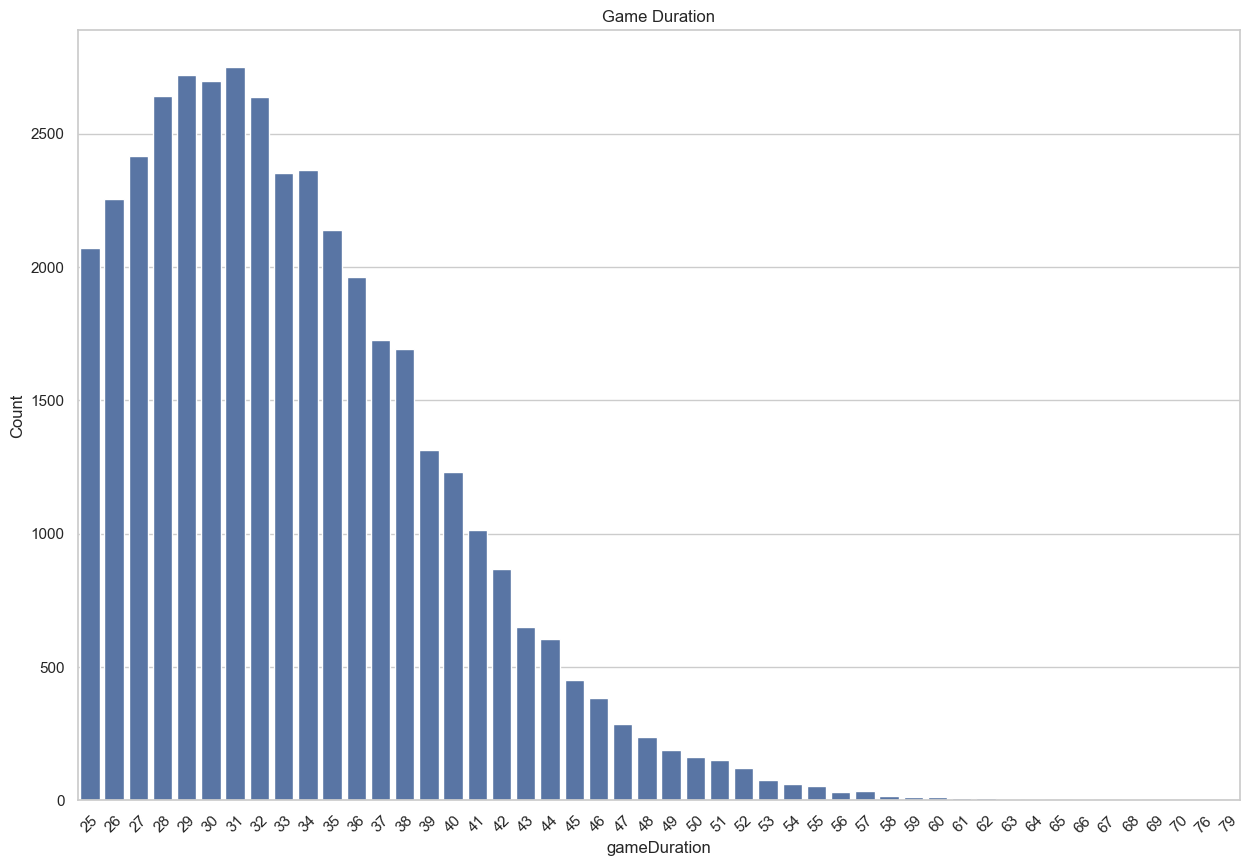

In [31]:
plt.figure(figsize=(15,10))
sns.countplot(data=df_copy, x='gameDuration')
plt.title(f'Game Duration')
plt.xlabel('gameDuration')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Based on game duration in season 9 EU server ranked games, most of each game duration are 31, 29, and 30 minutes.

### 2.2 Win Conditions & Objectives

In [32]:
df_copy_winner = df_copy.copy()
df_copy_winner

,gameId,gameDuration,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,32,1,2,1,1,1,1,2,Vladimir,Teleport,Flash,Bard,Exhaust,Flash,Kog'Maw,Flash,Heal,Master Yi,Smite,Ghost,Viktor,Flash,Ignite,11,1,2,3,0,Riven,Janna,Cassiopeia,Draven,Kayn,Graves,Smite,Flash,Xayah,Flash,Heal,Darius,Ghost,Flash,Zed,Ignite,Flash,Thresh,Flash,Exhaust,5,0,0,1,1,Fiora,Vayne,Karma,Soraka,Caitlyn
1,3229566029,31,1,1,1,1,0,1,1,Draven,Heal,Flash,Irelia,Teleport,Flash,Nidalee,Flash,Exhaust,Kayle,Flash,Ignite,Shaco,Flash,Smite,10,4,0,2,1,Caitlyn,Darius,Teemo,Xayah,Warwick,Malphite,Flash,Teleport,Morgana,Flash,Ignite,Hecarim,Smite,Flash,Yasuo,Flash,Ignite,Riven,Flash,Heal,2,0,0,0,0,Master Yi,Vayne,Zed,Caitlyn,Illaoi
2,3327363504,25,1,2,1,1,1,2,0,Tristana,Flash,Heal,Kayn,Smite,Flash,Nami,Exhaust,Flash,Rumble,Flash,Teleport,Kassadin,Teleport,Flash,8,1,1,1,0,Lulu,Janna,Twitch,Soraka,Blitzcrank,Cassiopeia,Flash,Heal,Thresh,Ignite,Flash,Jayce,Flash,Teleport,Jax,Flash,Smite,Ashe,Heal,Flash,2,0,0,1,0,Yasuo,Zed,Kha'Zix,Maokai,Evelynn
3,3326856598,29,1,1,1,1,1,1,0,Maokai,Flash,Teleport,Brand,Flash,Ignite,Twitch,Flash,Heal,Orianna,Flash,Cleanse,Dr. Mundo,Smite,Flash,9,2,1,2,0,Zed,Vayne,Ornn,Fiora,Cho'Gath,Malzahar,Ignite,Flash,Warwick,Smite,Flash,Thresh,Flash,Exhaust,Riven,Flash,Ignite,Ashe,Flash,Heal,0,0,0,0,0,Camille,Tristana,Kayn,Janna,Caitlyn
4,3330080762,35,1,2,1,1,1,1,0,Warwick,Flash,Teleport,Twitch,Smite,Flash,Janna,Flash,Exhaust,Draven,Flash,Heal,Syndra,Heal,Flash,9,2,1,3,0,Malzahar,Lee Sin,Thresh,Morgana,Cho'Gath,Sona,Exhaust,Flash,Jarvan IV,Flash,Teleport,Kayn,Smite,Flash,Kassadin,Flash,Teleport,Caitlyn,Flash,Heal,3,0,0,1,0,Garen,Master Yi,Braum,Darius,Tristana
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51484,3316694929,45,2,2,1,2,2,2,0,Varus,Flash,Heal,Brand,Heal,Flash,LeBlanc,Ignite,Flash,Shaco,Ignite,Smite,Cho'Gath,Flash,Ignite,5,1,0,2,0,Illaoi,Blitzcrank,Lee Sin,Yasuo,Jinx,Taric,Flash,Exhaust,Jhin,Flash,Heal,Master Yi,Smite,Ghost,Akali,Flash,Ignite,Kayn,Flash,Teleport,11,5,2,3,0,Maokai,Miss Fortune,Yasuo,Blitzcrank,Renekton
51485,3308904636,32,2,1,2,2,0,2,0,Warwick,Teleport,Flash,Kalista,Flash,Heal,Talon,Flash,Ignite,Bard,Flash,Ignite,Lee Sin,Flash,Smite,2,0,0,0,0,Fiora,Tristana,Master Yi,Yasuo,Rakan,Veigar,Teleport,Flash,Yorick,Teleport,Flash,Vayne,Flash,Heal,Janna,Exhaust,Flash,Gragas,Smite,Flash,10,2,0,4,0,Katarina,No Ban,Malzahar,Zed,Yasuo
51486,3215685759,55,2,1,1,2,2,2,2,Malzahar,Flash,Ignite,Amumu,Flash,Smite,Cho'Gath,Teleport,Flash,Thresh,Ignite,Flash,Tristana,Flash,Heal,5,4,0,2,0,Yasuo,Camille,Darius,Lux,Illaoi,Shyvana,Smite,Flash,Kalista,Heal,Flash,Leona,Exhaust,Flash,Nasus,Flash,Teleport,Veigar,Ignite,Flash,11,7,4,4,1,Yasuo,Katarina,Draven,Zac,Fizz
51487,3322765040,36,2,2,2,2,0,1,0,Kayn,Smite,Flash,Tristana,Heal,Flash,Bard,Exhaust,Flash,Ezreal,Teleport,Flash,Rumble,Flash,Teleport,0,0,0,1,0,Zed,Cho'Gath,Jax,Blitzcrank,Master Yi,Annie,Flash,Teleport,Draven,Heal,Flash,Rammus,Smite,Flash,Karma,Teleport,Flash,Lux,Ignite,Flash,10,2,0,2,0,Sejuani,Darius,Blitzcrank,Master Yi,Yasuo


In [33]:
df_copy_winner["firstBlood_win"] = (df_copy["firstBlood"] == df_copy["winner"]).astype(int)
df_copy_winner["firstTower_win"] = (df_copy["firstTower"] == df_copy["winner"]).astype(int)
df_copy_winner["firstInhibitor_win"] = (df_copy["firstInhibitor"] == df_copy["winner"]).astype(int)
df_copy_winner["firstDragon_win"] = (df_copy["firstDragon"] == df_copy["winner"]).astype(int)
df_copy_winner["firstBaron_win"] = (df_copy["firstBaron"] == df_copy["winner"]).astype(int)


win_rates = df_copy_winner[["firstBlood_win","firstTower_win", "firstInhibitor_win", "firstDragon_win","firstBaron_win"]].mean()

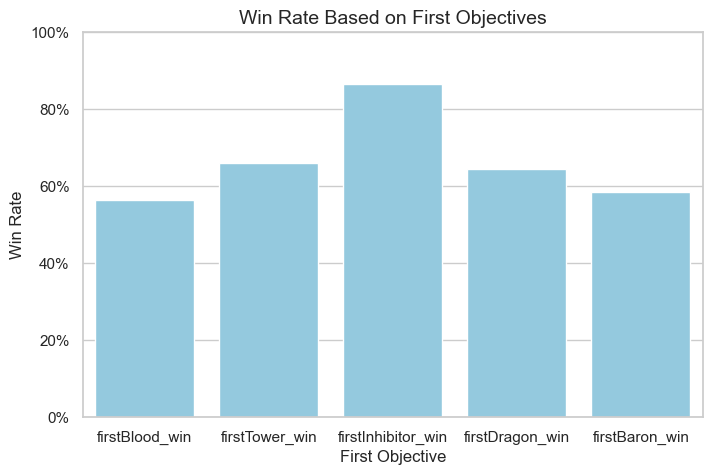

In [34]:
win_rates_df = win_rates.reset_index()
win_rates_df.columns = ["Objective", "Win Rate"]

plt.figure(figsize=(8,5))
sns.barplot(x="Objective", y="Win Rate", data=win_rates_df, color="skyblue")

plt.title("Win Rate Based on First Objectives", fontsize=14)
plt.ylabel("Win Rate")
plt.xlabel("First Objective")
plt.ylim(0,1)  # karena win rate antara 0-1
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y*100)}%"))  # ubah ke persen

plt.show()


The team that destroys the inhibitor tower first has a very big chance of winning the match, as much as 86%

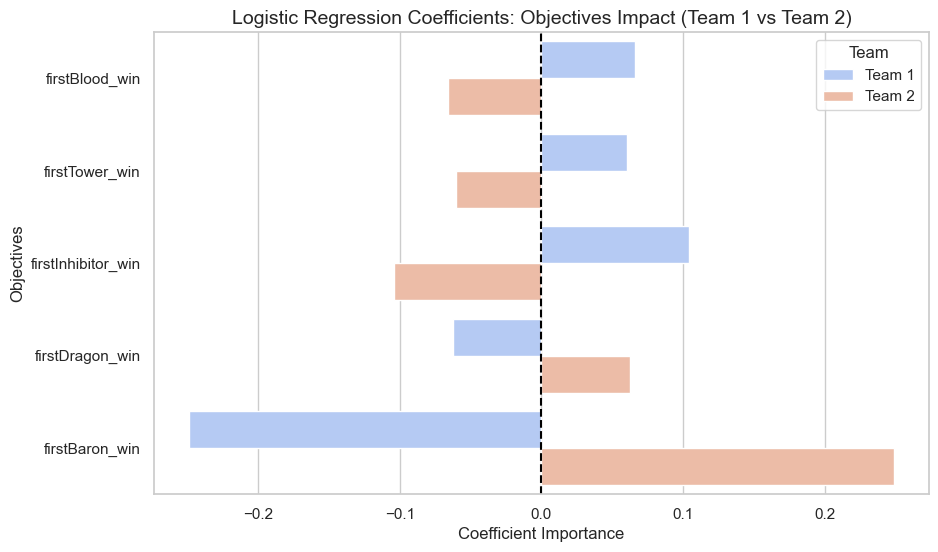

In [35]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Objective Feature
features = ["firstBlood_win", "firstTower_win", "firstInhibitor_win", "firstDragon_win", "firstBaron_win"]
X = df_copy_winner[features]
y = (df_copy_winner["winner"] == 1).astype(int)  # 1 = Team 1 Won, 0 = Team 2 Won

# Fit Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Take coeficient for Team 1
coef_team1 = model.coef_[0]

# Team 2
coef_team2 = -coef_team1

# Combine in DataFrame
coef_df = pd.DataFrame({
    "Feature": features,
    "Team 1": coef_team1,
    "Team 2": coef_team2
}).melt(id_vars="Feature", var_name="Team", value_name="Coefficient")

# Side-by-side visualization
plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", hue="Team", data=coef_df, palette="coolwarm")
plt.axvline(0, color="black", linestyle="--")
plt.title("Logistic Regression Coefficients: Objectives Impact (Team 1 vs Team 2)", fontsize=14)
plt.xlabel("Coefficient Importance")
plt.ylabel("Objectives")
plt.show()


Intepretation per Objective:
- First Blood:
    - The coefficient is relatively small, for both Team 1 and Team 2. This means that first blood doesn't significantly determine the final outcome, only slightly increasing the chances for the team that takes it.

- First Tower:
    - Provides a moderate positive effect. If a team takes first tower, their chances of winning increase significantly compared to first blood.

- First Inhibitor:
    - The coefficient is quite high and positive. This is logical, because inhibitors are usually obtained when the game is already tilted to one side. Therefore, the team that takes first inhibitor is almost certainly closer to victory.

- First Dragon:
    - The effect is small and slightly weaker than first tower. This makes sense, because one dragon alone is usually not decisive — the impact is only felt if the team consistently takes many dragons (stacks).

- First Baron:
    - Most dominant in the chart. Very large coefficient → the team that takes first Baron is at a significant advantage. This means that the baron buff is one of the most powerful win conditions.

Overall, this graph shows that objective-based play (tower, inhibitor, baron) is much more decisive for victory than early skirmish (first blood, first dragon).

### 2.3 Team Strategy

In [36]:
df_copy_winner

,gameId,gameDuration,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5,firstBlood_win,firstTower_win,firstInhibitor_win,firstDragon_win,firstBaron_win
0,3326086514,32,1,2,1,1,1,1,2,Vladimir,Teleport,Flash,Bard,Exhaust,Flash,Kog'Maw,Flash,Heal,Master Yi,Smite,Ghost,Viktor,Flash,Ignite,11,1,2,3,0,Riven,Janna,Cassiopeia,Draven,Kayn,Graves,Smite,Flash,Xayah,Flash,Heal,Darius,Ghost,Flash,Zed,Ignite,Flash,Thresh,Flash,Exhaust,5,0,0,1,1,Fiora,Vayne,Karma,Soraka,Caitlyn,0,1,1,1,1
1,3229566029,31,1,1,1,1,0,1,1,Draven,Heal,Flash,Irelia,Teleport,Flash,Nidalee,Flash,Exhaust,Kayle,Flash,Ignite,Shaco,Flash,Smite,10,4,0,2,1,Caitlyn,Darius,Teemo,Xayah,Warwick,Malphite,Flash,Teleport,Morgana,Flash,Ignite,Hecarim,Smite,Flash,Yasuo,Flash,Ignite,Riven,Flash,Heal,2,0,0,0,0,Master Yi,Vayne,Zed,Caitlyn,Illaoi,1,1,1,1,0
2,3327363504,25,1,2,1,1,1,2,0,Tristana,Flash,Heal,Kayn,Smite,Flash,Nami,Exhaust,Flash,Rumble,Flash,Teleport,Kassadin,Teleport,Flash,8,1,1,1,0,Lulu,Janna,Twitch,Soraka,Blitzcrank,Cassiopeia,Flash,Heal,Thresh,Ignite,Flash,Jayce,Flash,Teleport,Jax,Flash,Smite,Ashe,Heal,Flash,2,0,0,1,0,Yasuo,Zed,Kha'Zix,Maokai,Evelynn,0,1,1,0,1
3,3326856598,29,1,1,1,1,1,1,0,Maokai,Flash,Teleport,Brand,Flash,Ignite,Twitch,Flash,Heal,Orianna,Flash,Cleanse,Dr. Mundo,Smite,Flash,9,2,1,2,0,Zed,Vayne,Ornn,Fiora,Cho'Gath,Malzahar,Ignite,Flash,Warwick,Smite,Flash,Thresh,Flash,Exhaust,Riven,Flash,Ignite,Ashe,Flash,Heal,0,0,0,0,0,Camille,Tristana,Kayn,Janna,Caitlyn,1,1,1,1,1
4,3330080762,35,1,2,1,1,1,1,0,Warwick,Flash,Teleport,Twitch,Smite,Flash,Janna,Flash,Exhaust,Draven,Flash,Heal,Syndra,Heal,Flash,9,2,1,3,0,Malzahar,Lee Sin,Thresh,Morgana,Cho'Gath,Sona,Exhaust,Flash,Jarvan IV,Flash,Teleport,Kayn,Smite,Flash,Kassadin,Flash,Teleport,Caitlyn,Flash,Heal,3,0,0,1,0,Garen,Master Yi,Braum,Darius,Tristana,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51484,3316694929,45,2,2,1,2,2,2,0,Varus,Flash,Heal,Brand,Heal,Flash,LeBlanc,Ignite,Flash,Shaco,Ignite,Smite,Cho'Gath,Flash,Ignite,5,1,0,2,0,Illaoi,Blitzcrank,Lee Sin,Yasuo,Jinx,Taric,Flash,Exhaust,Jhin,Flash,Heal,Master Yi,Smite,Ghost,Akali,Flash,Ignite,Kayn,Flash,Teleport,11,5,2,3,0,Maokai,Miss Fortune,Yasuo,Blitzcrank,Renekton,1,0,1,1,1
51485,3308904636,32,2,1,2,2,0,2,0,Warwick,Teleport,Flash,Kalista,Flash,Heal,Talon,Flash,Ignite,Bard,Flash,Ignite,Lee Sin,Flash,Smite,2,0,0,0,0,Fiora,Tristana,Master Yi,Yasuo,Rakan,Veigar,Teleport,Flash,Yorick,Teleport,Flash,Vayne,Flash,Heal,Janna,Exhaust,Flash,Gragas,Smite,Flash,10,2,0,4,0,Katarina,No Ban,Malzahar,Zed,Yasuo,0,1,1,1,0
51486,3215685759,55,2,1,1,2,2,2,2,Malzahar,Flash,Ignite,Amumu,Flash,Smite,Cho'Gath,Teleport,Flash,Thresh,Ignite,Flash,Tristana,Flash,Heal,5,4,0,2,0,Yasuo,Camille,Darius,Lux,Illaoi,Shyvana,Smite,Flash,Kalista,Heal,Flash,Leona,Exhaust,Flash,Nasus,Flash,Teleport,Veigar,Ignite,Flash,11,7,4,4,1,Yasuo,Katarina,Draven,Zac,Fizz,0,0,1,1,1
51487,3322765040,36,2,2,2,2,0,1,0,Kayn,Smite,Flash,Tristana,Heal,Flash,Bard,Exhaust,Flash,Ezreal,Teleport,Flash,Rumble,Flash,Teleport,0,0,0,1,0,Zed,Cho'Gath,Jax,Blitzcrank,Master Yi,Annie,Flash,Teleport,Draven,Heal,Flash,Rammus,Smite,Fl

In [37]:
df_copy_winner["barons_taken_winner"] = df_copy_winner.apply(
    lambda row: row["t1_baronKills"] if row["winner"] == 1 else row["t2_baronKills"], axis=1
)

df_copy_winner["dragons_taken_winner"] = df_copy_winner.apply(
    lambda row: row["t1_dragonKills"] if row["winner"] == 1 else row["t2_dragonKills"], axis = 1
)

df_copy_winner["tower_taken_winner"] = df_copy_winner.apply(
    lambda row: row["t1_towerKills"] if row["winner"] == 1 else row["t2_towerKills"], axis = 1
)

df_copy_winner["inhibitor_taken_winner"] = df_copy_winner.apply(
    lambda row: row["t1_inhibitorKills"] if row["winner"] ==1 else row ["t2_inhibitorKills"], axis= 1
)

df_copy_winner["herald_taken_winner"] = df_copy_winner.apply(
    lambda row: row["t1_riftHeraldKills"] if row["winner"] == 1 else row["t2_riftHeraldKills"], axis = 1
)

In [38]:
df_copy_winner[["barons_taken_winner", "dragons_taken_winner", "tower_taken_winner", "inhibitor_taken_winner", "herald_taken_winner", "gameDuration"]].corr()

,barons_taken_winner,dragons_taken_winner,tower_taken_winner,inhibitor_taken_winner,herald_taken_winner,gameDuration
barons_taken_winner,1.000000,0.158944,0.141190,0.203156,0.035942,0.325921
dragons_taken_winner,0.158944,1.000000,0.208401,0.235281,0.079003,0.242250
tower_taken_winner,0.141190,0.208401,1.000000,0.701318,0.114518,0.099776
inhibitor_taken_winner,0.203156,0.235281,0.701318,1.000000,0.086101,0.253782
herald_taken_winner,0.035942,0.079003,0.114518,0.086101,1.000000,-0.147003
gameDuration,0.325921,0.242250,0.099776,0.253782,-0.147003,1.000000


Based on correlation we can see the most correlation comes from gameDuration and barons_taken_winner with 0.325921

In [39]:
import statsmodels.api as sm

X = df_copy_winner[["barons_taken_winner", "dragons_taken_winner", "tower_taken_winner", "inhibitor_taken_winner", "herald_taken_winner"]]
y = df_copy_winner["gameDuration"]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           gameDuration   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     2181.
Date:                Tue, 07 Oct 2025   Prob (F-statistic):               0.00
Time:                        09:35:25   Log-Likelihood:            -1.2624e+05
No. Observations:               40408   AIC:                         2.525e+05
Df Residuals:                   40402   BIC:                         2.525e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     32

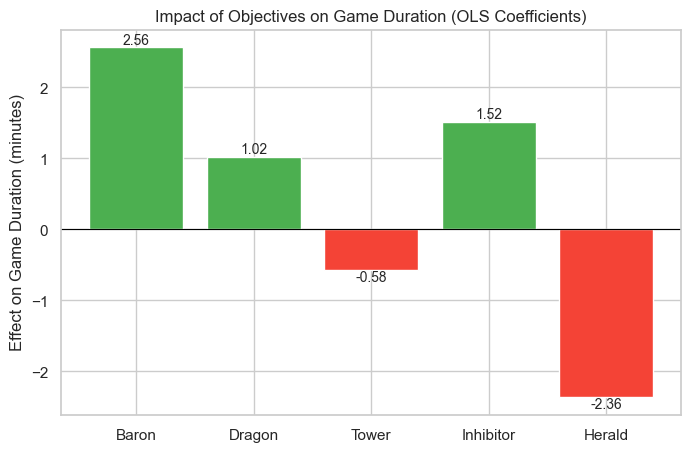

In [ ]:
# Data from OLS
coef_data = {
    "Objective": ["Baron", "Dragon", "Tower", "Inhibitor", "Herald"],
    "Coefficient": [2.5646, 1.0238, -0.5759, 1.5151, -2.3639]
}

df_coef = pd.DataFrame(coef_data)

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(df_coef["Objective"], df_coef["Coefficient"], color=["#4caf50" if x > 0 else "#f44336" for x in df_coef["Coefficient"]])

# Value added above the bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", 
             ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

plt.axhline(0, color='black', linewidth=0.8)
plt.title("Impact of Objectives on Game Duration (OLS Coefficients)", fontsize=12)
plt.ylabel("Effect on Game Duration (minutes)")
plt.show()


Each coefficient indicates how many minutes the game duration increases/decreases if the winner captures one additional objective (assuming other factors remain constant):
- Baron (coef = +2.56, p < 0.001)
    
    Every Baron captured by the winner adds an average of 2.56 minutes to the game duration.
    This makes sense, as Barons are typically captured in the mid-late game and prolong the game.

- Dragon (coef = +1.02, p < 0.001)
    
    Every Dragon adds approximately one minute to the game duration.
    This indicates that Dragons are more commonly captured in the mid-game, thus tending to make games slightly longer.

- Tower (coef = –0.58, p < 0.001)
    
    Every Tower destroyed actually shortens the game by approximately 0.58 minutes.
    This makes sense, as destroying Towers speeds up the game's progression to victory.

- Inhibitor (coef = +1.52, p < 0.001)
    
    Each Inhibitor destroyed adds an average of 1.5 minutes to the game.
    Interesting: Although inhibitors typically speed up the end of the game, the model shows an increase in duration. This could be due to the opponent's continued defense (turtle defense), thus delaying the game.

- Herald (coef = -2.36, p < 0.001)
    
    Each Herald shortens the game by approximately 2.36 minutes.
    This makes sense, as the Herald is an early-game objective that opens up the map faster and encourages early wins.

Conclusion:
- Early Game Objectives (Herald, Tower) → shorten the game duration.
    - Herald: -2.36 minutes
    - Tower: -0.58 minutes

- Mid-Late Game Objectives (Dragon, Inhibitor, Baron) → lengthen the game duration. 
    - Dragon: +1 minute
    - Inhibitor: +1.5 minutes
    - Baron: +2.56 minutes

- Strategic Implications:
    - Teams that win early tend to secure more Heralds and Towers.
    - Teams that win slowly tend to secure more Barons, Dragons, and Inhibitors.

### 2.4 Ban Analysis

- Which champions are banned most frequently?
- What is the relationship between banned champions and win rate?


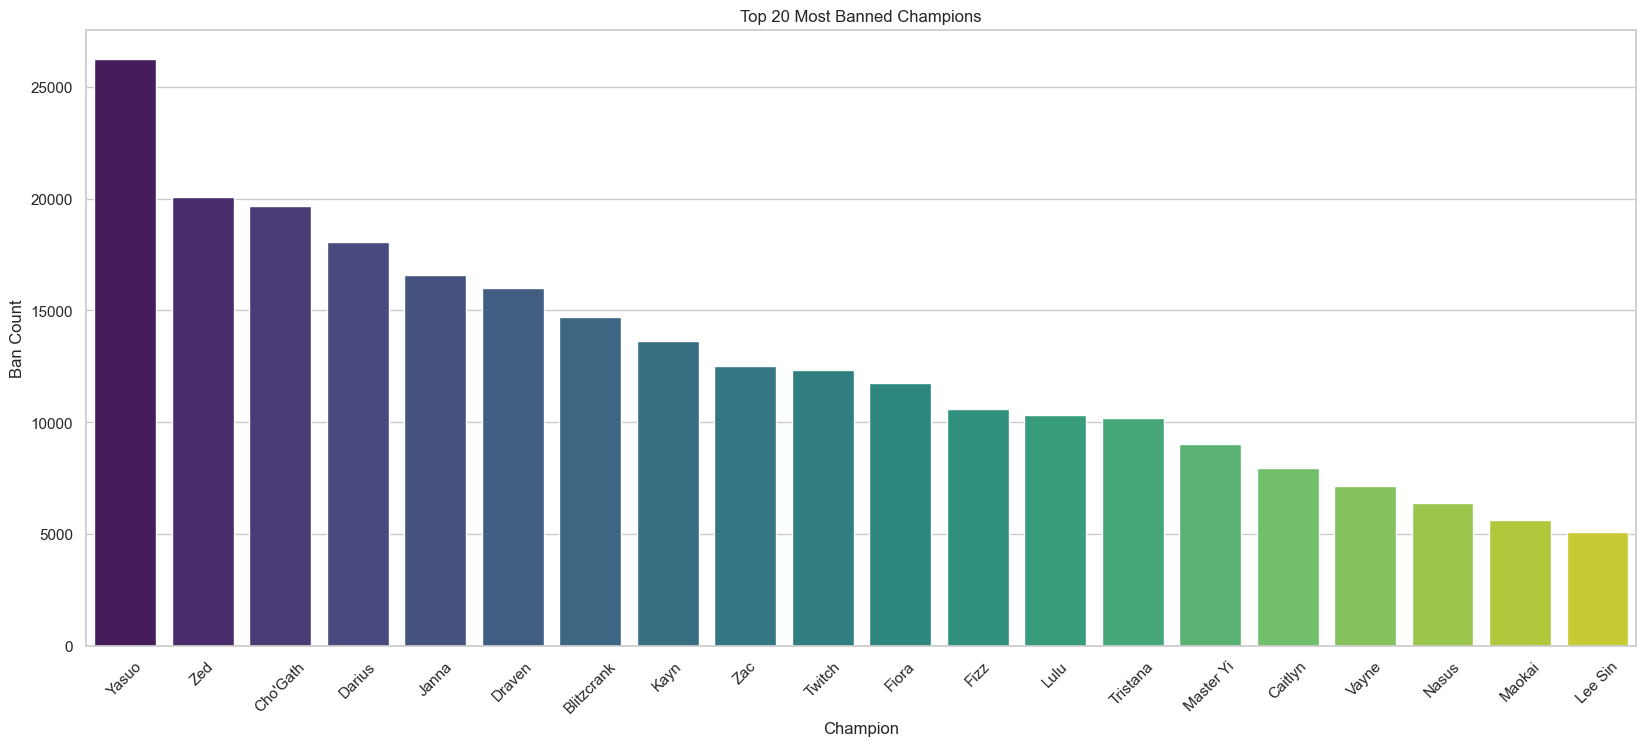

In [41]:
banned_heroes = ['t1_ban1', 't1_ban2', 't1_ban3', 't1_ban4', 't1_ban5',
                 't2_ban1', 't2_ban2', 't2_ban3', 't2_ban4', 't2_ban5']

# Combine all ban to one column
all_bans = pd.melt(df_copy_winner[banned_heroes], value_name="Champion")["Champion"]

# Count ban frequency
ban_counts = all_bans.value_counts().reset_index()
ban_counts.columns = ["Champion", "Ban Count"]

# Visualization
plt.figure(figsize=(20,8))
sns.barplot(data=ban_counts.head(20), x="Champion", y="Ban Count", palette="viridis", hue="Champion")
plt.title("Top 20 Most Banned Champions")
plt.xticks(rotation=45)
plt.ylabel("Ban Count")
plt.xlabel("Champion")
plt.show()


Based on data in season 9 ranked games, Yasou is the most banned champion.

Here are some reasons that frequently appear in articles, wikis, forums, etc.:
1.  Wind Wall:
    - Yasuo has the Wind Wall skill, which can block important projectiles (ultimates, ranged skills, etc.). This is very annoying for opponents because it disrupts damage range and poke.

2.  High Mobility + Duel Potential
    - Yasuo can move quickly (dash, synergies with minions, creep waves, etc.), has knock-up abilities, burst damage, and can snowball. Players who are "pro" with Yasuo can carry the game, especially after acquiring several items.

3.  Skilled Champion / High Skill Ceiling
    - Although difficult, in the hands of skilled players, Yasuo can be very overpowered. Many people ban Yasuo to avoid facing a skilled Yasuo who can "turn the game around."

4.  Frustrations Playing Against Yasuo
    - Many players have reported that Yasuo feels "unfair" or "frustrating":
        - sometimes he loses lane but can still come back through farming/scaling,
        - his Wind Wall makes the opponent's skills less effective, or because opposing players don't understand how to counter him.

5.  Popularity & Meme Status
    - Yasuo is a champion that is often meme-worthy and well-known to the public, often played by others (popular), so his bans are often due to reputation ("just ban Yasuo porque es Yasuo")

Link:

https://www.thegamer.com/league-of-legends-lol-champions-most-banned-opgg/

https://www.reddit.com/r/leagueoflegends/comments/d38dfl/why_are_yasuo_and_zed_banned_all_the_time/


In [42]:
banned_heroes = ['t1_ban1','t1_ban2','t1_ban3','t1_ban4','t1_ban5',
                 't2_ban1','t2_ban2','t2_ban3','t2_ban4','t2_ban5']

bans = pd.melt(df_copy, id_vars=["gameId","winner"], value_vars=banned_heroes,
               var_name="ban_slot", value_name="champion_banned")

bans["team"] = bans["ban_slot"].str.slice(0,2)
bans["is_win"] = ((bans["team"] == "t1") & (bans["winner"] == 1)) | \
                 ((bans["team"] == "t2") & (bans["winner"] == 2))

ban_winrate = bans.groupby("champion_banned")["is_win"].mean().reset_index()
ban_winrate.columns = ["champion_banned","ban_winrate"]

ban_counts = bans["champion_banned"].value_counts().reset_index()
ban_counts.columns = ["champion_banned","ban_count"]

ban_stats = pd.merge(ban_counts, ban_winrate, on="champion_banned")

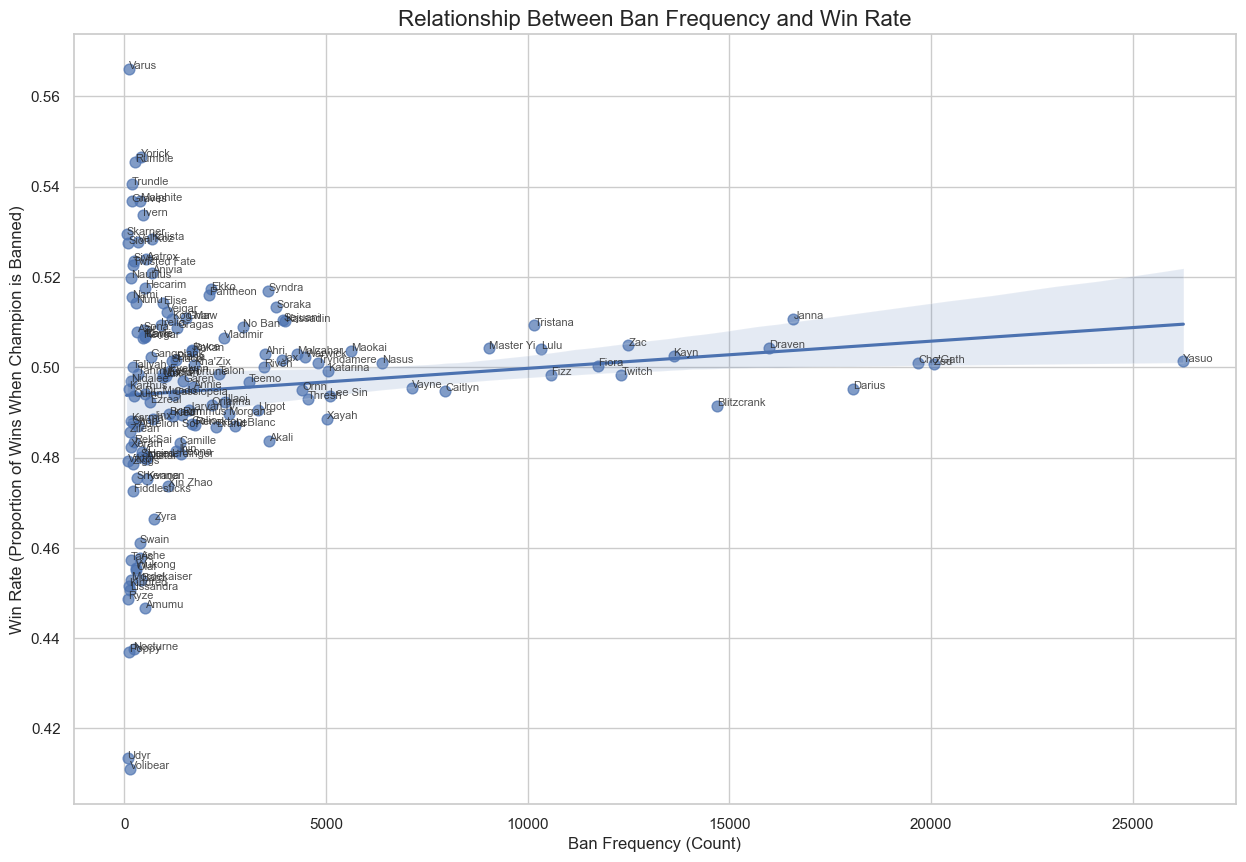

In [43]:
banned_heroes = ['t1_ban1', 't1_ban2', 't1_ban3', 't1_ban4', 't1_ban5',
                 't2_ban1', 't2_ban2', 't2_ban3', 't2_ban4', 't2_ban5']

ban_data = []
for col in banned_heroes:
    team = 1 if col.startswith("t1") else 2
    temp = df_copy_winner[[col, "winner"]].copy()
    temp.rename(columns={col: "champion"}, inplace=True)
    temp["ban_team"] = team
    temp["ban_win"] = (temp["winner"] == team).astype(int)
    ban_data.append(temp)

ban_df = pd.concat(ban_data)

# 2. Count ban frequency and win rate while champions banned
ban_summary = ban_df.groupby("champion").agg(
    ban_count=("champion", "count"),
    win_rate=("ban_win", "mean")
).reset_index()

# 3. Scatter plot ban frequency vs win rate + champion labels
plt.figure(figsize=(15,10))
sns.regplot(data=ban_summary, x="ban_count", y="win_rate", scatter_kws={"s":60, "alpha":0.7})
plt.title("Relationship Between Ban Frequency and Win Rate", fontsize=16)
plt.xlabel("Ban Frequency (Count)")
plt.ylabel("Win Rate (Proportion of Wins When Champion is Banned)")

# Including label champion's name in scatter plot
for i, row in ban_summary.iterrows():
    plt.text(row["ban_count"]+0.3, row["win_rate"], row["champion"], fontsize=8, alpha=0.8)

plt.show()


Scatter Plot Interpretation: Ban Frequency vs. Win Rate
1. General Direction of the Relationship
    
    The regression line slopes slightly upward → meaning that the more frequently a champion is banned, the team that bans it tends to have a slightly increased win rate.
    However, the slope is small → this relationship is weak and not very significant.

2. Most Frequently Banned Champions

    - Yasuo → is a clear outlier on the right side (ban frequency > 25k).
    Despite being frequently banned, the win rate of teams that ban Yasuo is only around 50%, meaning that banning Yasuo is more of a preventative measure (avoiding the risk of enemy picks) than actually increasing the chances of winning.

    - Cho'Gath, Blitzcrank, Darius, Draven, Janna → also have high ban frequencies, but their win rates remain around 49–51%.
    So, similar to Yasuo, their bans are not the determining factor in winning, but rather a strategic/meta preference.

3. Champions with High Banned Win Rates

    - Example: Varus, Trundle, Kindred → Although rarely banned, teams that ban them actually have higher win rates (around 53–56%).
    This could indicate that banning certain champions is truly effective in maintaining a safe team composition.

4. Champions with Low Banned Win Rates

    For example, Udyr, Volibear, Amumu → teams that ban them actually tend to have lower win rates (<45%).
    This is likely because these champions aren't particularly threatening in the Season 9 meta, so wasting a ban slot on them is detrimental.

Conclusion:
- Ban frequency doesn't always correlate directly with win rate.
- The most frequently banned champions (Yasuo, Blitzcrank, Cho'Gath) are more often banned due to popularity, the meta, or being considered difficult, rather than because they actually increase win chances.
- Effective bans are actually for certain champions that are rarely banned but have a significant impact when prevented (e.g., Varus, Trundle, Kindred).
- Therefore, in this EDA, it can be concluded that ban effectiveness is more important than simply ban frequency.

## 3. Modeling

In [44]:
!pip install lightgbm
!pip install bayesian-optimization


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.ensemble import IsolationForest, GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from bayes_opt import BayesianOptimization

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from category_encoders import BinaryEncoder

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, KMeansSMOTE, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, NeighbourhoodCleaningRule, TomekLinks, NearMiss
from imblearn.pipeline import Pipeline

import category_encoders as ce

### 3.1 Data Preparation

In [46]:
df_copy

,gameId,gameDuration,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,t1_champ1_sum2,t1_champ2id,t1_champ2_sum1,t1_champ2_sum2,t1_champ3id,t1_champ3_sum1,t1_champ3_sum2,t1_champ4id,t1_champ4_sum1,t1_champ4_sum2,t1_champ5id,t1_champ5_sum1,t1_champ5_sum2,t1_towerKills,t1_inhibitorKills,t1_baronKills,t1_dragonKills,t1_riftHeraldKills,t1_ban1,t1_ban2,t1_ban3,t1_ban4,t1_ban5,t2_champ1id,t2_champ1_sum1,t2_champ1_sum2,t2_champ2id,t2_champ2_sum1,t2_champ2_sum2,t2_champ3id,t2_champ3_sum1,t2_champ3_sum2,t2_champ4id,t2_champ4_sum1,t2_champ4_sum2,t2_champ5id,t2_champ5_sum1,t2_champ5_sum2,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,32,1,2,1,1,1,1,2,Vladimir,Teleport,Flash,Bard,Exhaust,Flash,Kog'Maw,Flash,Heal,Master Yi,Smite,Ghost,Viktor,Flash,Ignite,11,1,2,3,0,Riven,Janna,Cassiopeia,Draven,Kayn,Graves,Smite,Flash,Xayah,Flash,Heal,Darius,Ghost,Flash,Zed,Ignite,Flash,Thresh,Flash,Exhaust,5,0,0,1,1,Fiora,Vayne,Karma,Soraka,Caitlyn
1,3229566029,31,1,1,1,1,0,1,1,Draven,Heal,Flash,Irelia,Teleport,Flash,Nidalee,Flash,Exhaust,Kayle,Flash,Ignite,Shaco,Flash,Smite,10,4,0,2,1,Caitlyn,Darius,Teemo,Xayah,Warwick,Malphite,Flash,Teleport,Morgana,Flash,Ignite,Hecarim,Smite,Flash,Yasuo,Flash,Ignite,Riven,Flash,Heal,2,0,0,0,0,Master Yi,Vayne,Zed,Caitlyn,Illaoi
2,3327363504,25,1,2,1,1,1,2,0,Tristana,Flash,Heal,Kayn,Smite,Flash,Nami,Exhaust,Flash,Rumble,Flash,Teleport,Kassadin,Teleport,Flash,8,1,1,1,0,Lulu,Janna,Twitch,Soraka,Blitzcrank,Cassiopeia,Flash,Heal,Thresh,Ignite,Flash,Jayce,Flash,Teleport,Jax,Flash,Smite,Ashe,Heal,Flash,2,0,0,1,0,Yasuo,Zed,Kha'Zix,Maokai,Evelynn
3,3326856598,29,1,1,1,1,1,1,0,Maokai,Flash,Teleport,Brand,Flash,Ignite,Twitch,Flash,Heal,Orianna,Flash,Cleanse,Dr. Mundo,Smite,Flash,9,2,1,2,0,Zed,Vayne,Ornn,Fiora,Cho'Gath,Malzahar,Ignite,Flash,Warwick,Smite,Flash,Thresh,Flash,Exhaust,Riven,Flash,Ignite,Ashe,Flash,Heal,0,0,0,0,0,Camille,Tristana,Kayn,Janna,Caitlyn
4,3330080762,35,1,2,1,1,1,1,0,Warwick,Flash,Teleport,Twitch,Smite,Flash,Janna,Flash,Exhaust,Draven,Flash,Heal,Syndra,Heal,Flash,9,2,1,3,0,Malzahar,Lee Sin,Thresh,Morgana,Cho'Gath,Sona,Exhaust,Flash,Jarvan IV,Flash,Teleport,Kayn,Smite,Flash,Kassadin,Flash,Teleport,Caitlyn,Flash,Heal,3,0,0,1,0,Garen,Master Yi,Braum,Darius,Tristana
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51484,3316694929,45,2,2,1,2,2,2,0,Varus,Flash,Heal,Brand,Heal,Flash,LeBlanc,Ignite,Flash,Shaco,Ignite,Smite,Cho'Gath,Flash,Ignite,5,1,0,2,0,Illaoi,Blitzcrank,Lee Sin,Yasuo,Jinx,Taric,Flash,Exhaust,Jhin,Flash,Heal,Master Yi,Smite,Ghost,Akali,Flash,Ignite,Kayn,Flash,Teleport,11,5,2,3,0,Maokai,Miss Fortune,Yasuo,Blitzcrank,Renekton
51485,3308904636,32,2,1,2,2,0,2,0,Warwick,Teleport,Flash,Kalista,Flash,Heal,Talon,Flash,Ignite,Bard,Flash,Ignite,Lee Sin,Flash,Smite,2,0,0,0,0,Fiora,Tristana,Master Yi,Yasuo,Rakan,Veigar,Teleport,Flash,Yorick,Teleport,Flash,Vayne,Flash,Heal,Janna,Exhaust,Flash,Gragas,Smite,Flash,10,2,0,4,0,Katarina,No Ban,Malzahar,Zed,Yasuo
51486,3215685759,55,2,1,1,2,2,2,2,Malzahar,Flash,Ignite,Amumu,Flash,Smite,Cho'Gath,Teleport,Flash,Thresh,Ignite,Flash,Tristana,Flash,Heal,5,4,0,2,0,Yasuo,Camille,Darius,Lux,Illaoi,Shyvana,Smite,Flash,Kalista,Heal,Flash,Leona,Exhaust,Flash,Nasus,Flash,Teleport,Veigar,Ignite,Flash,11,7,4,4,1,Yasuo,Katarina,Draven,Zac,Fizz
51487,3322765040,36,2,2,2,2,0,1,0,Kayn,Smite,Flash,Tristana,Heal,Flash,Bard,Exhaust,Flash,Ezreal,Teleport,Flash,Rumble,Flash,Teleport,0,0,0,1,0,Zed,Cho'Gath,Jax,Blitzcrank,Master Yi,Annie,Flash,Teleport,Draven,Heal,Flash,Rammus,Smite,Flash,Karma,Teleport,Flash,Lux,Ignite,Flash,10,2,0,2,0,Sejuani,Darius,Blitzcrank,Master Yi,Yasuo


In [47]:
X = df_copy_winner.drop(columns=['winner', 'gameDuration'], axis=1)
y = df_copy_winner['winner'].map({1:0, 2:1})
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=0,
    test_size=0.3
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(28285, 67) (12123, 67) (28285,) (12123,)


In [ ]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from category_encoders import BinaryEncoder
from sklearn.compose import ColumnTransformer

# Grouping feature
first_obj = ['firstBlood', 'firstTower', 'firstInhibitor',
             'firstBaron', 'firstDragon', 'firstRiftHerald']

objectives = ['t1_towerKills', 't1_inhibitorKills', 't1_baronKills',
              't1_dragonKills', 't1_riftHeraldKills',
              't2_towerKills', 't2_inhibitorKills', 't2_baronKills',
              't2_dragonKills', 't2_riftHeraldKills']

champ = ['t1_champ1id','t1_champ1_sum1','t1_champ1_sum2',
             't1_champ2id','t1_champ2_sum1','t1_champ2_sum2',
             't1_champ3id','t1_champ3_sum1','t1_champ3_sum2',
             't1_champ4id','t1_champ4_sum1','t1_champ4_sum2',
             't1_champ5id','t1_champ5_sum1','t1_champ5_sum2',
             't1_ban1','t1_ban2','t1_ban3','t1_ban4','t1_ban5',
             't2_champ1id','t2_champ1_sum1','t2_champ1_sum2',
             't2_champ2id','t2_champ2_sum1','t2_champ2_sum2',
             't2_champ3id','t2_champ3_sum1','t2_champ3_sum2',
             't2_champ4id','t2_champ4_sum1','t2_champ4_sum2',
             't2_champ5id','t2_champ5_sum1','t2_champ5_sum2',
             't2_ban1','t2_ban2','t2_ban3','t2_ban4','t2_ban5']

# Preprocessor
preprocessor = ColumnTransformer([
    ('first_obj', OneHotEncoder(drop='if_binary'), first_obj),   
    ('objectives', RobustScaler(), objectives),                  
    ('champ', BinaryEncoder(), champ)                    
], remainder='drop')


### 3.2 Modeling (Winner Prediction)

In [49]:
lr = LogisticRegression(max_iter=2000, random_state=0, solver='lbfgs', class_weight='balanced')
randomforest = RandomForestClassifier(n_estimators=300, max_depth=None, class_weight='balanced_subsample', random_state=0, n_jobs=-1)
knn = KNeighborsClassifier(n_jobs=-1)
gb = GradientBoostingClassifier(random_state=0)
ada = AdaBoostClassifier(random_state=0)
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)

xg = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1
)


In [50]:
models = [lr, randomforest, knn, gb, ada, lgbm, xg]

In [ ]:
train_score_list = []
train_score_std_list = []
test_score_list = []


for model in models:
    my_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    # Train model
    stratified_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    score = cross_val_score(my_pipeline, X_train, y_train, cv=stratified_kf, scoring = 'f1', n_jobs=12)

    train_score_list.append(score.mean())
    train_score_std_list.append(score.std())

    # Prediction
    my_pipeline.fit(X_train, y_train)
    preds_test = my_pipeline.predict(X_test)
    preds_train = my_pipeline.predict(X_train)

    # Evaluation
    test_score = f1_score(y_test, preds_test)
    test_score_list.append(test_score)

    print(f"**{model}**")
    print(classification_report(y_train, preds_train, zero_division=0))
    print(classification_report(y_test, preds_test, zero_division=0))
    print("\n" + "="*50 + "\n")
    print()

**LogisticRegression(class_weight='balanced', max_iter=2000, random_state=0)**
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     14147
           1       0.97      0.97      0.97     14138

    accuracy                           0.97     28285
   macro avg       0.97      0.97      0.97     28285
weighted avg       0.97      0.97      0.97     28285

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      6063
           1       0.97      0.97      0.97      6060

    accuracy                           0.97     12123
   macro avg       0.97      0.97      0.97     12123
weighted avg       0.97      0.97      0.97     12123




**RandomForestClassifier(class_weight='balanced_subsample', n_estimators=300,
                       n_jobs=-1, random_state=0)**
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14147
           1       1.00  

c:\Users\ADIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


**AdaBoostClassifier(random_state=0)**
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     14147
           1       0.98      0.97      0.98     14138

    accuracy                           0.98     28285
   macro avg       0.98      0.98      0.98     28285
weighted avg       0.98      0.98      0.98     28285

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6063
           1       0.98      0.98      0.98      6060

    accuracy                           0.98     12123
   macro avg       0.98      0.98      0.98     12123
weighted avg       0.98      0.98      0.98     12123




[LightGBM] [Info] Number of positive: 14138, number of negative: 14147
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009223 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightG

In [52]:
model_names = [
    'Logistic Regression',
    'Random Forest',
    'KNN',
    'Gradient Boosting',
    'AdaBoost',
    'LightGBM',
    'XGBoost'
]

pd.DataFrame(
    {'model': model_names,
     'train': train_score_list,
     'train_std': train_score_std_list,
     'test': test_score_list}
).sort_values(by='test', ascending=False)


,model,train,train_std,test
3,Gradient Boosting,0.976866,0.002164,0.977243
5,LightGBM,0.976610,0.001702,0.975931
4,AdaBoost,0.973477,0.002307,0.975819
6,XGBoost,0.977216,0.001403,0.975501
1,Random Forest,0.971560,0.000859,0.971174
0,Logistic Regression,0.967163,0.002414,0.966942
2,KNN,0.916215,0.002405,0.913204


Based on several models, the most efficient model is DecisionTreeRegressor with 0.977243 test and 0.976866 train. So we'll use this model as final model.

### 3.3 Hyperparameter Tuning 

In [ ]:
X_train_transformed = preprocessor.fit_transform(X_train)

def gb_opt(n_estimators, max_depth, subsample, learning_rate):
    model = GradientBoostingClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        subsample=subsample,
        learning_rate=learning_rate,
        random_state=0
    )

    # Stratified K-Fold for cross-validation
    stratified_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    f1_scores = cross_val_score(model, X_train_transformed, y_train, cv=stratified_kf, scoring='f1', n_jobs=-1)

    return np.mean(f1_scores)

# Definition of parameter limits for optimization
param_bounds = {
    'n_estimators': (200,350),         # Range of number of trees
    'max_depth': (10,20),              # Lower tree depth range to avoid overfitting
    'subsample': (0.6, 0.9),           # Range for sampling control to reduce overfitting
    'colsample_bytree': (0.8, 1),      # Range for the feature control used (Not very important because gradient boosting does not have this parameter)
    'learning_rate': (0.01, 0.1),      # Model learning rate range (the smaller the range, the more detail the model learns)
}

# Optimizer initialization
optimizer = BayesianOptimization(f=gb_opt, pbounds=param_bounds, random_state=0)

# Running Optimizer
optimizer.maximize(init_points=5, n_iter=20)

# Show maximum results
print(optimizer.max)

|   iter    |  target   | n_esti... | max_depth | subsample | colsam... | learni... |
-------------------------------------------------------------------------------------
| 1         | 0.9766734 | 282.32202 | 17.151893 | 0.7808290 | 0.9089766 | 0.0481289 |
| 2         | 0.9760715 | 296.88411 | 14.375872 | 0.8675319 | 0.9927325 | 0.0445097 |
| 3         | 0.9757971 | 318.75875 | 15.288949 | 0.7704133 | 0.9851193 | 0.0163932 |
| 4         | 0.9766065 | 213.06939 | 10.202183 | 0.8497859 | 0.9556313 | 0.0883010 |
| 5         | 0.9760440 | 346.79275 | 17.991585 | 0.7384438 | 0.9561058 | 0.0206446 |
| 6         | 0.9765680 | 239.68334 | 18.742308 | 0.6416038 | 0.8448891 | 0.0297961 |
| 7         | 0.9764845 | 301.05939 | 18.938875 | 0.8476189 | 0.8467580 | 0.0845706 |
| 8         | 0.9757828 | 244.46235 | 16.636186 | 0.7259287 | 0.8574418 | 0.0174464 |
| 9         | 0.9769971 | 329.79552 | 11.689240 | 0.7625767 | 0.9361710 | 0.0462824 |
| 10        | 0.9761818 | 217.67533 | 15.548228 | 0.69

In [58]:
gb_tuned = GradientBoostingClassifier(
    random_state=0,
    learning_rate=0.093,
    max_depth=int(10.16),
    n_estimators=int(203.185),
    subsample=0.766,
)

In [59]:
train_score_tuned = []
train_std_tuned = []
test_score_tuned = []

pipeline_gb_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', gb_tuned)
])
pipeline_gb_tuned.fit(X_train, y_train)

stratified_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
score_cv = cross_val_score(pipeline_gb_tuned, X_train, y_train, cv=stratified_kf, scoring='f1', n_jobs=-1)
train_score_tuned.append(score_cv.mean())
train_std_tuned.append(score_cv.std())

preds_test = pipeline_gb_tuned.predict(X_test)
preds_train = pipeline_gb_tuned.predict(X_train)

test_score = f1_score(y_test, preds_test)
test_score_tuned.append(test_score)

print(f"mean train score:{score_cv.mean()}")
print(f"mean train std:{score_cv.std()}")
print(f"test score:{test_score}")
print("\n" + "="*50 + "\n")
print(classification_report(y_train, preds_train))
print(classification_report(y_test, preds_test))
print()

mean train score:0.9770192025217425
mean train std:0.0018152092212997777
test score:0.975762572135202


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14147
           1       1.00      1.00      1.00     14138

    accuracy                           1.00     28285
   macro avg       1.00      1.00      1.00     28285
weighted avg       1.00      1.00      1.00     28285

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      6063
           1       0.97      0.98      0.98      6060

    accuracy                           0.98     12123
   macro avg       0.98      0.98      0.98     12123
weighted avg       0.98      0.98      0.98     12123




In [60]:
tuned_eval = pd.DataFrame(
    {'model': 'Gradient Boosting Tuned',
     'train': train_score_tuned,
     'train_std': train_std_tuned,
     'test': test_score_tuned}
)
tuned_eval

,model,train,train_std,test
0,Gradient Boosting Tuned,0.977019,0.001815,0.975763


Model already tuned, but it seems the model before tuning have better test score (0.977243) so for the final model, we'll use Gradient Boosting model before tuning.

### 3.4 Feature Importance

In [53]:
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', gb)
])
final_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('first_obj',
                                                  OneHotEncoder(drop='if_binary'),
                                                  ['firstBlood', 'firstTower',
                                                   'firstInhibitor',
                                                   'firstBaron', 'firstDragon',
                                                   'firstRiftHerald']),
                                                 ('objectives', RobustScaler(),
                                                  ['t1_towerKills',
                                                   't1_inhibitorKills',
                                                   't1_baronKills',
                                                   't1_dragonKills',
                                                   't1_riftHeraldKills',
                                                   't2_towerKills',
                                                   't2_inhibitorK...
                                                   't1_champ4_sum1',
                                                   't1_champ4_sum2',
                                                   't1_champ5id',
                                                   't1_champ5_sum1',
                                                   't1_champ5_sum2', 't1_ban1',
                                                   't1_ban2', 't1_ban3',
                                                   't1_ban4', 't1_ban5',
                                                   't2_champ1id',
                                                   't2_champ1_sum1',
                                                   't2_champ1_sum2',
                                                   't2_champ2id',
                                                   't2_champ2_sum1',
                                                   't2_champ2_sum2',
                                                   't2_champ3id',
                                                   't2_champ3_sum1',
                                                   't2_champ3_sum2',
                                                   't2_champ4id', ...])])),
                ('model', GradientBoostingClassifier(random_state=0))])

In [58]:
final_model.fit(X_train, y_train)

# Then proceed to extract feature importances and names
feat_imp = final_model.named_steps['model'].feature_importances_
features = final_model.named_steps['preprocessor'].get_feature_names_out()

df_feat_imp = pd.DataFrame({
    'features': features,
    'importance': feat_imp
}).sort_values(by = 'importance', ascending = False)
pd.set_option('display.max_rows', None)
df_feat_imp

,features,importance
19,objectives__t2_towerKills,0.551923
14,objectives__t1_towerKills,0.244232
20,objectives__t2_inhibitorKills,0.146856
15,objectives__t1_inhibitorKills,0.034348
4,first_obj__firstInhibitor_2,0.011310
3,first_obj__firstInhibitor_1,0.004987
16,objectives__t1_baronKills,0.001817
21,objectives__t2_baronKills,0.001119
6,first_obj__firstBaron_1,0.000781
7,first_obj__firstBaron_2,0.000659


The top 3 features based on gradient boosting model are:
1. objectives__t2_towerKills
2. objectives__t1_towerKills
3. objectives__t2_inhibitorKills

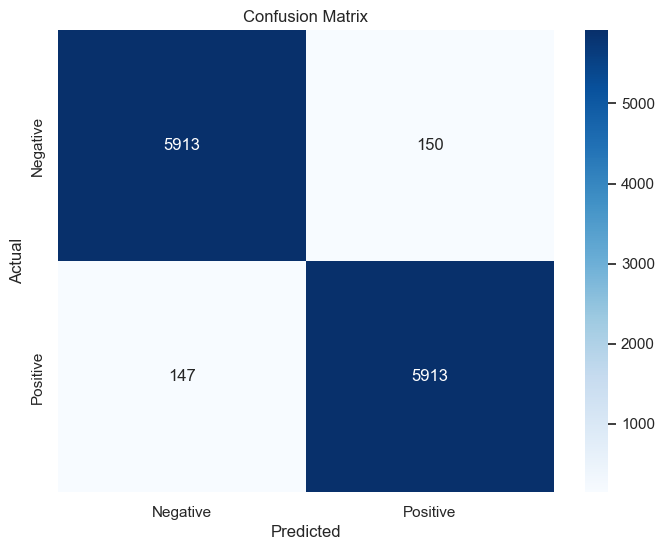

In [54]:
cm = confusion_matrix(y_test, preds_test)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Based on Confusion Matrix:
- True Positive = Model predicted Team 2 won and right (5913)
- True Negative = Model predicted Team 1 won and right (5913)
- False Positive = Model predicted Team 2 won but but in reality team 1 wins (150)
- False Negative = Model predicted Team 1 won but but in reality team 2 wins (147)

False Postive and False Negative Implication:

The model made a prediction error of 150 on False Postive and 147 on False Negative. This can be caused by the model does not have other variables such as Champion's scalling power.

### 3.5 Model Limitation

In [55]:
test_df = pd.DataFrame(X_test, copy=True)  # Data uji
test_df['actual'] = y_test  # Label asli
test_df['predicted'] = preds_test  # Prediksi model

In [56]:
tp = test_df[(test_df['actual'] == 1) & (test_df['predicted'] == 1)]
tn = test_df[(test_df['actual'] == 0) & (test_df['predicted'] == 0)]
fp = test_df[(test_df['actual'] == 0) & (test_df['predicted'] == 1)]
fn = test_df[(test_df['actual'] == 1) & (test_df['predicted'] == 0)]

print(f"True Positive (TP): {len(tp)}")
print(f"True Negative (TN): {len(tn)}")
print(f"False Positive (FP): {len(fp)}")
print(f"False Negative (FN): {len(fn)}")

True Positive (TP): 5913
True Negative (TN): 5913
False Positive (FP): 150
False Negative (FN): 147


#### False Positive

In [57]:
print("Data False Positive (FP):")
fp.shape

Data False Positive (FP):


(150, 69)

In [58]:
fp.describe().T

,count,mean,std,min,25%,50%,75%,max
gameId,150.0,3.309422e+09,2.586054e+07,3.226755e+09,3.298787e+09,3.321583e+09,3.327926e+09,3.331621e+09
firstBlood,150.0,1.586667e+00,4.940813e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
firstTower,150.0,1.580000e+00,4.952120e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
firstInhibitor,150.0,1.366667e+00,6.389659e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
firstBaron,150.0,1.400000e+00,7.047299e-01,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
firstDragon,150.0,1.546667e+00,4.994852e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
firstRiftHerald,150.0,8.800000e-01,8.893101e-01,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
t1_towerKills,150.0,7.313333e+00,1.886500e+00,2.000000e+00,7.000000e+00,8.000000e+00,8.000000e+00,1.100000e+01
t1_inhibitorKills,150.0,1.593333e+00,1.043334e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,5.000000e+00
t1_baronKills,150.0,7.733333e-01,8.122111e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00


In [59]:
fp.describe(include='object').T

,count,unique,top,freq
t1_champ1id,150,80,Twitch,7
t1_champ1_sum1,150,9,Flash,76
t1_champ1_sum2,150,8,Flash,72
t1_champ2id,150,84,Twitch,9
t1_champ2_sum1,150,8,Flash,79
t1_champ2_sum2,150,8,Flash,65
t1_champ3id,150,81,Soraka,6
t1_champ3_sum1,150,8,Flash,79
t1_champ3_sum2,150,9,Flash,66
t1_champ4id,150,80,Twitch,8


#### False Negative

In [60]:
print("Data False Negative (FN):")
fn.shape

Data False Negative (FN):


(147, 69)

In [61]:
fn.describe().T

,count,mean,std,min,25%,50%,75%,max
gameId,147.0,3.303679e+09,3.134070e+07,3.218395e+09,3.291485e+09,3.317416e+09,3.326151e+09,3.331458e+09
firstBlood,147.0,1.510204e+00,5.016049e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
firstTower,147.0,1.448980e+00,4.990906e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
firstInhibitor,147.0,1.278912e+00,6.902681e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
firstBaron,147.0,1.312925e+00,6.703375e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
firstDragon,147.0,1.448980e+00,4.990906e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
firstRiftHerald,147.0,6.394558e-01,7.846610e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00
t1_towerKills,147.0,8.040816e+00,1.894034e+00,3.000000e+00,7.000000e+00,8.000000e+00,9.000000e+00,1.100000e+01
t1_inhibitorKills,147.0,2.040816e+00,1.569738e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,7.000000e+00
t1_baronKills,147.0,8.503401e-01,8.305283e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00


In [62]:
fn.describe(include='object').T

,count,unique,top,freq
t1_champ1id,147,79,Yasuo,5
t1_champ1_sum1,147,9,Flash,90
t1_champ1_sum2,147,7,Flash,54
t1_champ2id,147,87,Lee Sin,5
t1_champ2_sum1,147,8,Flash,80
t1_champ2_sum2,147,9,Flash,62
t1_champ3id,147,77,Tristana,8
t1_champ3_sum1,147,8,Flash,96
t1_champ3_sum2,147,7,Flash,49
t1_champ4id,147,83,Lee Sin,6


## 4. Conclusion and Recommendation

Conclusion Based on EDA:
1. Game Duration Analysis:
    - Based on game duration in season 9 EU server ranked games, most of each game duration are 31, 29, and 30 minutes.
2. Win Conditions & Objectives:
    - The team that destroys the inhibitor tower first has a very big chance of winning the match, as much as 86%.
    - First Baron is the most dominant with very large coefficient (0.28). The team that takes first Baron is at a significant advantage. This means that the baron buff is one of the most powerful win conditions. 
    - Overall, the graph shows that objective-based play (tower, inhibitor, baron) is much more decisive for victory than early skirmish (first blood, first dragon).
3. Team strategy:
    - Early Game Objectives (Herald, Tower) → shorten the game duration.
        - Herald: -2.36 minutes
        - Tower: -0.58 minutes
    - Mid-Late Game Objectives (Dragon, Inhibitor, Baron) → lengthen the game duration. 
        - Dragon: +1 minute
        - Inhibitor: +1.5 minutes
        - Baron: +2.56 minutes
    - Strategic Implications:
        - Teams that win early tend to secure more Heralds and Towers.
        - Teams that win mid - late tend to secure more Barons, Dragons, and Inhibitors.
4. Ban Analysis:
    - Based on data in season 9 ranked games, Yasou is the most banned champion. Its because the hero have:
        - Wind Wall skills
        - High Mobility and 1 v 1 winning duel potential
        - High Skill Ceiling
    - Ban frequency doesn't always correlate directly with win rate
        - The most frequently banned champions (Yasuo, Blitzcrank, Cho'Gath) are more often banned due to popularity, the meta, or being considered difficult, rather than because they actually increase win chances (< 50% champions winrates)
        - Effective bans are actually for certain champions that are rarely banned but have a significant impact when prevented (Varus, Trundle, Yorick) with champions winrates >= 54%
    - It can be concluded that ban effectiveness is more important than simply ban frequency.



Recommendations Based on EDA Findings:

1. Objective Balancing

- Herald & Towers (Early Game)
    - Insight: Early objectives shorten game duration (Herald: -2.36 minutes, Tower: -0.58 minutes).
    - Recommendation: Slightly reduce Herald or tower gold rewards to avoid triggering a snowball in the early game.
    - Objective: Give the trailing team a chance to stage a comeback.

- Baron & Dragon (Mid–Late Game)
    - Insight: Baron has the greatest impact on win rate (+0.28 coefficient) and extends game duration (+2.56 minutes).
    - Recommendation:
        - Slightly reduce Baron buff effects (e.g., on minion empowerment or siege damage) to prevent them from being too one-sided.
        - Strengthen Dragon's stacking effect to provide an alternative win condition to Baron.
        - Objective: Balance objective pressure between the mid and late game.

2. Win Condition Adjustments

- Inhibitor Towers
    - Insight: First Inhibitor provides a very high win rate (86%).
    - Recommendation: Add defensive scaling mechanisms (e.g., faster inhibitor respawns or temporary defensive buffs when inhibitors fall).
    - Goal: Reduce the early "point of no return" effect and keep the game competitive.

3. Champion Ban Analysis

- Popular Bans (Yasuo, Blitzcrank, Cho'Gath)
    - Insight: Banned more due to popularity, frustration, and the meta, rather than win rate (all <50%).
    - Recommendation:
        - Fine-tune skills deemed toxic (e.g., Yasuo's Wind Wall cooldown, Blitzcrank's hook).
        - Strengthen counterplay options so these champions aren't always banned.

- Effective Bans (Varus, Trundle, Yorick)
    - Insight: Despite being rarely banned, their win rates are high (≥54%).
    - Recommendation:
        - Small nerfs to their specific scaling or utility.
        - Or, minor reworks to balance their impact when drafted.

4. Summoner Spells

- Insight: Some spells (Ignite, Flash, Teleport) significantly influence the tempo of the game.
- Recommendation:
    - Increase Ignite's cooldown to prevent early game snowballing.
    - Strengthen Teleport to better support mid-late game comebacks.
- Goal: Provide more strategic diversity between early aggression and late scaling.

Final Takeaway

- Based on the EDA analysis, game stability from early to late game can be improved by:
    1. Adjusting objective rewards (Herald, Baron, Dragon).
    2. Adjusting inhibitor impact to reduce snowballing.
    3. Balancing champions based on ban effectiveness instead of popularity.
    4. Reviewing spell balance to maintain game dynamics.

With these adjustments, the game will be more competitive, reduce excessive snowballing in the early game, and create a more stable and fair experience for all players.


Conclusion based on ML:

1. Main Factor:

The variable that most influences the model based on feature importance are objectives__t2_towerKills, objectives__t1_towerKills, and objectives__t2_inhibitorKills. It means tower is the most influence factor. Because if a team can destroy more towers, the benefits include greater map control, gold swing, and faster champion scaling. This allows for more extensive team gameplay.

2. Model Performance:

The best model, the Gradient Boosting Classifier, demonstrated an accuracy of 97.6% on the training data and 97.7% on the test data. This indicates that the model is very good at capturing winning patterns.

Recommendation based on ML:

So far the best model, which is Gradient Boosting Classifier significanly good to make prediction both on data train and test. And recommendation that I suggest are:
1. Although the models are very good at predicting false positive and false negative values, the models can still be improved by adding champion's scaling power to the dataset (to determine the champions scalling power).

2. Features with small but potentially significant impacts can be targeted for buffs or reworks. The features are objectives__t1_baronKills and objectives__t2_baronKills are not significanly as objectives__t2_towerKills, objectives__t1_towerKills, objectives__t2_inhibitorKills, and objectives__t1_inhibitorKills so further model dataset can be added some feature like:
    - early_objective_ratio = (riftHerald + firstTower) / totalObjectives
    - late_objective_ratio = (baron + inhibitor + elderDragon) / totalObjectives
    - “Objective composition” will help redesign the tempo of the game to be more balanced (not all matches end at the 25th minute).

3. Also some features can added to future dataset. The features are Win in teamfight (new feature can be added, namely the number of kills or deaths for each player in each match) and Resources & tempo stability (with a new feature that contains the amount of gold each player gets in a match. The "tempo stability" feature can be measured by the gold variance per 5 minutes. Teams with high volatility tend to be strategically unstable.)

**"Based on model and EDA, tower and inhibitor objectives dominate win conditions, leading to highly predictable matches. Future balancing could introduce more comeback potential and meta diversity by re-evaluating Baron and Dragon influence, as well as adjusting tower gold values and scaling mechanics.**

# Save Model

In [59]:
import pickle
with open('final_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)

In [ ]:
with open(r'D:\final_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)